### Regressions

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import QuantileRegressor

Open hindcast data

In [27]:
PATH = '/climca/people/glattus/Hindcast_data_ready'

def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
hind_SON_LaPlata_xr=xr.open_dataset(PATH+'/Target_vars_LP_SON.nc').drop_vars('lead_block')

#DJF
hind_DJF_LaPlata_xr=xr.open_dataset(PATH+'/Target_vars_LP_DJF.nc').drop_vars('lead_block')

##Andes
hind_SON_Andes_xr=xr.open_dataset(PATH+'/Target_vars_Andes_SON.nc').drop_vars('lead_block')
hind_DJF_Andes_xr=xr.open_dataset(PATH+'/Target_vars_Andes_DJF.nc').drop_vars('lead_block')

In [28]:
hind_SON_Andes_xr

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 34272)
Coordinates:
    init_month               (sample) int64 274kB ...
    season                   (sample) <U3 411kB ...
    forecast_reference_time  (sample) datetime64[ns] 274kB ...
    number                   (sample) int64 274kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 274kB ...
    tp                       (sample) float64 274kB ...

Open drivers data

In [29]:
#spring
ocean_SON_xr=xr.open_dataset(PATH+'/ENSO_IOD_SON.nc').drop_vars('lead_block').rename({'nino34':'ENSO', 'iod_index':'IOD'})
SAM_SON_xr=xr.open_dataset(PATH+'/SAM_ready_SON.nc')
SPV_SON_xr=xr.open_dataset(PATH+'/SPV_SON.nc').drop_vars(['lead_block', 'pressure_level']).rename({'u':'SPV'})


ocean_DJF_xr=xr.open_dataset(PATH+'/ENSO_IOB_DJF.nc').drop_vars('lead_block').rename({'nino34':'ENSO'})
SAM_DJF_xr=xr.open_dataset(PATH+'/SAM_ready_DJF.nc')
VB_DJF_xr=xr.open_dataset(PATH+'/VB_DOY_combined.nc').rename({'VB_DOY':'VB'})

display(VB_DJF_xr)
display(SAM_DJF_xr)
#display(ocean_DJF_xr)

<xarray.Dataset> Size: 137kB
Dimensions:                  (sample: 4284)
Coordinates:
    init_month               (sample) int64 34kB ...
    forecast_reference_time  (sample) datetime64[ns] 34kB ...
    number                   (sample) int64 34kB ...
Dimensions without coordinates: sample
Data variables:
    VB                       (sample) float64 34kB ...

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    init_month               (sample) int64 271kB ...
    season                   (sample) <U3 406kB ...
    forecast_reference_time  (sample) datetime64[ns] 271kB ...
    number                   (sample) int64 271kB ...
Dimensions without coordinates: sample
Data variables:
    S_SAM                    (sample) float32 135kB ...
    A_SAM                    (sample) float64 271kB ...

In [30]:
def align_hindcast_arrays(
    array_list,
    names=None,
    sample_coords=None,
    reference=0,
    verbose=True
):
    """
    Check and align xarray Datasets/DataArrays containing hindcast samples.

    Samples are identified by a combination of coordinates, by default:

        number
        init_month
        season
        forecast_reference_time

    The function:
      1. checks dimensions and required coordinates
      2. checks coordinate equality
      3. checks whether all datasets contain the same sample identities
      4. detects ordering differences
      5. reorders all datasets to the reference dataset's sample order
      6. verifies the final alignment

    Parameters
    ----------
    array_list : list
        List of xarray Dataset/DataArray objects.

    names : list, optional
        Names for diagnostic output.

    sample_coords : list, optional
        Coordinates defining a unique hindcast sample.

    reference : int
        Index of the dataset whose sample ordering is used
        as the reference.

    verbose : bool
        Print diagnostics.

    Returns
    -------
    aligned_arrays : list
        Aligned xarray objects.
    """

    # ---------------------------------------------------------
    # 1. Defaults
    # ---------------------------------------------------------

    if sample_coords is None:
        sample_coords = [
            "number",
            "init_month",
            "season",
            "forecast_reference_time"
        ]

    n_arrays = len(array_list)

    if names is None:
        names = [
            f"array_{i}"
            for i in range(n_arrays)
        ]

    if len(names) != n_arrays:
        raise ValueError(
            "names must have the same length as array_list"
        )

    if reference < 0 or reference >= n_arrays:
        raise ValueError(
            "reference must be a valid array index"
        )

    # ---------------------------------------------------------
    # 2. Basic checks
    # ---------------------------------------------------------

    if verbose:
        print("=" * 70)
        print("BASIC STRUCTURE")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        if not isinstance(
            arr,
            (xr.Dataset, xr.DataArray)
        ):
            raise TypeError(
                f"{name} is not an xarray Dataset/DataArray"
            )

        if "sample" not in arr.dims:
            raise ValueError(
                f"{name} does not contain a 'sample' dimension"
            )

        print(
            f"{name:15s} "
            f"sample size = {arr.sizes['sample']}"
        )

    # ---------------------------------------------------------
    # 3. Check sample sizes
    # ---------------------------------------------------------

    sample_sizes = [
        arr.sizes["sample"]
        for arr in array_list
    ]

    if len(set(sample_sizes)) != 1:

        raise ValueError(
            "Datasets have different sample sizes:\n"
            + "\n".join(
                f"{name}: {size}"
                for name, size in zip(
                    names,
                    sample_sizes
                )
            )
        )

    n_samples = sample_sizes[0]

    # ---------------------------------------------------------
    # 4. Check sample coordinates
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CHECKING SAMPLE COORDINATES")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        for coord in sample_coords:

            if coord not in arr.coords:

                raise ValueError(
                    f"{name} is missing coordinate "
                    f"{coord!r}"
                )

            if arr[coord].dims != ("sample",):

                raise ValueError(
                    f"{name}[{coord!r}] has dimensions "
                    f"{arr[coord].dims}, expected ('sample',)"
                )

        print(
            f"{name:15s}: all coordinates present"
        )

    # ---------------------------------------------------------
    # 5. Construct sample identities
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CONSTRUCTING SAMPLE IDENTITIES")
        print("=" * 70)

    identities = []

    for name, arr in zip(names, array_list):

        identity = pd.MultiIndex.from_arrays(
            [
                arr[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        identities.append(identity)

        n_unique = identity.nunique()

        print(
            f"{name:15s}: "
            f"{n_unique} unique / "
            f"{n_samples} total"
        )

        if identity.has_duplicates:

            raise ValueError(
                f"{name} contains duplicate "
                f"sample identities."
            )

    # ---------------------------------------------------------
    # 6. Compare coordinate arrays position-by-position
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("POSITIONAL COMPARISON")
        print("=" * 70)

    ref_arr = array_list[reference]
    ref_name = names[reference]

    for coord in sample_coords:

        print(f"\n{coord}")

        for i, arr in enumerate(array_list):

            if i == reference:
                continue

            same = np.array_equal(
                ref_arr[coord].values,
                arr[coord].values
            )

            print(
                f"  {ref_name} == {names[i]}: {same}"
            )

    # ---------------------------------------------------------
    # 7. Compare sample sets
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("SAMPLE SET COMPARISON")
        print("=" * 70)

    reference_identity = identities[reference]

    reference_set = set(reference_identity)

    for i, identity in enumerate(identities):

        if i == reference:
            continue

        current_set = set(identity)

        only_reference = (
            reference_set - current_set
        )

        only_current = (
            current_set - reference_set
        )

        same_set = (
            len(only_reference) == 0
            and len(only_current) == 0
        )

        print(
            f"\n{ref_name} vs {names[i]}"
        )

        print(
            f"Same sample set: {same_set}"
        )

        print(
            f"Only {ref_name}: "
            f"{len(only_reference)}"
        )

        print(
            f"Only {names[i]}: "
            f"{len(only_current)}"
        )

        if not same_set:

            print("\nExample samples only in reference:")

            for item in list(only_reference)[:5]:
                print(item)

            print(
                "\nExample samples only in current:"
            )

            for item in list(only_current)[:5]:
                print(item)

            raise ValueError(
                f"{names[i]} does not contain "
                f"the same hindcast samples as "
                f"{ref_name}."
            )

    print(
        "\nAll datasets contain exactly the "
        "same sample identities."
    )

    # ---------------------------------------------------------
    # 8. Reorder datasets to reference ordering
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("REORDERING TO REFERENCE SAMPLE ORDER")
        print("=" * 70)

    aligned_arrays = []

    for i, (name, arr, identity) in enumerate(
        zip(names, array_list, identities)
    ):

        # -----------------------------------------------------
        # Find the position of every reference sample
        # in this dataset.
        # -----------------------------------------------------

        position_lookup = {
            sample_identity: position
            for position, sample_identity
            in enumerate(identity)
        }

        try:

            reorder_index = np.array(
                [
                    position_lookup[sample_identity]
                    for sample_identity
                    in reference_identity
                ],
                dtype=int
            )

        except KeyError as e:

            raise ValueError(
                f"Could not find sample {e} "
                f"in {name}"
            )

        # Reorder along original sample dimension
        arr_aligned = arr.isel(
            sample=reorder_index
        )

        aligned_arrays.append(
            arr_aligned
        )

        # Check that ordering now matches
        new_identity = pd.MultiIndex.from_arrays(
            [
                arr_aligned[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        if not new_identity.equals(
            reference_identity
        ):

            raise RuntimeError(
                f"Reordering failed for {name}"
            )

        print(
            f"{name:15s}: reordered successfully"
        )

    # ---------------------------------------------------------
    # 9. Final verification
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("FINAL VERIFICATION")
        print("=" * 70)

    for coord in sample_coords:

        reference_values = (
            aligned_arrays[reference][coord].values
        )

        for i, arr in enumerate(aligned_arrays):

            same = np.array_equal(
                reference_values,
                arr[coord].values
            )

            if not same:

                raise RuntimeError(
                    f"Final alignment failed for "
                    f"{names[i]} coordinate {coord}"
                )

    print(
        "All sample-identifying coordinates "
        "are now identical."
    )

    print(
        f"All arrays contain {n_samples} "
        "aligned samples."
    )

    print("\nAlignment successful.")

    return aligned_arrays

In [31]:
all_aligned=align_hindcast_arrays([hind_SON_LaPlata_xr, hind_SON_Andes_xr,ocean_SON_xr, SPV_SON_xr, SAM_SON_xr], 
                                  names=['LaPlata','Andes','ocean', 'SPV', 'SAM'])
target_Andes_SON_xr=all_aligned[1]
target_LP_SON_xr=all_aligned[0]
drivers_aligned=all_aligned[2:]
drivers_SON_xr=xr.merge(drivers_aligned)

BASIC STRUCTURE
LaPlata         sample size = 34272
Andes           sample size = 34272
ocean           sample size = 34272
SPV             sample size = 34272
SAM             sample size = 34272

CHECKING SAMPLE COORDINATES
LaPlata        : all coordinates present
Andes          : all coordinates present
ocean          : all coordinates present
SPV            : all coordinates present
SAM            : all coordinates present

CONSTRUCTING SAMPLE IDENTITIES
LaPlata        : 34272 unique / 34272 total
Andes          : 34272 unique / 34272 total
ocean          : 34272 unique / 34272 total
SPV            : 34272 unique / 34272 total
SAM            : 34272 unique / 34272 total

POSITIONAL COMPARISON

number
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: True
  LaPlata == SAM: True

init_month
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: False
  LaPlata == SAM: True

season
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: True
 

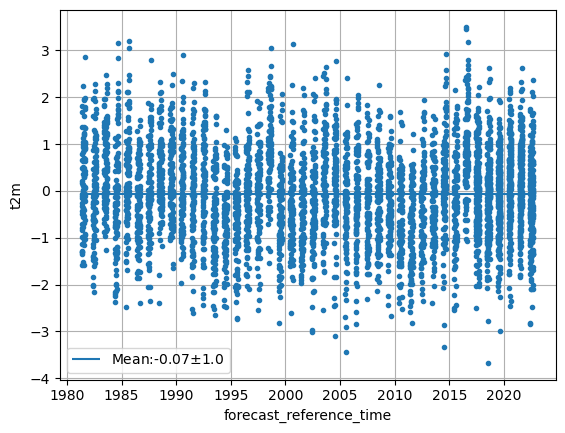

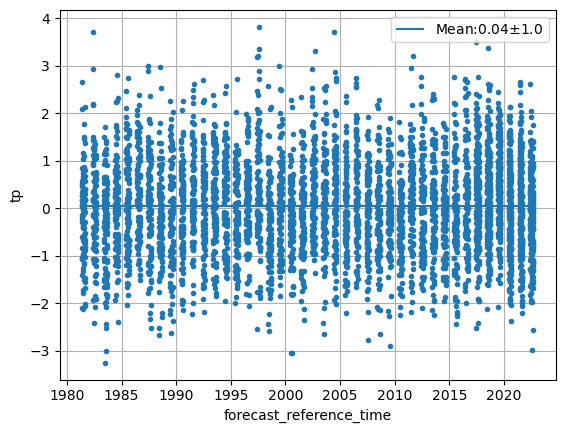

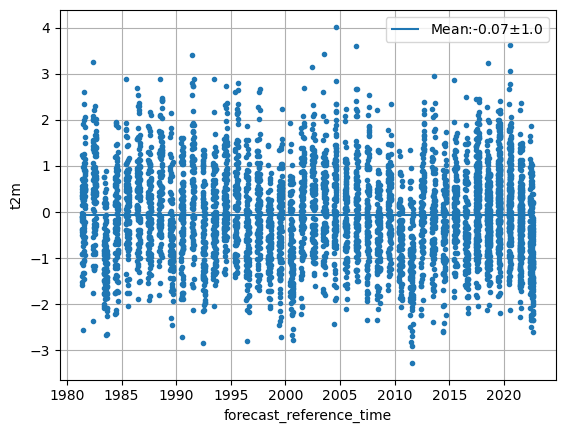

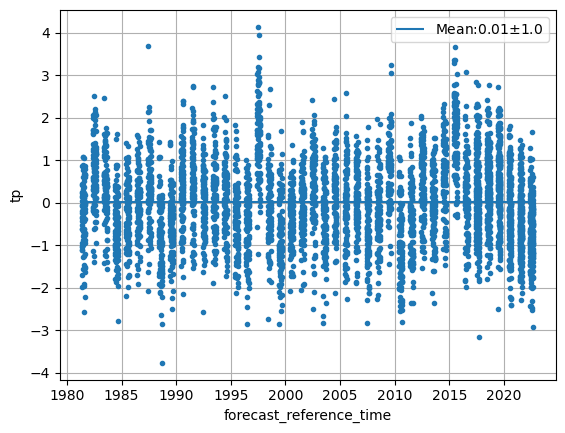

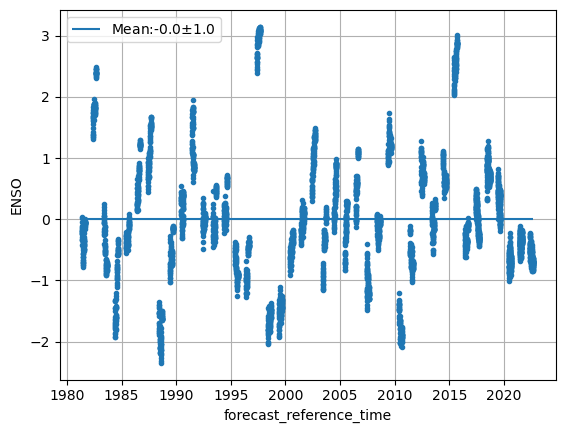

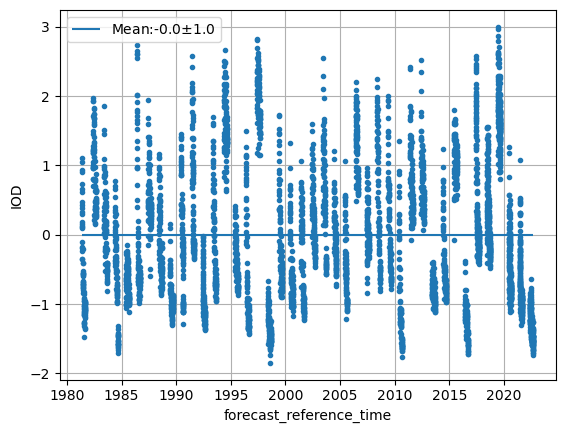

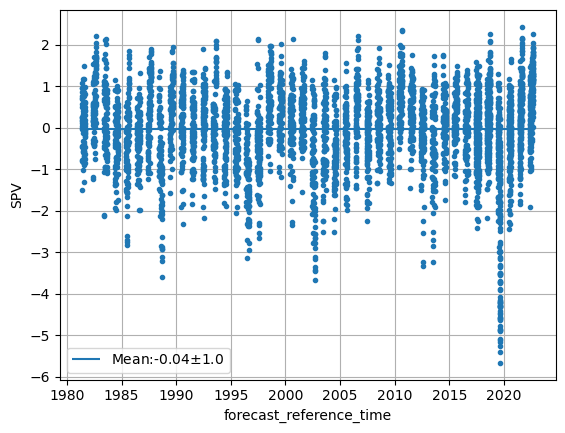

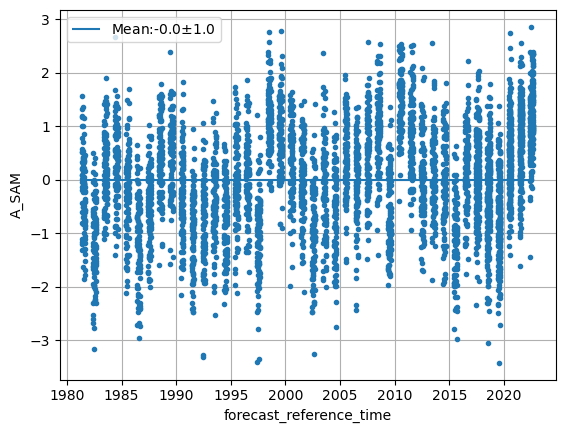

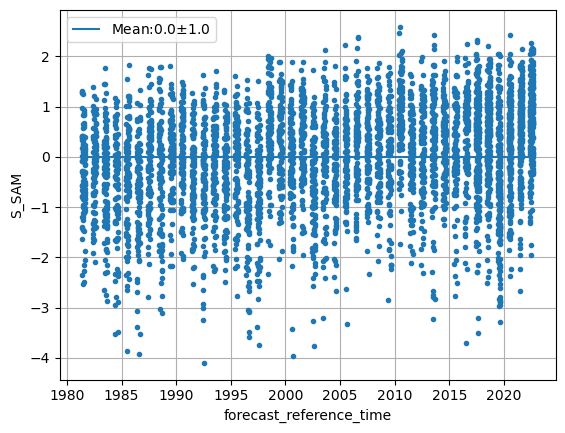

In [32]:
def fast_plotter(array):
    array.plot(x='forecast_reference_time', marker='.', linestyle='none')
    plt.hlines(y=np.nanmean(array), xmin=array.forecast_reference_time.values[0], 
               xmax=array.forecast_reference_time.values[-1],
                 label='Mean:'+ str(round(np.nanmean(array),2))+ '$\pm$'+ str(round( np.nanstd(array),2)) )
    
    plt.legend()
    plt.grid()
    plt.show()



fast_plotter(target_Andes_SON_xr['t2m'])
fast_plotter(target_Andes_SON_xr['tp'])
fast_plotter(target_LP_SON_xr['t2m'])
fast_plotter(target_LP_SON_xr['tp'])
fast_plotter(drivers_SON_xr['ENSO'])
fast_plotter(drivers_SON_xr['IOD'])
fast_plotter(drivers_SON_xr['SPV'])
fast_plotter(drivers_SON_xr['A_SAM'])
fast_plotter(drivers_SON_xr['S_SAM'])

In [35]:
init_sel = np.intersect1d(
    np.unique(VB_DJF_xr.init_month.values),
    np.unique(hind_DJF_LaPlata_xr.init_month.values)
)
print(init_sel)

djf_list = [
    hind_DJF_LaPlata_xr.drop_vars(['season']),
    hind_DJF_Andes_xr.drop_vars(['season']),
    ocean_DJF_xr.drop_vars(['season']),
    VB_DJF_xr,
    SAM_DJF_xr.drop_vars([ 'season'])
]

djf_sel_list = [
    array.where(
        array.init_month.isin(init_sel),
        drop=True
    )
    for array in djf_list
]

[9]


[9 9 9 ... 9 9 9]
[9 9 9 ... 9 9 9]
['1981-09-01T00:00:00.000000000' '1981-09-01T00:00:00.000000000'
 '1981-09-01T00:00:00.000000000' ... '2022-09-01T00:00:00.000000000'
 '2022-09-01T00:00:00.000000000' '2022-09-01T00:00:00.000000000']
['1981-09-01T00:00:00.000000000' '1981-09-01T00:00:00.000000000'
 '1981-09-01T00:00:00.000000000' ... '2022-10-01T00:00:00.000000000'
 '2022-10-01T00:00:00.000000000' '2022-10-01T00:00:00.000000000']


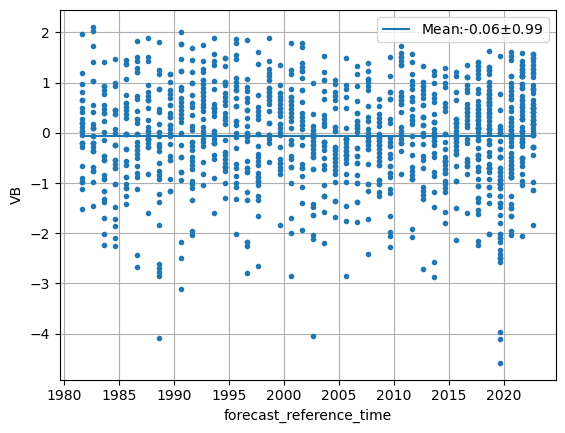

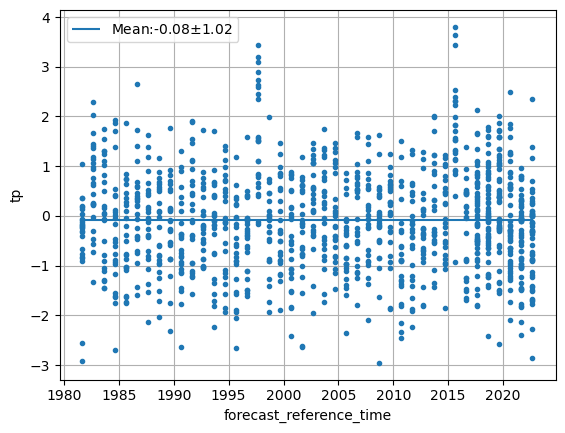

(2142,) (8466,)


In [36]:
print(djf_sel_list[3].init_month.values)
print(djf_sel_list[0].init_month.values)

print((djf_sel_list[3].forecast_reference_time.values))
print((djf_sel_list[0].forecast_reference_time.values))

fast_plotter(djf_sel_list[3]['VB'])
fast_plotter(djf_sel_list[0]['tp'])

print(np.shape(djf_sel_list[3]['VB']), np.shape(djf_sel_list[0]['t2m']))


In [37]:
def get_common_identity(arr):
    return pd.MultiIndex.from_arrays(
        [
            arr.number.values,
            arr.init_month.values,
            arr.forecast_reference_time.values
        ],
        names=[
            'number',
            'init_month',
            'forecast_reference_time'
        ]
    )

identities = [
    get_common_identity(arr)
    for arr in djf_sel_list
]

common_ids = identities[0]

for ids in identities[1:]:
    common_ids = common_ids.intersection(ids)

print("Number of common samples:", len(common_ids))

Number of common samples: 2142


In [38]:
def add_sample_id(arr):
    return arr.assign_coords(
        sample_id=(
            "sample",
            [
                f"{n}_{t}"
                for n, t in zip(
                    arr.number.values,
                    arr.forecast_reference_time.values
                )
            ]
        )
    )

djf_sel_list = [
    add_sample_id(arr)
    for arr in djf_sel_list
]

common_ids = set(djf_sel_list[0].sample_id.values)

for arr in djf_sel_list[1:]:
    common_ids &= set(arr.sample_id.values)

print(len(common_ids))

common_ids = list(common_ids)

aligned = [
    arr.where(
        arr.sample_id.isin(common_ids),
        drop=True
    )
    for arr in djf_sel_list
]

2142


In [39]:
aligned_DJF_no_VB=align_hindcast_arrays([hind_DJF_LaPlata_xr, hind_DJF_Andes_xr, ocean_DJF_xr, SAM_DJF_xr])
target_Andes_DJF_xr_no_VB=aligned_DJF_no_VB[1]
target_LP_DJF_xr_no_VB=aligned_DJF_no_VB[0]
drivers_aligned_no_VB=aligned_DJF_no_VB[2:]
drivers_DJF_xr_no_VB=xr.merge(drivers_aligned_no_VB)


BASIC STRUCTURE
array_0         sample size = 33864
array_1         sample size = 33864
array_2         sample size = 33864
array_3         sample size = 33864

CHECKING SAMPLE COORDINATES
array_0        : all coordinates present
array_1        : all coordinates present
array_2        : all coordinates present
array_3        : all coordinates present

CONSTRUCTING SAMPLE IDENTITIES
array_0        : 33864 unique / 33864 total
array_1        : 33864 unique / 33864 total
array_2        : 33864 unique / 33864 total
array_3        : 33864 unique / 33864 total

POSITIONAL COMPARISON

number
  array_0 == array_1: True
  array_0 == array_2: True
  array_0 == array_3: True

init_month
  array_0 == array_1: True
  array_0 == array_2: True
  array_0 == array_3: True

season
  array_0 == array_1: True
  array_0 == array_2: True
  array_0 == array_3: True

forecast_reference_time
  array_0 == array_1: True
  array_0 == array_2: True
  array_0 == array_3: True

SAMPLE SET COMPARISON

array_0 vs arra

In [40]:
#summer
#all_aligned_DJF=align_hindcast_arrays(aligned, 
#                                  names=['LaPlata','Andes','ocean', 'VB', 'SAM'])
target_Andes_DJF_xr=aligned[1]
target_LP_DJF_xr=aligned[0]
drivers_aligned_DJF=aligned[2:]
drivers_DJF_xr=xr.merge(drivers_aligned_DJF)

In [41]:
target_LP_DJF_xr

<xarray.Dataset> Size: 360kB
Dimensions:                  (sample: 2142)
Coordinates:
    init_month               (sample) int64 17kB 9 9 9 9 9 9 9 ... 9 9 9 9 9 9 9
    forecast_reference_time  (sample) datetime64[ns] 17kB 1981-09-01 ... 2022...
    number                   (sample) int64 17kB 0 1 2 3 4 5 ... 46 47 48 49 50
    sample_id                (sample) <U32 274kB '0_1981-09-01T00:00:00.00000...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 17kB -0.5459 -0.3709 ... 0.105
    tp                       (sample) float64 17kB -0.7629 0.1894 ... -2.276

## Start regression part

In [42]:
import sys
sys.path.insert(0, "../whole_period_effects")  # add Folder_2 path to search list

import Functions

In [43]:
drivers_SON= ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
drivers_tot_SON=['ENSO', 'IOD', 'SPV']

In [44]:
def bootstrap_regression(
    target_ds,
    driver_ds,
    target_var,
    driver_vars,
    n_boot=50,
    sample_size=10000,
    add_intercept=True,
    printer=False,
    seed=42,
    quantiles=None,
    total_eff=False
):
    """
    target_var: string, e.g. "tprate" or "t2m"
    driver_vars: list of strings, e.g. ["nino34"] or ["nino34", "iod_index"]
    """

    results = []

    n_samples = target_ds.sizes["sample"]

    # Check that target and drivers have same number of samples
    for var in driver_vars:
        if driver_ds.sizes["sample"] != n_samples:
            raise ValueError(
                f"Target and driver sample sizes differ: "
                f"target={n_samples}, {var}={driver_ds.sizes['sample']}"
            )

    #include driver_vars selection as in bachelor thesis
    controls_dict = modify_driver_list(
        driver_vars,
        total_eff=total_eff
    )

    #rerun yields the same result
    rng = np.random.default_rng(seed)

    #get bootstrap indices before opening loop to ensure each driver regression has same samples
    bootstrap_indices = [
        rng.choice(
            n_samples,
            size=sample_size,
            replace=True
        )
        for _ in range(n_boot)
    ]

        
    #initalize counter on how many bootstraps have enough values
    counter=0
    for driver in driver_vars:
        controls = controls_dict[driver]

        #special case handling: ENSO total effect needs no controls
        if controls is None:
            regression_vars=[driver]
        else:
            regression_vars = [driver] + controls
        if ~printer:
            print(driver, regression_vars)
            
        for i, idx in enumerate(bootstrap_indices):
    

            y = target_ds[target_var].isel(sample=idx).values

            X = pd.DataFrame({
            var: driver_ds[var].isel(sample=idx).values
            for var in regression_vars
            })

            df = X.copy()
            df["target"] = y
            df = df.dropna()

            # Number of valid observations
            n_valid = len(df)

            # Not enough data to fit regression
            if n_valid == 0:
                print(f"Bootstrap {i}: 0 valid samples -- skipping")
                continue

            # Need at least more observations than parameters
            n_predictors = len(regression_vars)
            n_parameters = n_predictors + int(add_intercept)

            if n_valid <= n_parameters:
                if printer:
                    print(
                    f"Bootstrap {i}: only {n_valid} valid samples "
                    f"for {n_parameters} parameters -- skipping"
                    )
                else:
                    counter+=1
                continue

            X_clean = df[regression_vars]
            y_clean = df["target"]

            if add_intercept:
                X_clean = sm.add_constant(X_clean)

        
            
            if quantiles is None:
                model = sm.OLS(y_clean, X_clean).fit()

                row = {
                                    "bootstrap": i,
                                    "target": target_var,
                                    "drivers": "+".join(regression_vars),
                                    "r2": model.rsquared
                                }
                for name, value in model.params.items():
                            if name==driver:
                                row[f"coef_{name}"] = value

            else:
                #quantiles = [0.05, 0.5, 0.95]
                
                for quantile in quantiles:
                    qr = QuantileRegressor(quantile=quantile, fit_intercept=add_intercept, alpha=0)
                    model = qr.fit(X_clean, y_clean)

                    row = {
                                        "bootstrap": i,
                                        "target": target_var,
                                        "drivers": "+".join(regression_vars),
                                        f"r2_{quantile}": model.score
                                    }
                    
                    # Pairs column names directly with their respective slope
                    for col_name, coef_val in zip(X.columns, model.coef_):
                        row[f'coef_{col_name}_{quantile}'] = coef_val
                        
                    if add_intercept:
                        row[f'intercept_{quantile}'] = model.intercept_

    
        

            results.append(row)

    if ~printer:
        print('Valid bootstraps: '+ str(n_boot-counter)+'/'+str(n_boot))
    return pd.DataFrame(results)



In [45]:
def modify_driver_list(driver_list, total_eff=False):

    controls_dict = {}

    for driver in driver_list:

        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            # A-SAM has to be removed for symmetric response quantifications
            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            # Vortex and S-SAM need to be removed for asymmetric response
            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [
                    c for c in controls
                    if c not in ['SPV', 'VB', 'S_SAM']
                ]

        else:
            if driver in ['IOD', 'IOBW']:
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None

        controls_dict[driver] = controls

    return controls_dict

In [46]:
def plot_bootstrap_coefficients(results, driver_vars, title="Bootstrap regression coefficients", bins_num=100):

    fsize=18
    lim_x=5.0
    ncols=len(driver_vars)

    global_max=max(
        np.max(np.abs(results[f"coef_{driver}"]))
        for driver in driver_vars
    )

    fig, axes = plt.subplots(
    ncols=ncols,
    figsize=(ncols * 6, 6),
    sharey=True,
    squeeze=False
    )

    axes = axes.ravel()

    for i, var in enumerate(driver_vars):
        n, bins, _=axes[i].hist(
            results[f"coef_{var}"],
            bins=bins_num #,
            #label=var
        )

        subplot_title=var

        mean = results[f"coef_{var}"].mean()
        std = results[f"coef_{var}"].std()

        #add CI
        lower = np.nanpercentile(results[f'coef_{var}'], 2.5)
        upper = np.nanpercentile(results[f'coef_{var}'], 97.5)

        significant = (lower > 0) or (upper < 0)

        axes[i].axvline(
                    mean,
                    linestyle="--", color='red', 
                    label=f'Mean: {mean:.2f}'
                )

        #axes[i].axvline(era5_vals[i], color='black', label=f'ERA5: {era5_vals[i]:.2f}')

        #axes[i].axvspan(xmin=mean-std, xmax=mean+std, alpha=.3, color='red', label='$\pm 1 \sigma$: '+str(round(std,2)))
        axes[i].axvspan(xmin=lower, xmax=upper, alpha=.3, color='red', label=f'95% CI: [{lower:.2f}, {upper:.2f}]')
        if significant:
            axes[i].text(
                0.8, 0.15,
                "Significant \n link",
                transform=axes[i].transAxes,
                ha="center",
                va="top",
                fontsize=18
            )

        axes[i].set_xlabel(f"Reg coef of {var}", fontsize=fsize)
        axes[i].tick_params( axis="both",
                    which="major",
                    labelsize=fsize)
        axes[i].grid(alpha=.3)
        axes[i].legend(fontsize=fsize)
        #restrict x axis to some value
        if global_max>lim_x:
            subplot_title+=' (*)'

        else:
            lim_x=global_max
    
        axes[i].set_xlim(-lim_x,lim_x)
        axes[i].set_title(subplot_title, fontsize=fsize, fontweight='bold')

    axes[0].set_ylabel("Count", fontsize=fsize)
    fig.suptitle(title, fontsize=fsize+4, fontweight='heavy', y=1.1)
    plt.show()

# Investigate the distributions of different init months

Direct effect on Andes spring temperature and precipitation

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


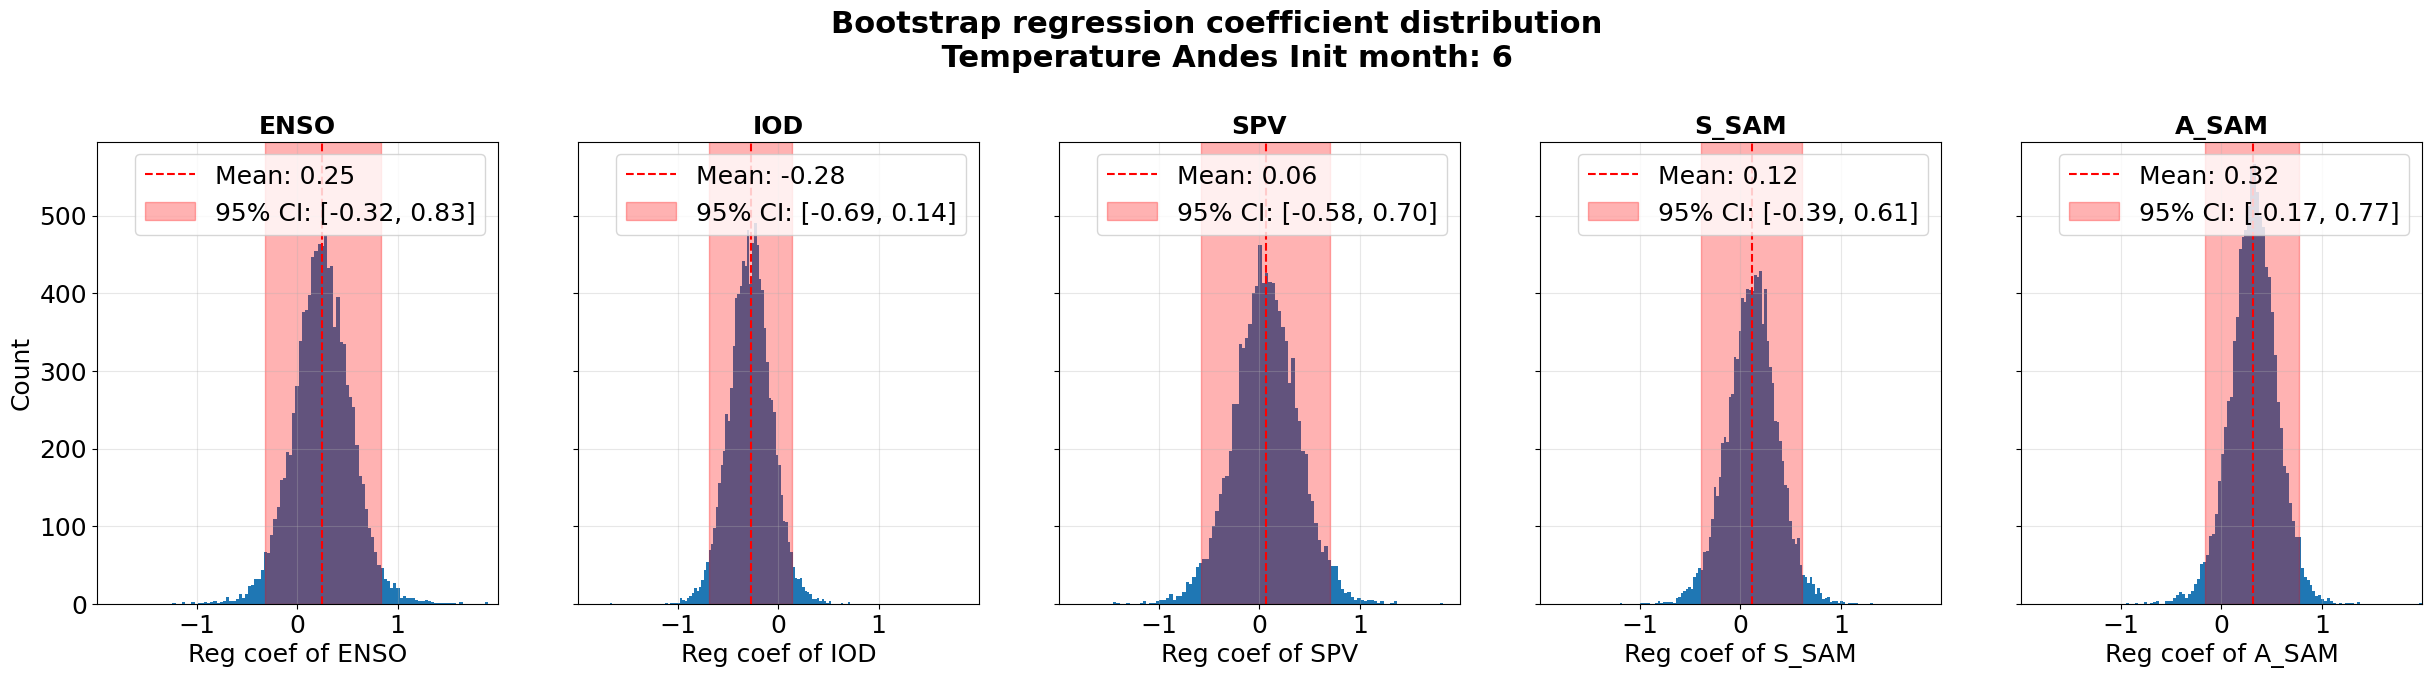

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


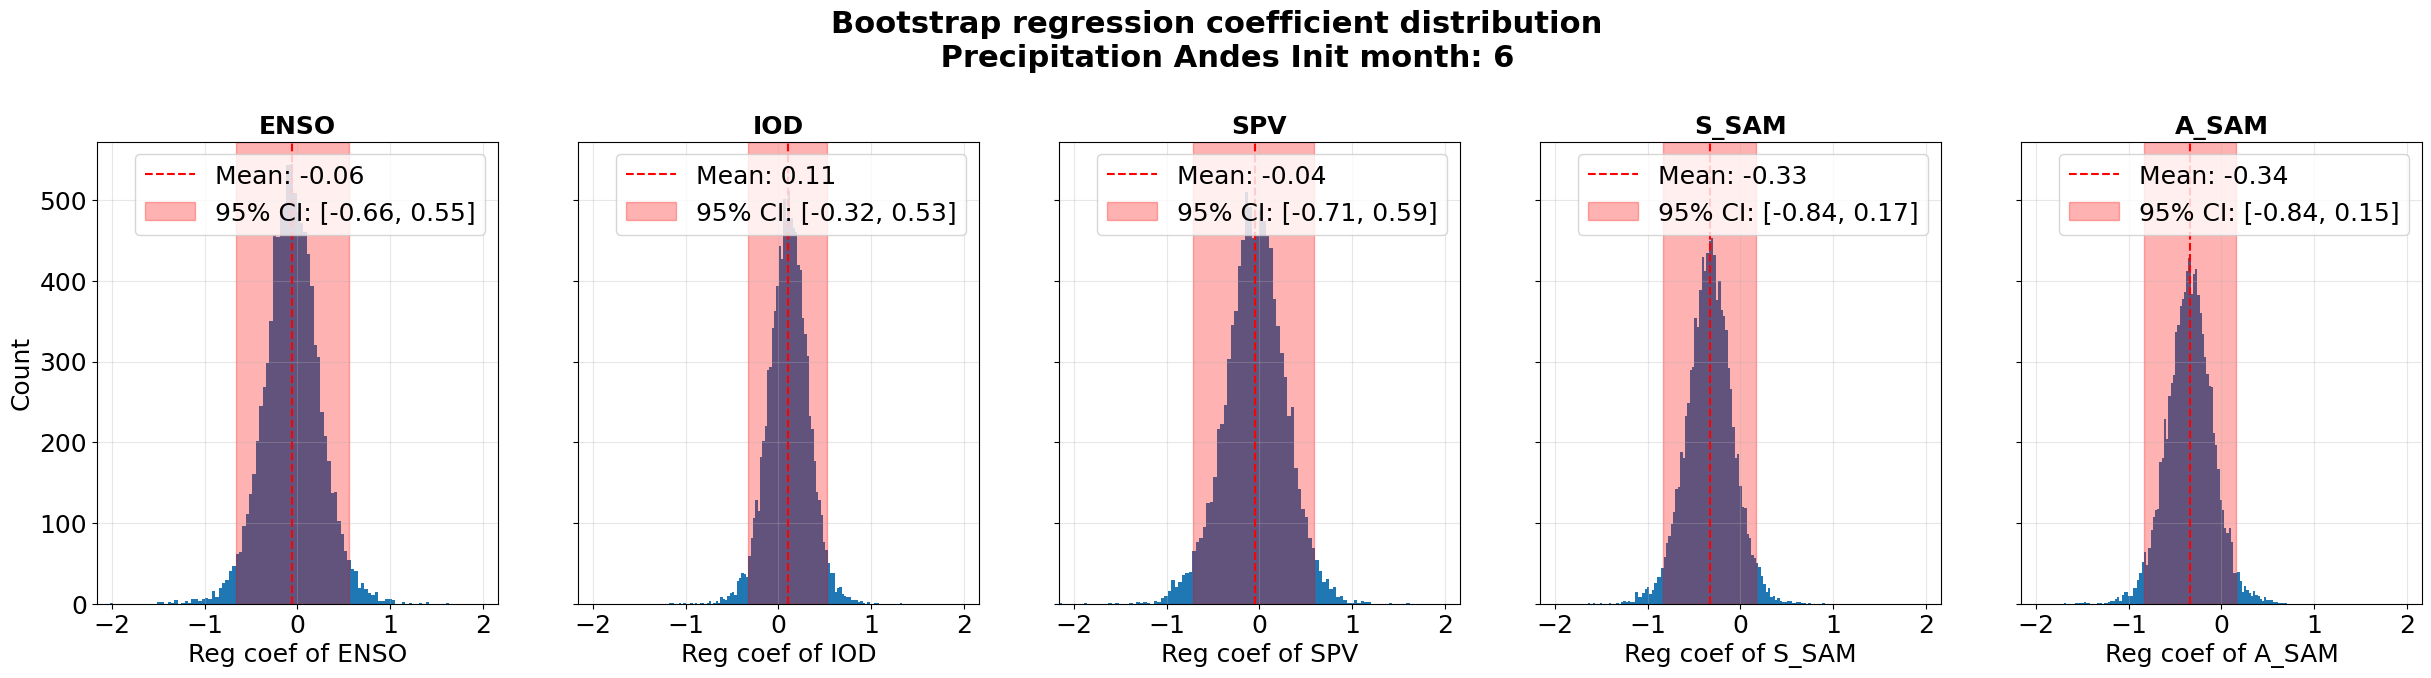

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


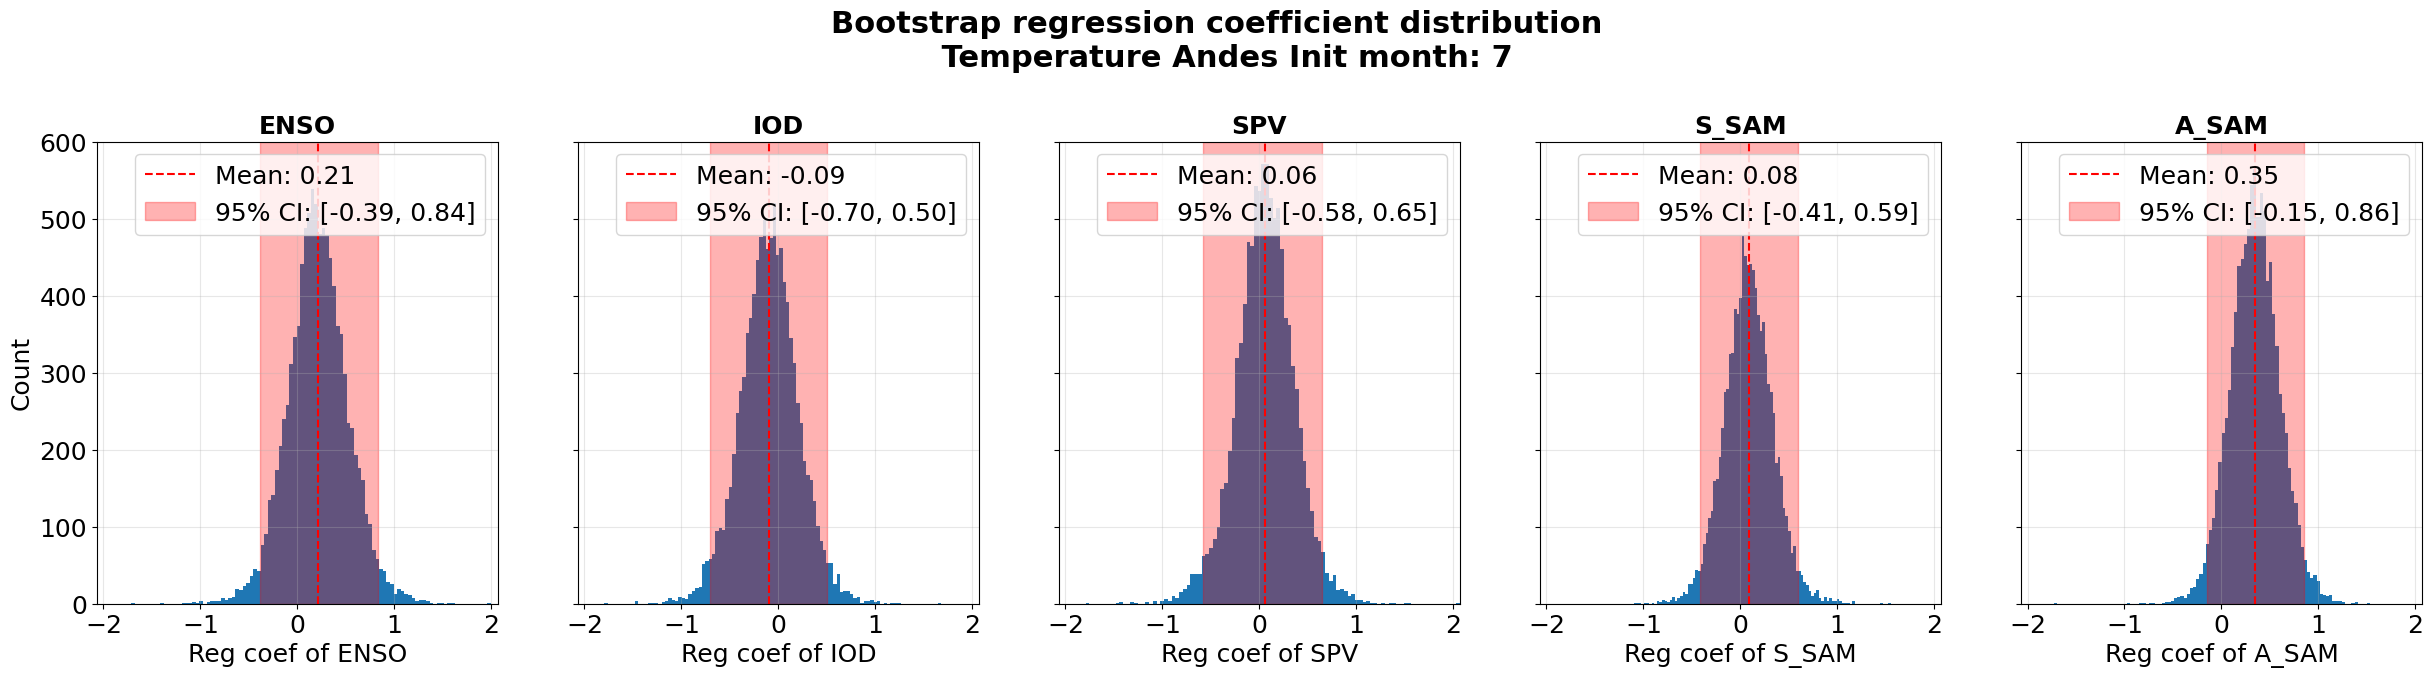

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


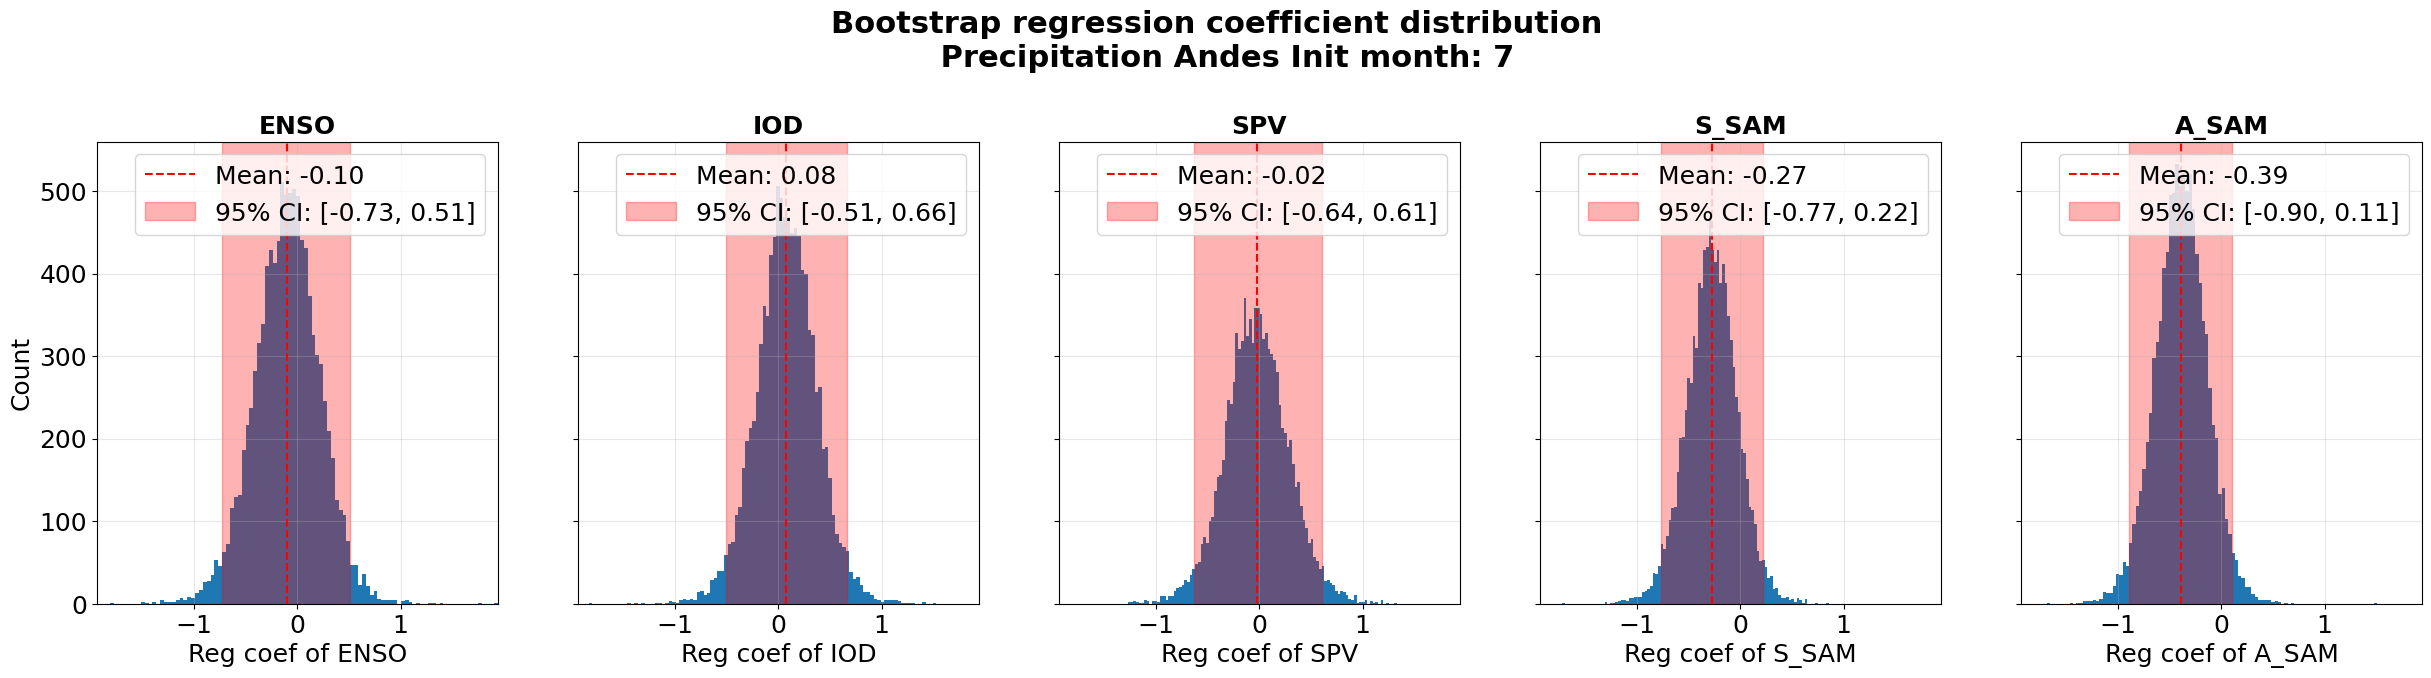

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


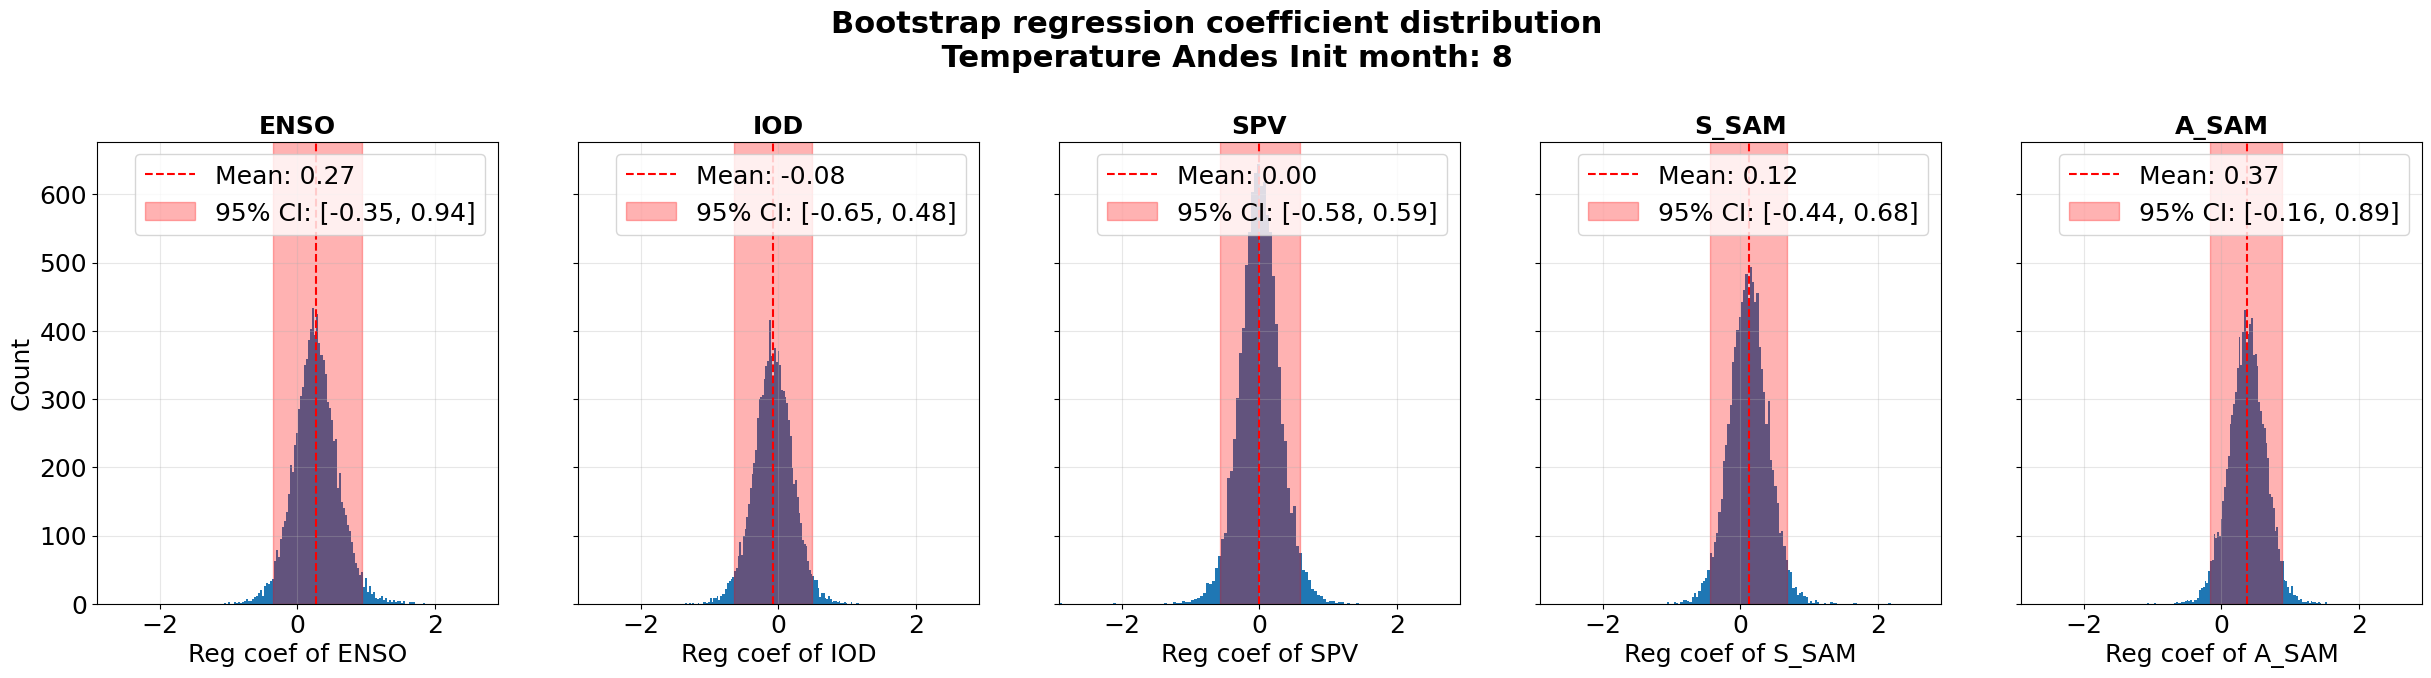

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


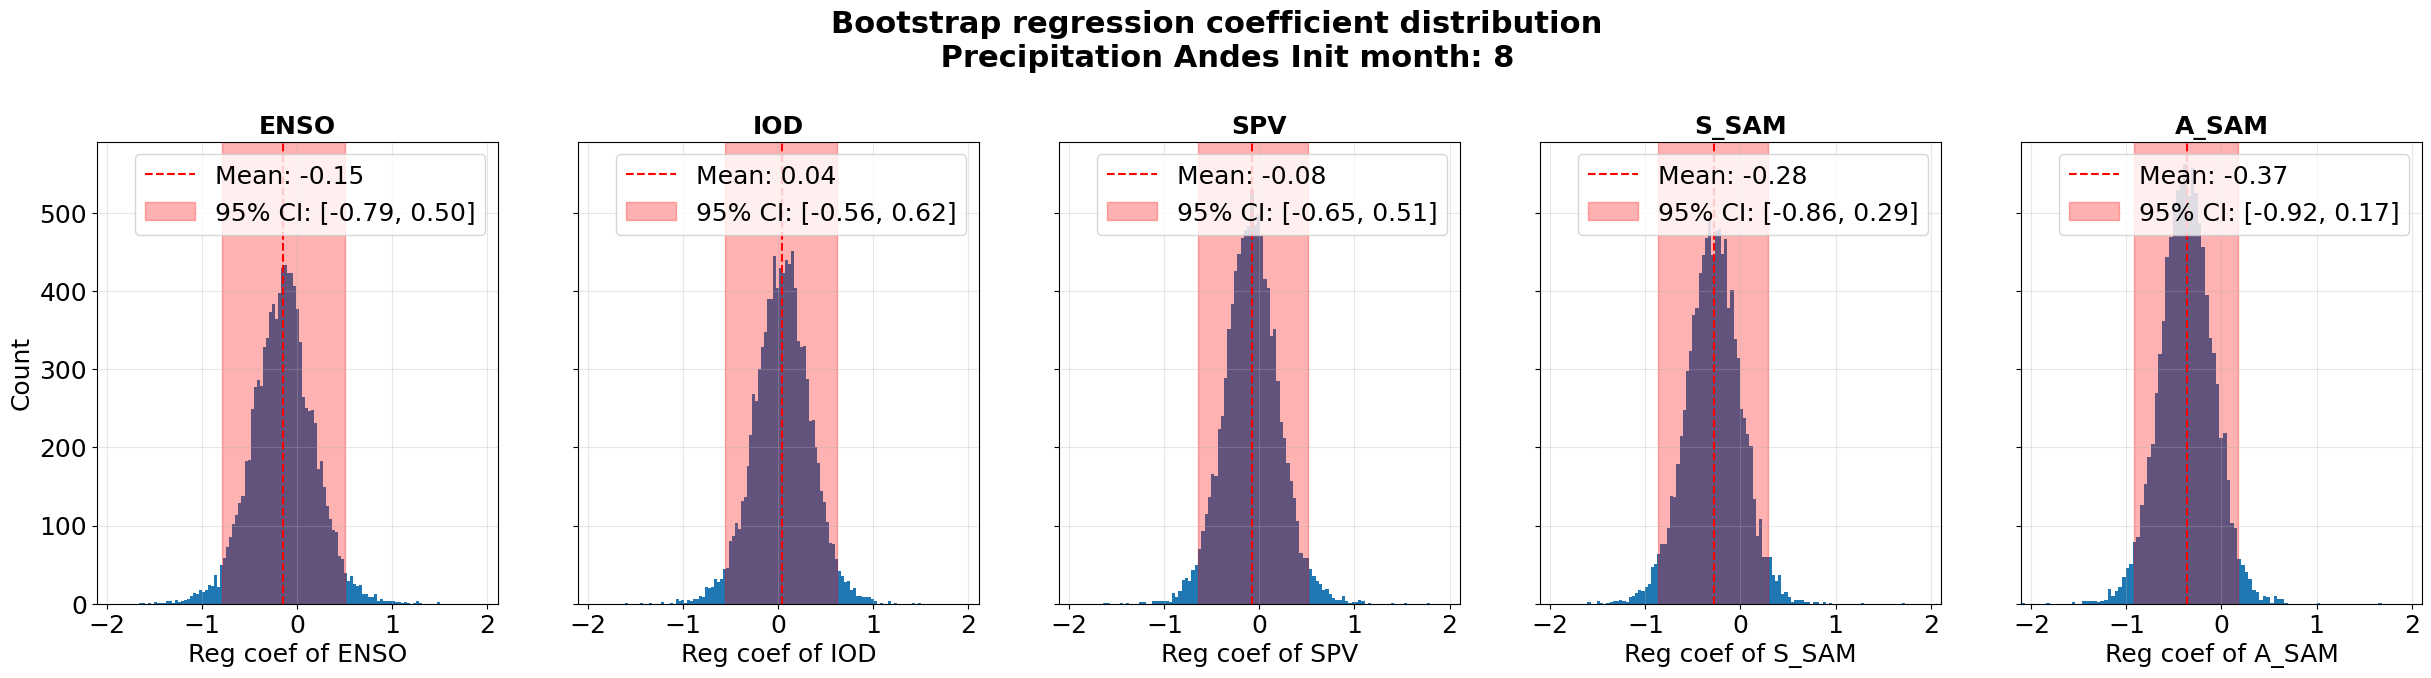

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


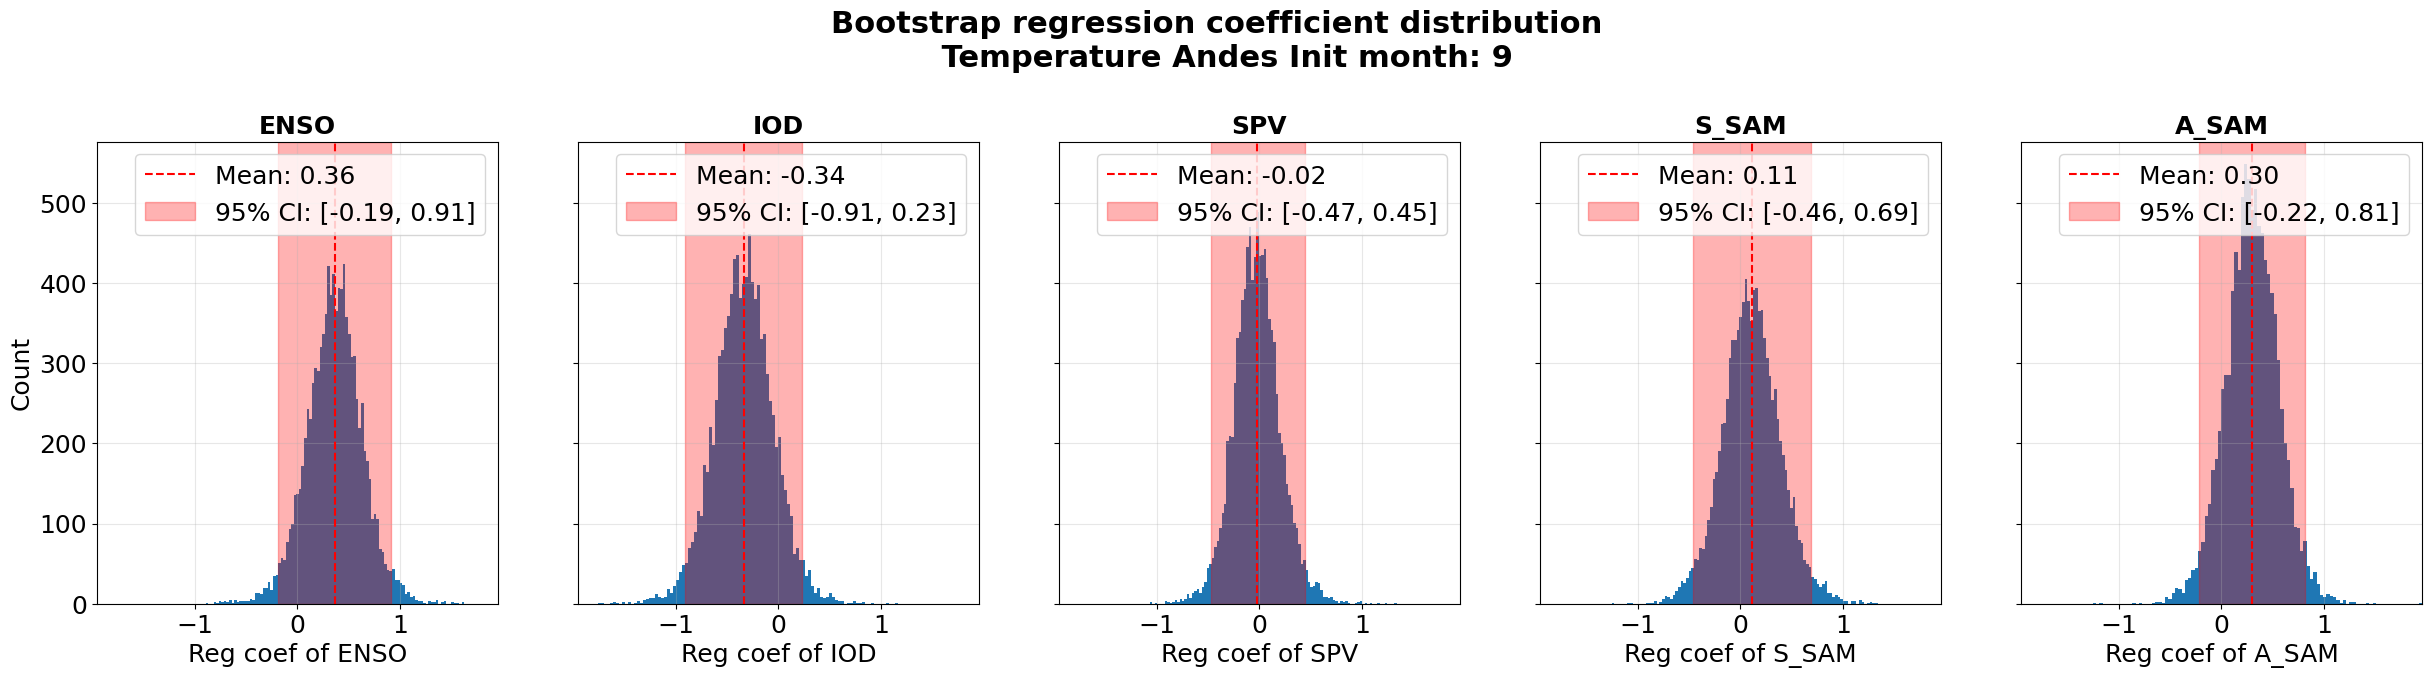

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


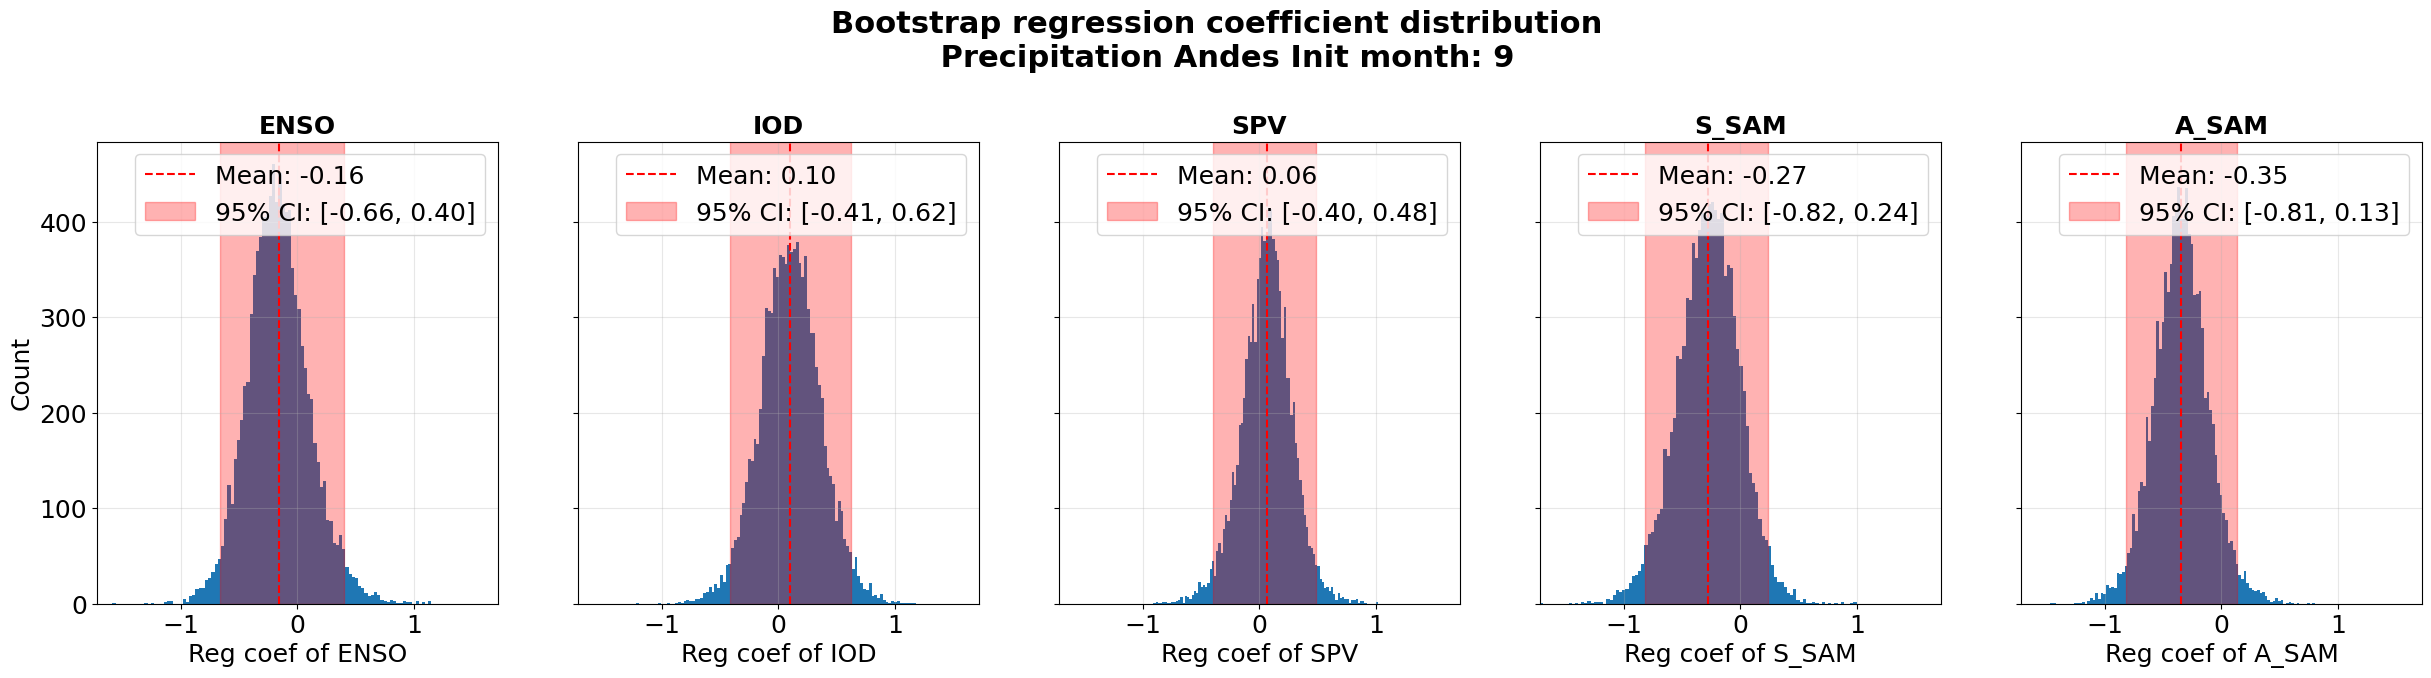

In [47]:
for init in np.unique(target_Andes_SON_xr.init_month.values):
    results_direct_T_Andes_SON_300 = bootstrap_regression(
    target_ds=target_Andes_SON_xr.where(target_Andes_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="t2m",
    driver_vars=drivers_SON,
    n_boot=10000,
    add_intercept=False,
    sample_size=200
    )

    plot_bootstrap_coefficients(results_direct_T_Andes_SON_300, drivers_SON,
                                title=f'Bootstrap regression coefficient distribution \n Temperature Andes Init month: {init}')


    results_direct_Pr_Andes_SON_300 = bootstrap_regression(
        target_ds=target_Andes_SON_xr.where(target_Andes_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="tp",
        driver_vars=drivers_SON,
        n_boot=10000,
        add_intercept=False,
        sample_size=200
        )

    plot_bootstrap_coefficients(results_direct_Pr_Andes_SON_300, drivers_SON,
                                    title=f'Bootstrap regression coefficient distribution \n Precipitation Andes Init month: {init}')

In [48]:
target_Andes_SON_xr.where(target_Andes_SON_xr.init_month==6, drop=True)
#should I still use so many samples and bootstraps?
#I mean likely they get mixed

<xarray.Dataset> Size: 446kB
Dimensions:                  (sample: 8568)
Coordinates:
    init_month               (sample) int64 69kB 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6
    season                   (sample) <U3 103kB 'SON' 'SON' ... 'SON' 'SON'
    forecast_reference_time  (sample) datetime64[ns] 69kB 1981-06-01 ... 2022...
    number                   (sample) int64 69kB 0 1 2 3 4 5 ... 46 47 48 49 50
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 69kB 1.356 -1.314 ... nan nan
    tp                       (sample) float64 69kB -1.021 -1.067 ... nan nan

Direct effect on La Plata temperature

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']


IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


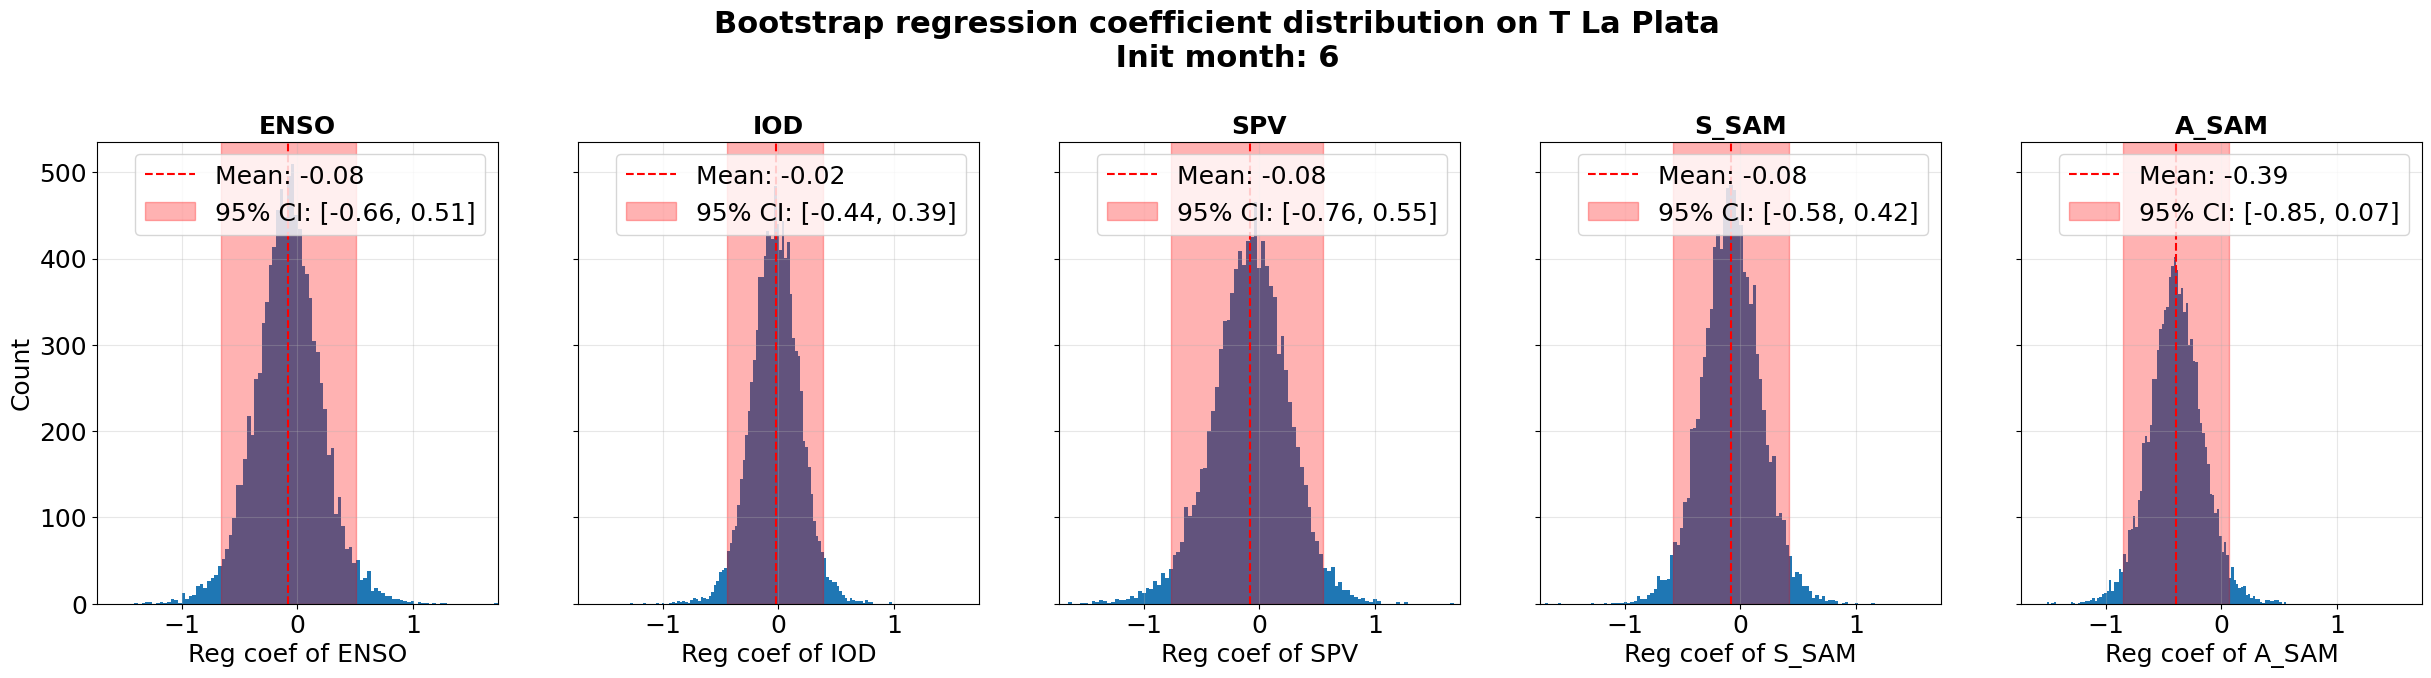

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


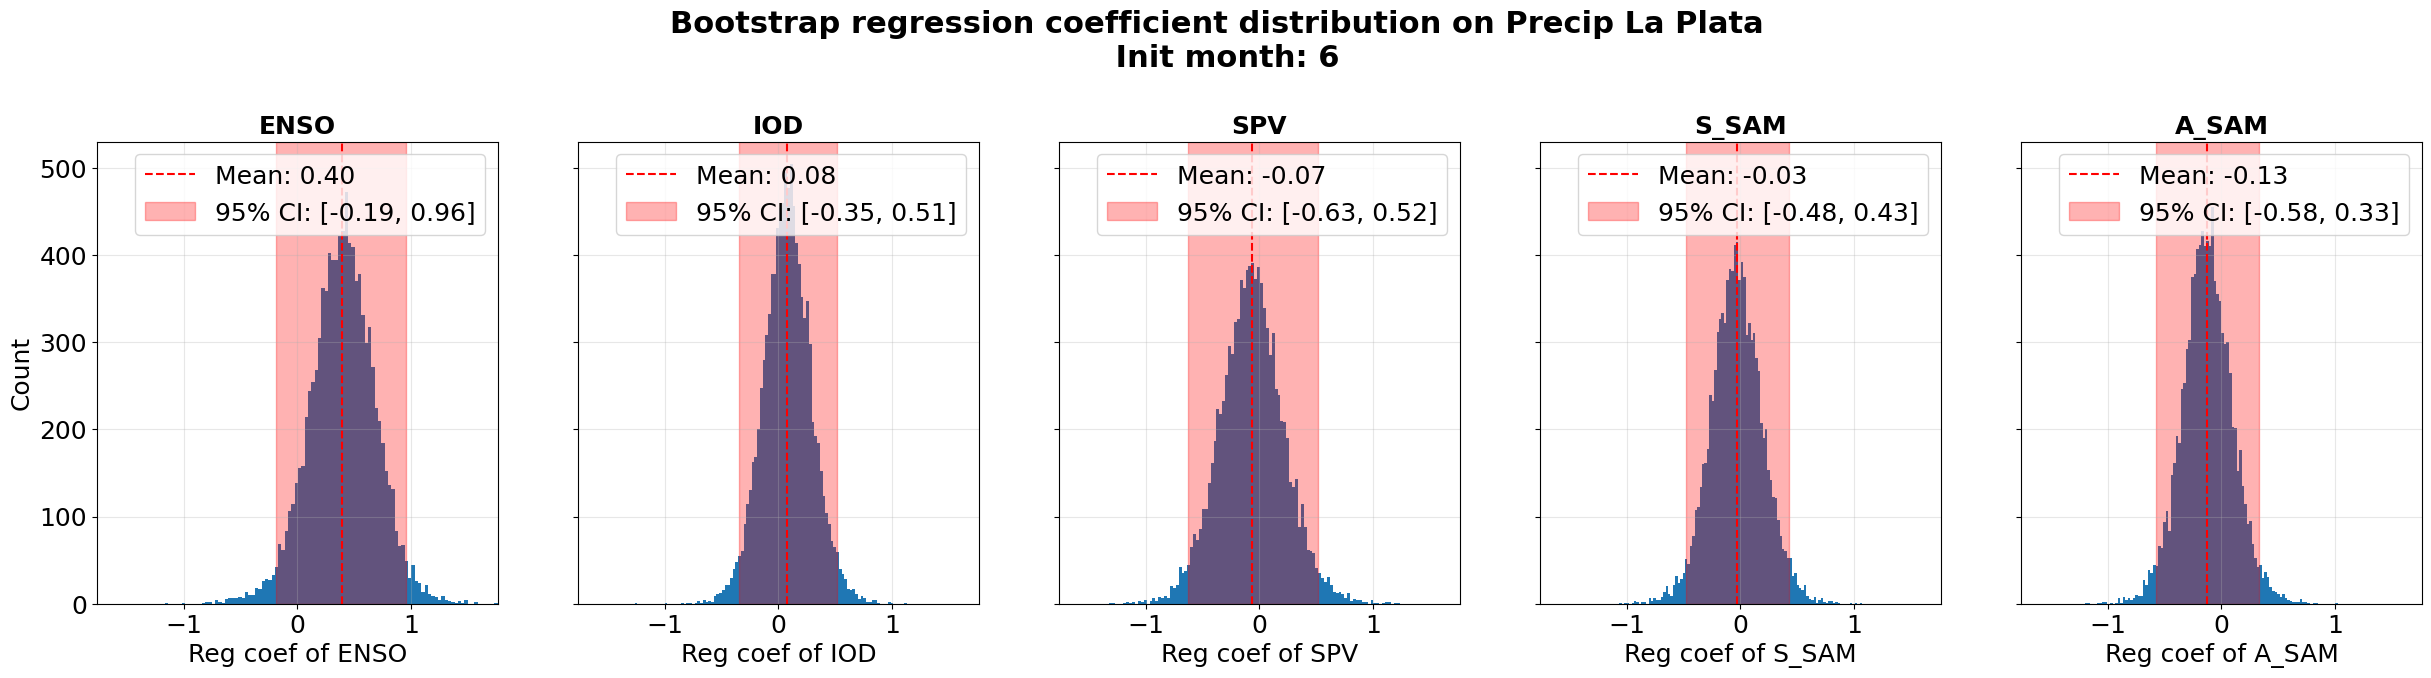

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


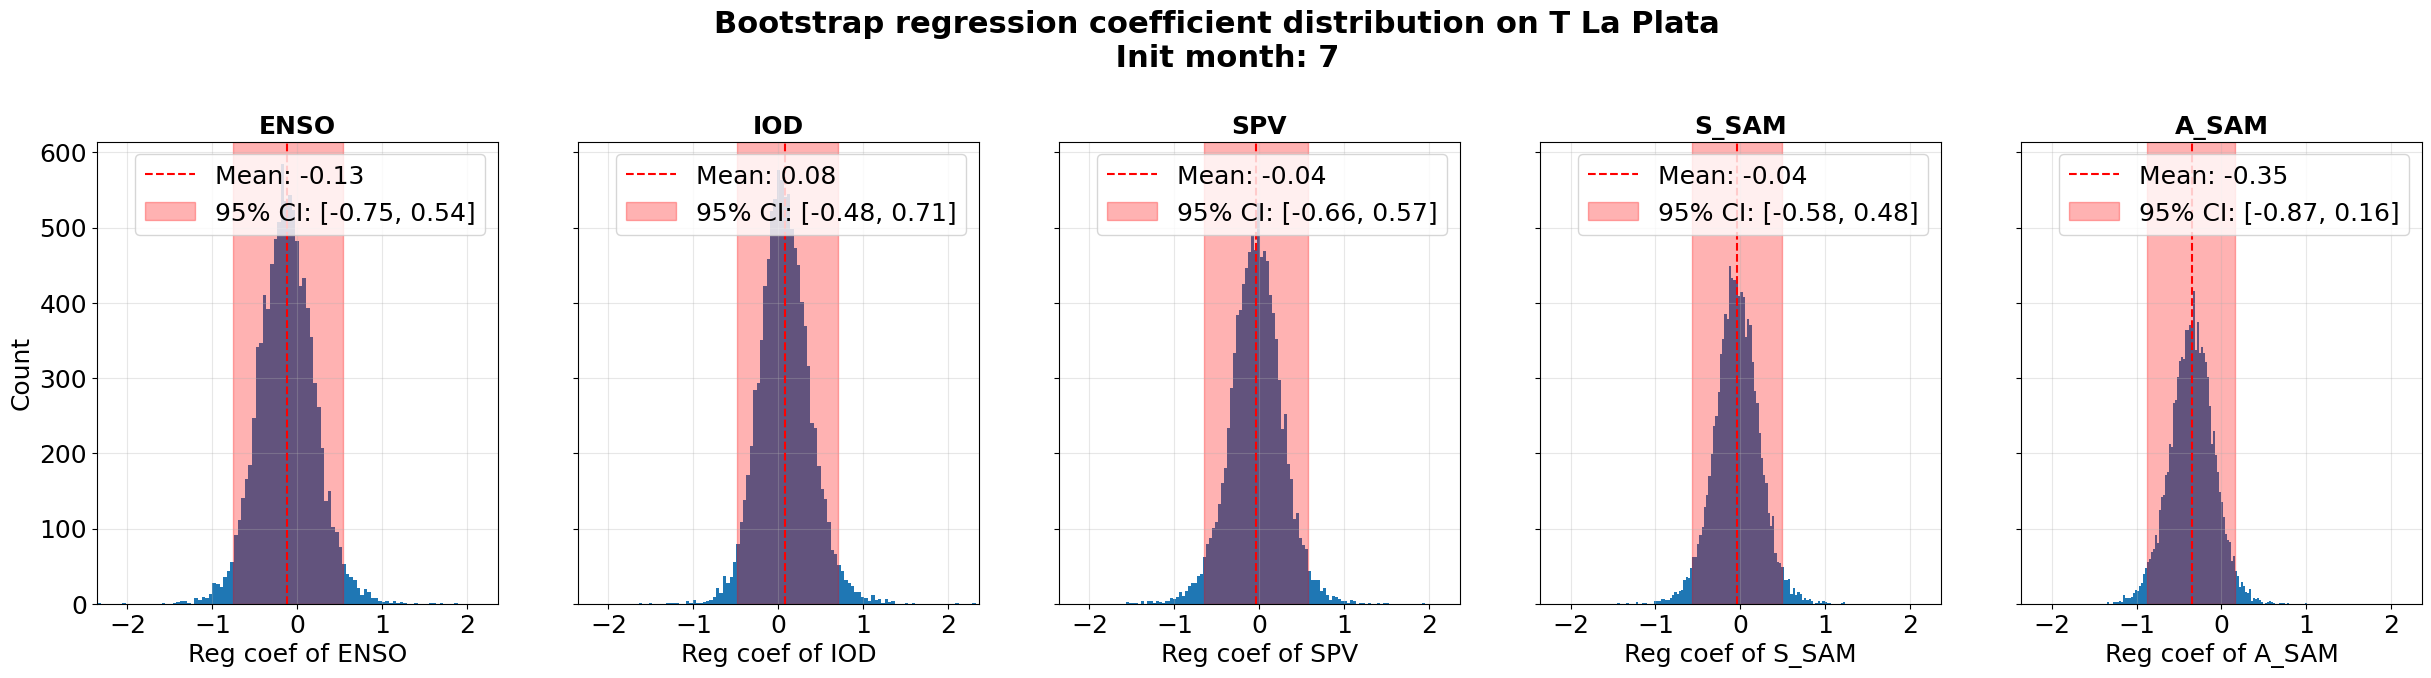

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


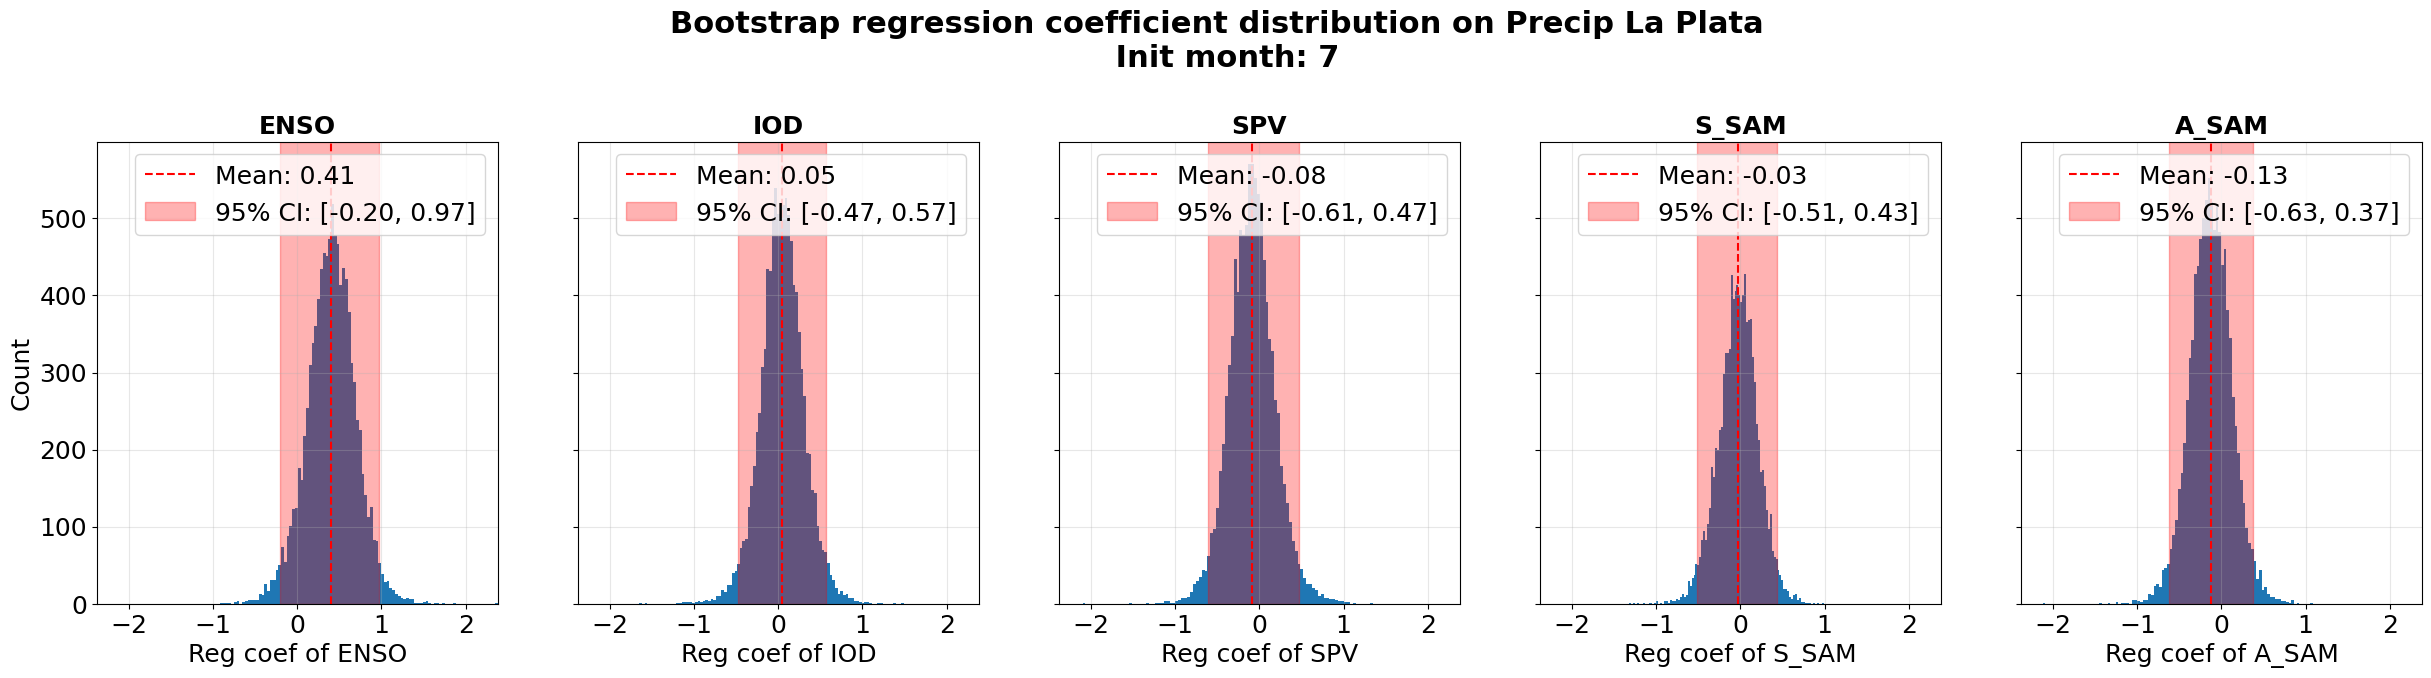

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


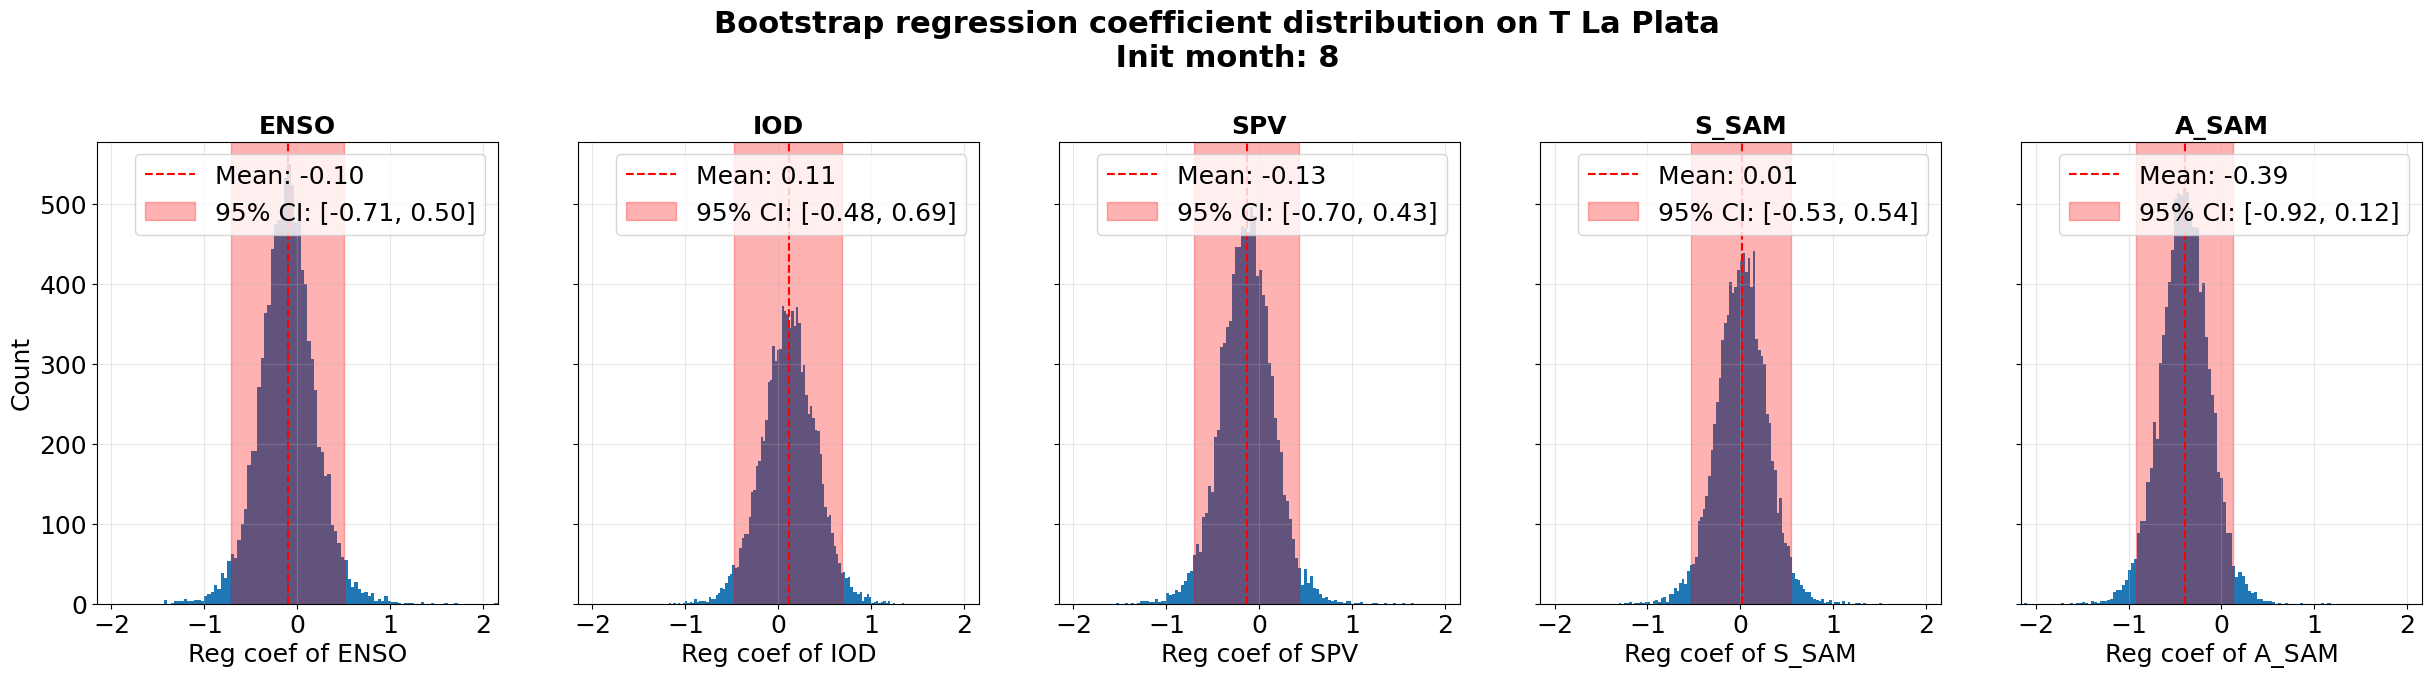

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


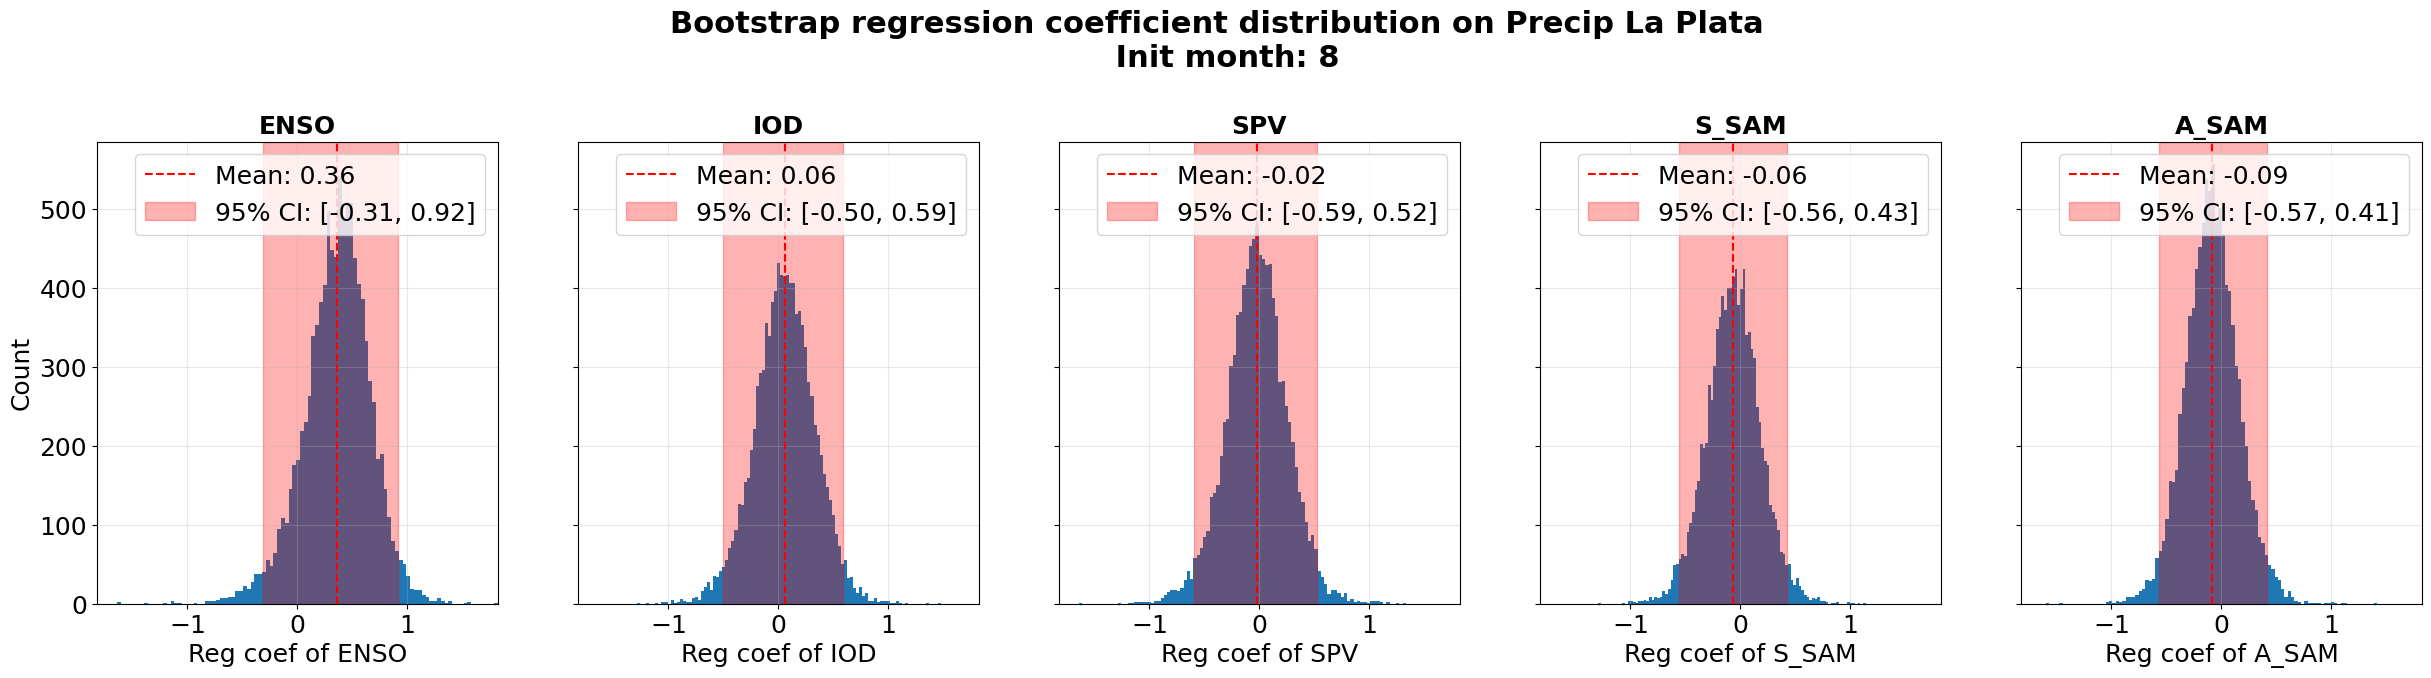

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


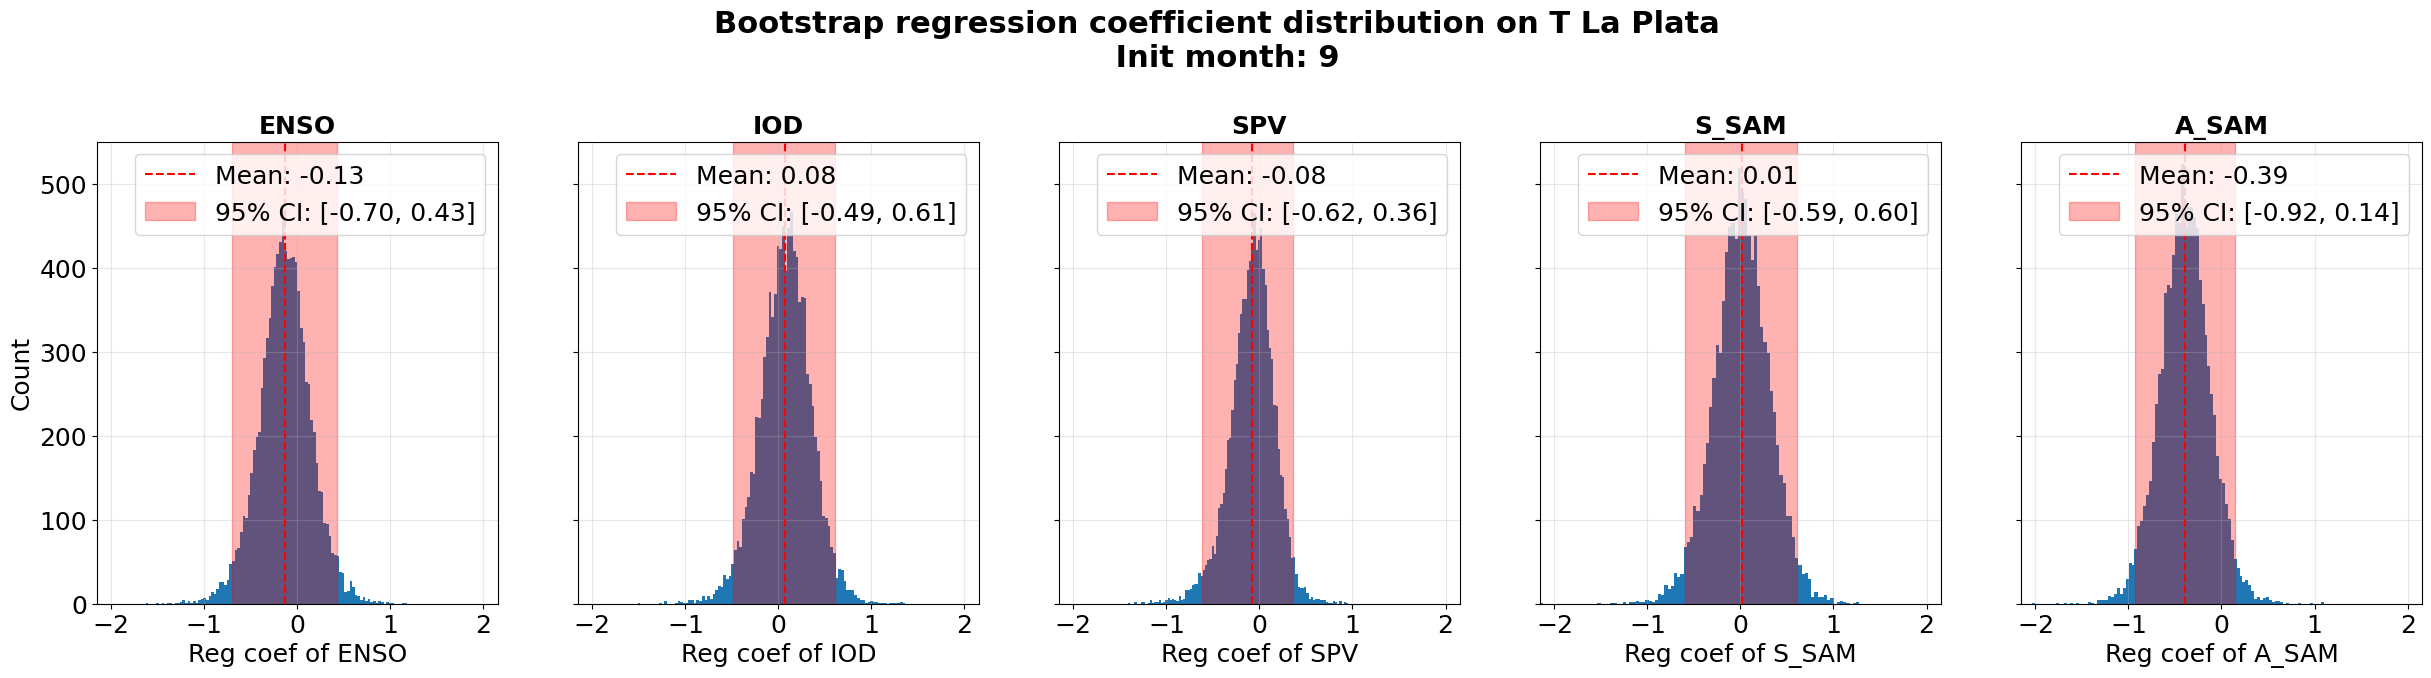

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


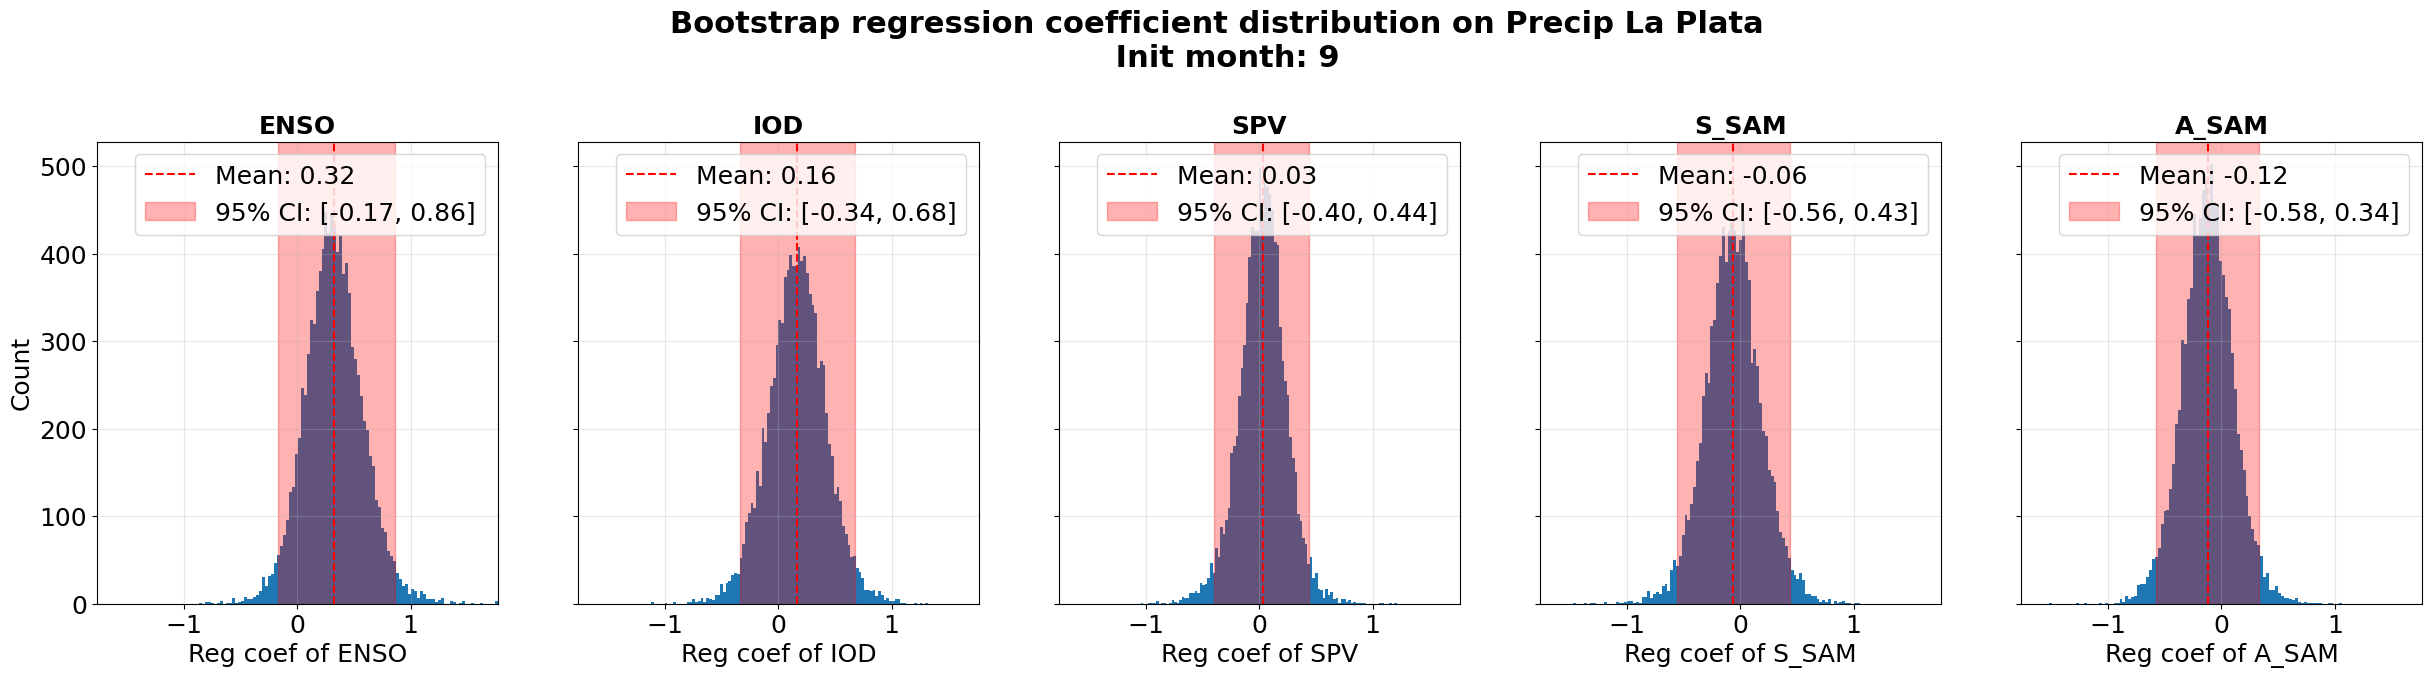

In [49]:
#La Plata temperature
for init in np.unique(target_LP_SON_xr.init_month.values):
    results_direct_T_LP_SON_300 = bootstrap_regression(
    target_ds=target_LP_SON_xr.where(target_LP_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="t2m",
    driver_vars=drivers_SON,
    n_boot=10000,
    add_intercept=False,
    sample_size=200
    )

    plot_bootstrap_coefficients(results_direct_T_LP_SON_300, drivers_SON,
                                title=f'Bootstrap regression coefficient distribution on T La Plata \n Init month: {init}')

    results_direct_Pr_LP_SON_300 = bootstrap_regression(
        target_ds=target_LP_SON_xr.where(target_LP_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="tp",
        driver_vars=drivers_SON,
        n_boot=10000,
        add_intercept=False,
        sample_size=200
        )
    
    plot_bootstrap_coefficients(results_direct_Pr_LP_SON_300, drivers_SON,
                                    title=f'Bootstrap regression coefficient distribution on Precip La Plata \n Init month: {init}')

Total effects Andes SON

ENSO ['ENSO']


IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


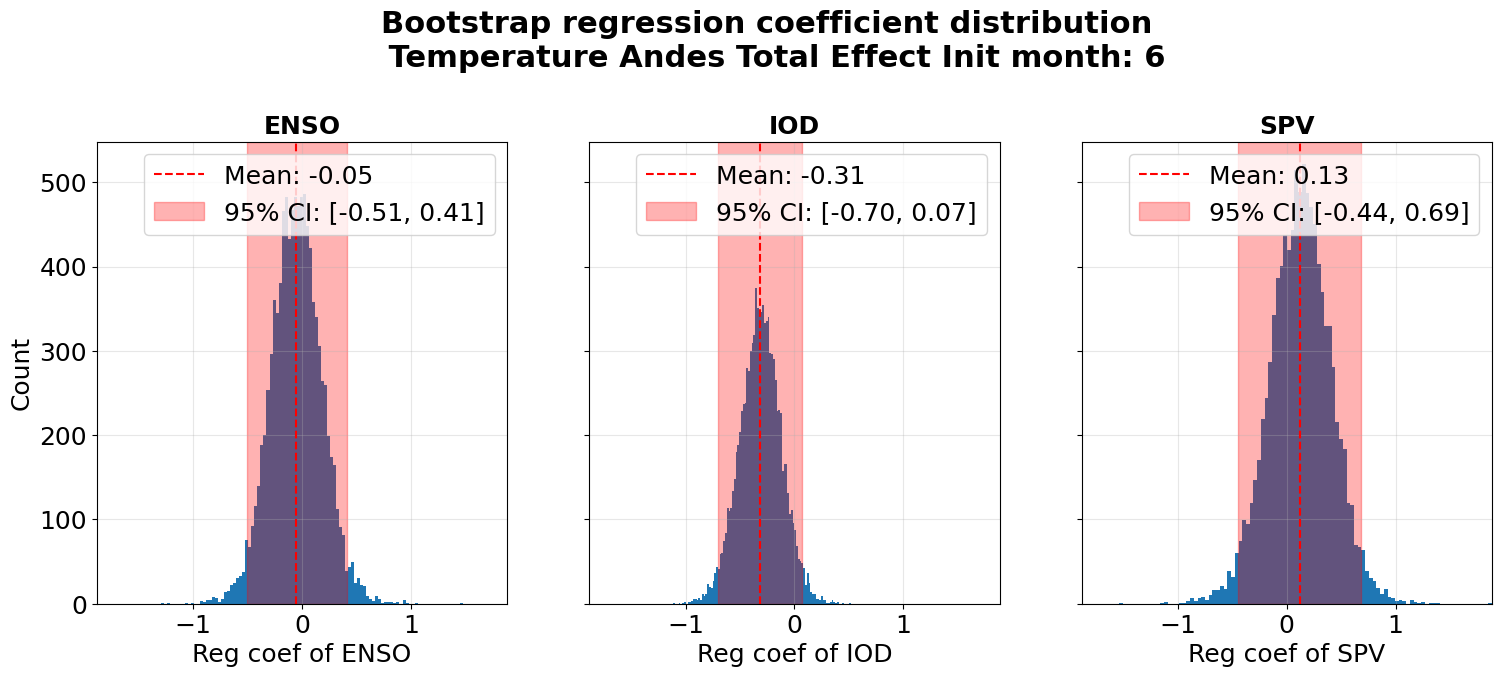

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


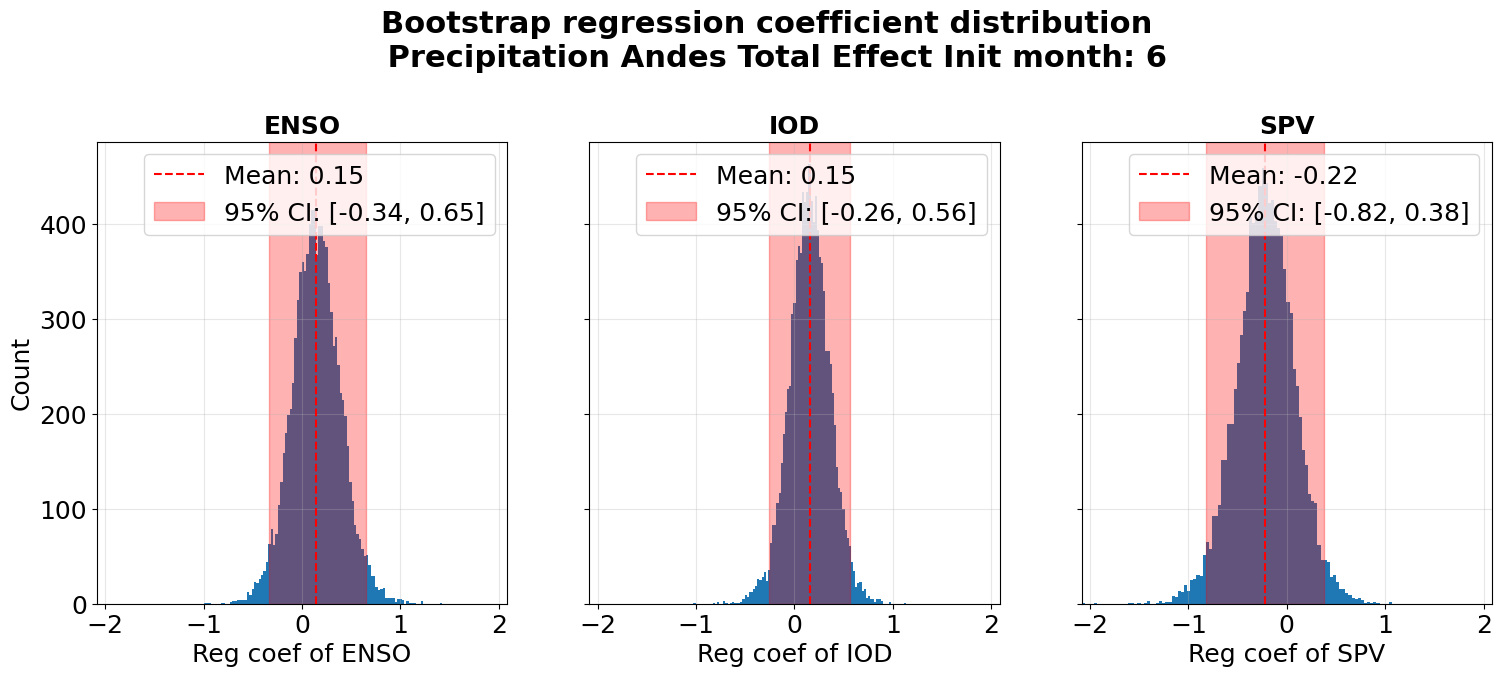

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


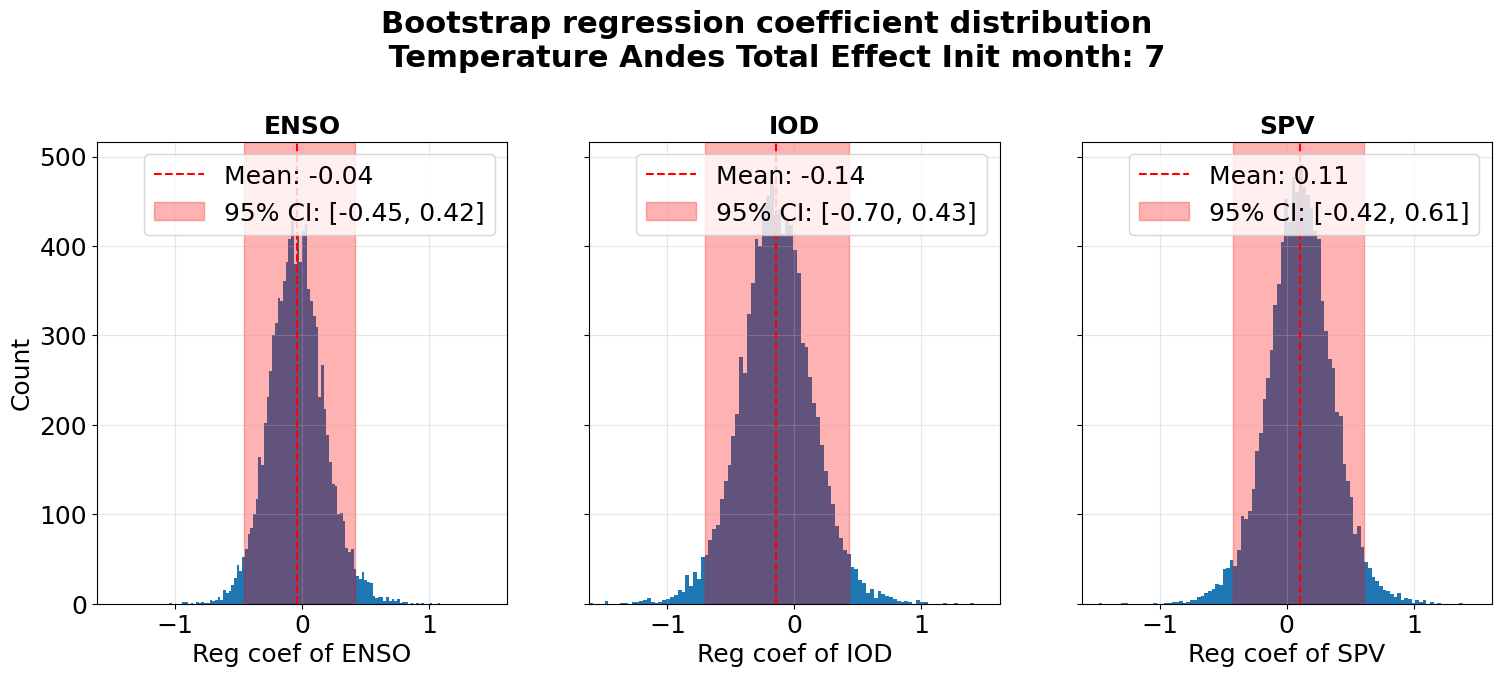

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


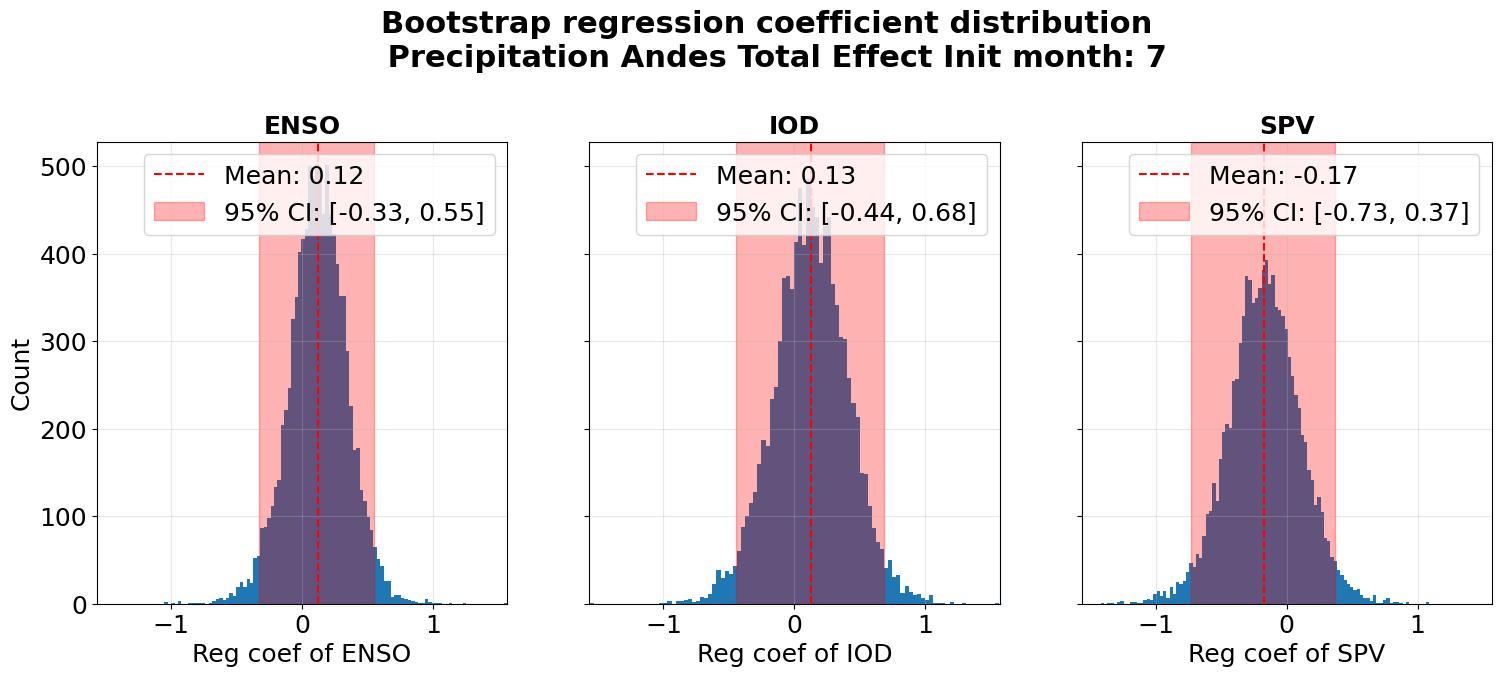

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


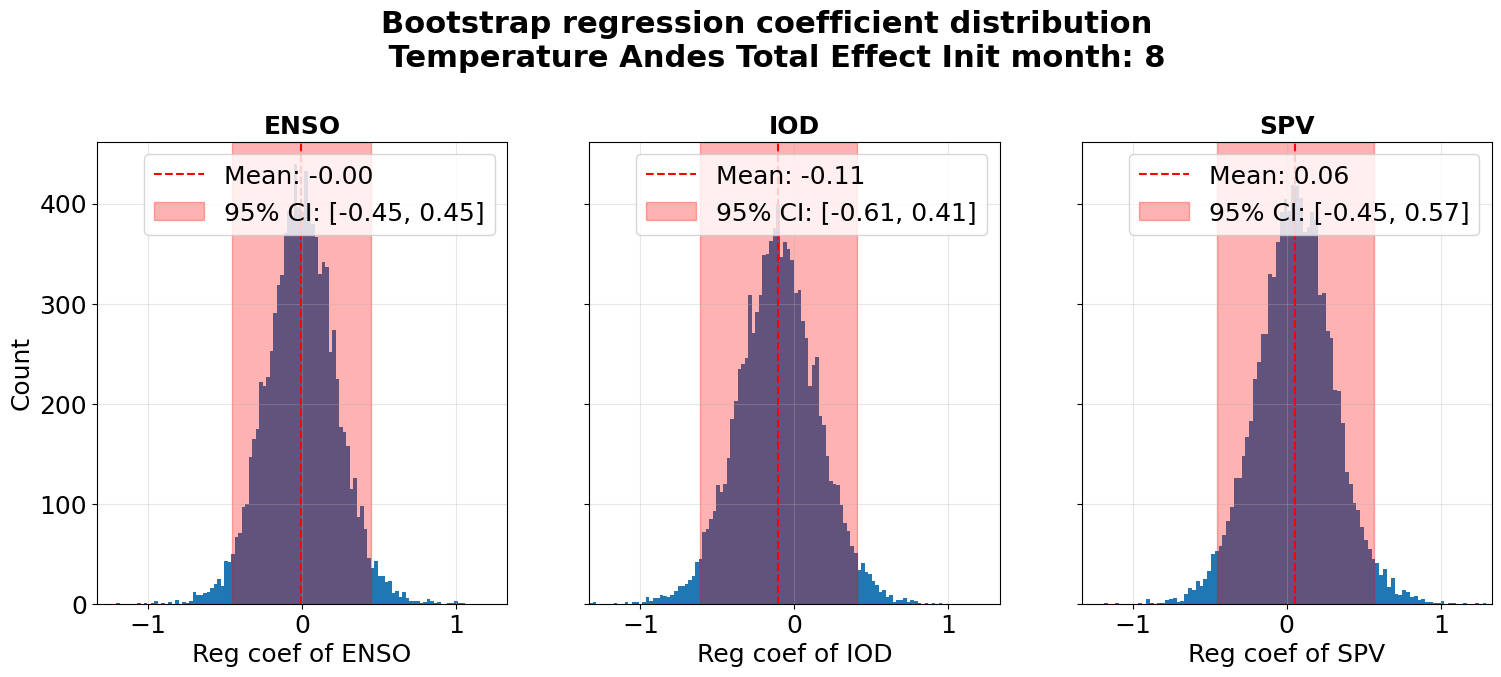

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


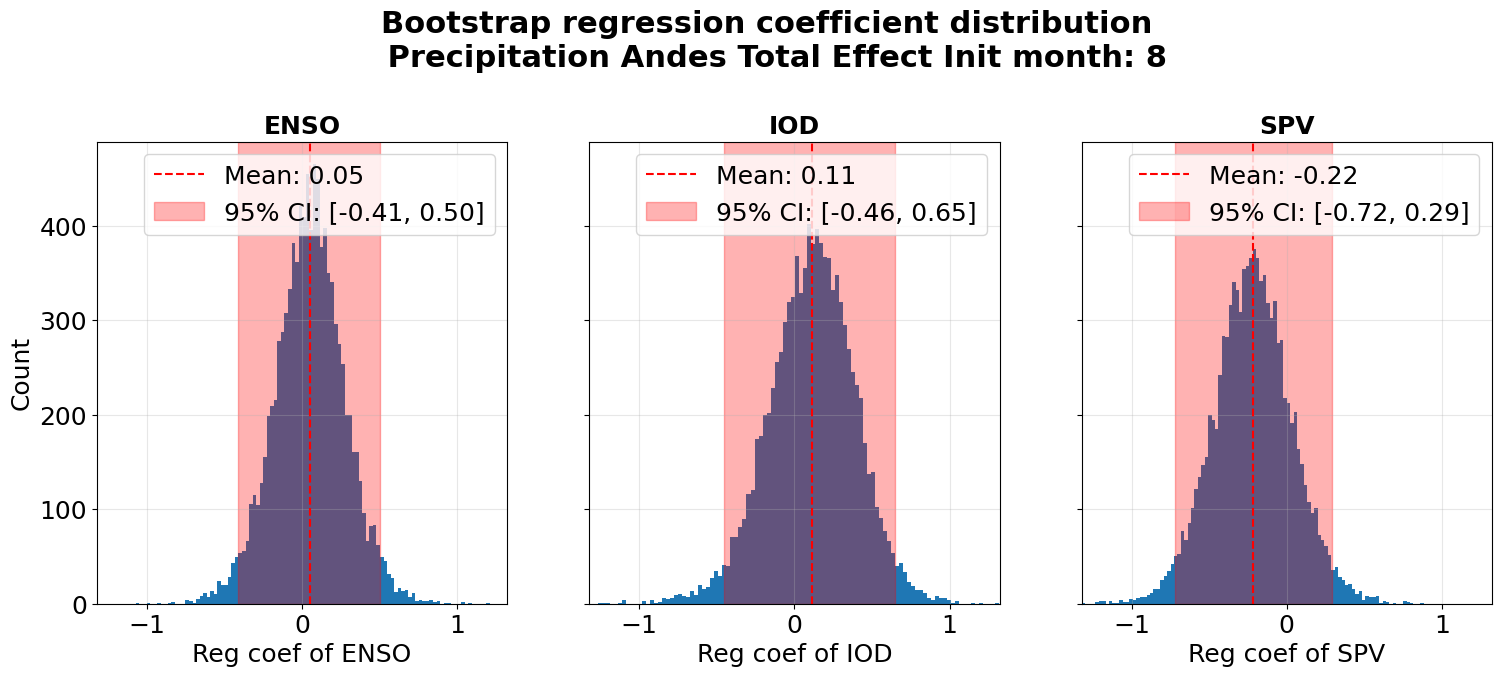

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


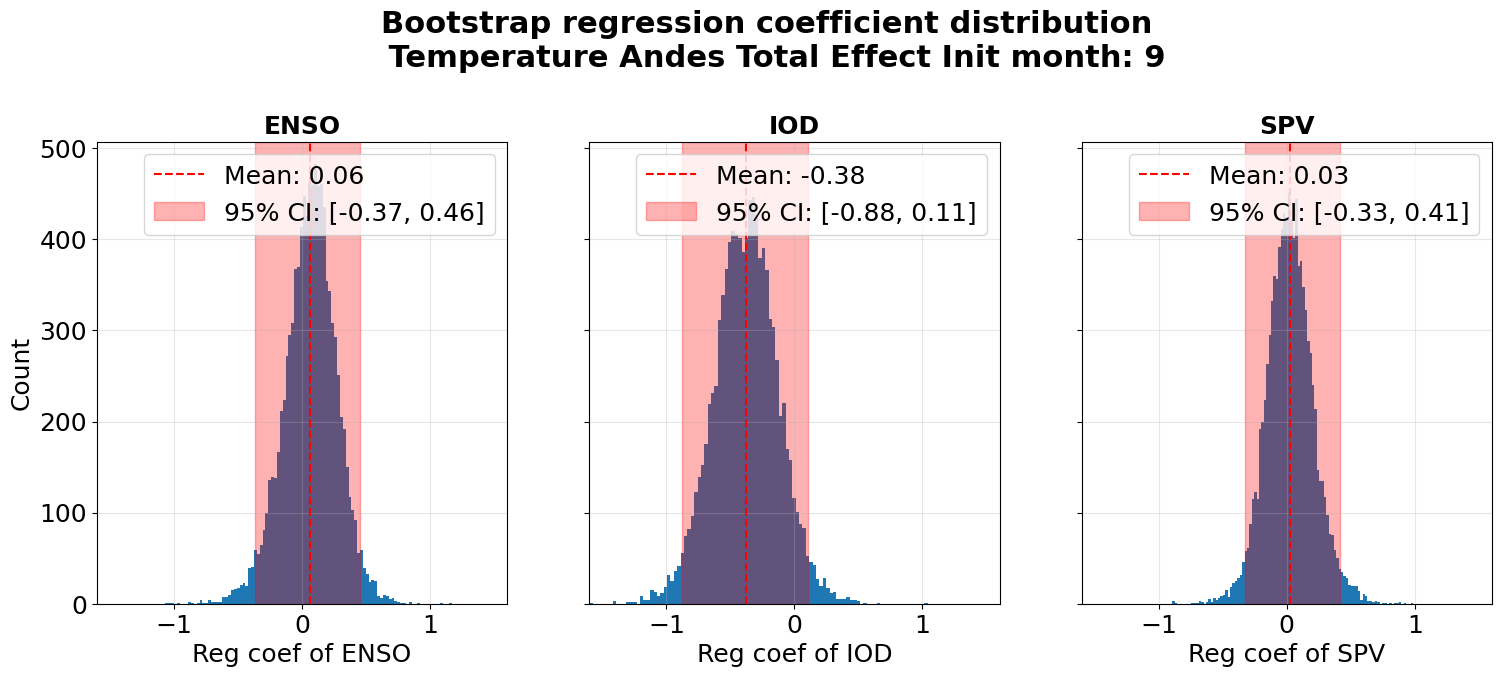

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


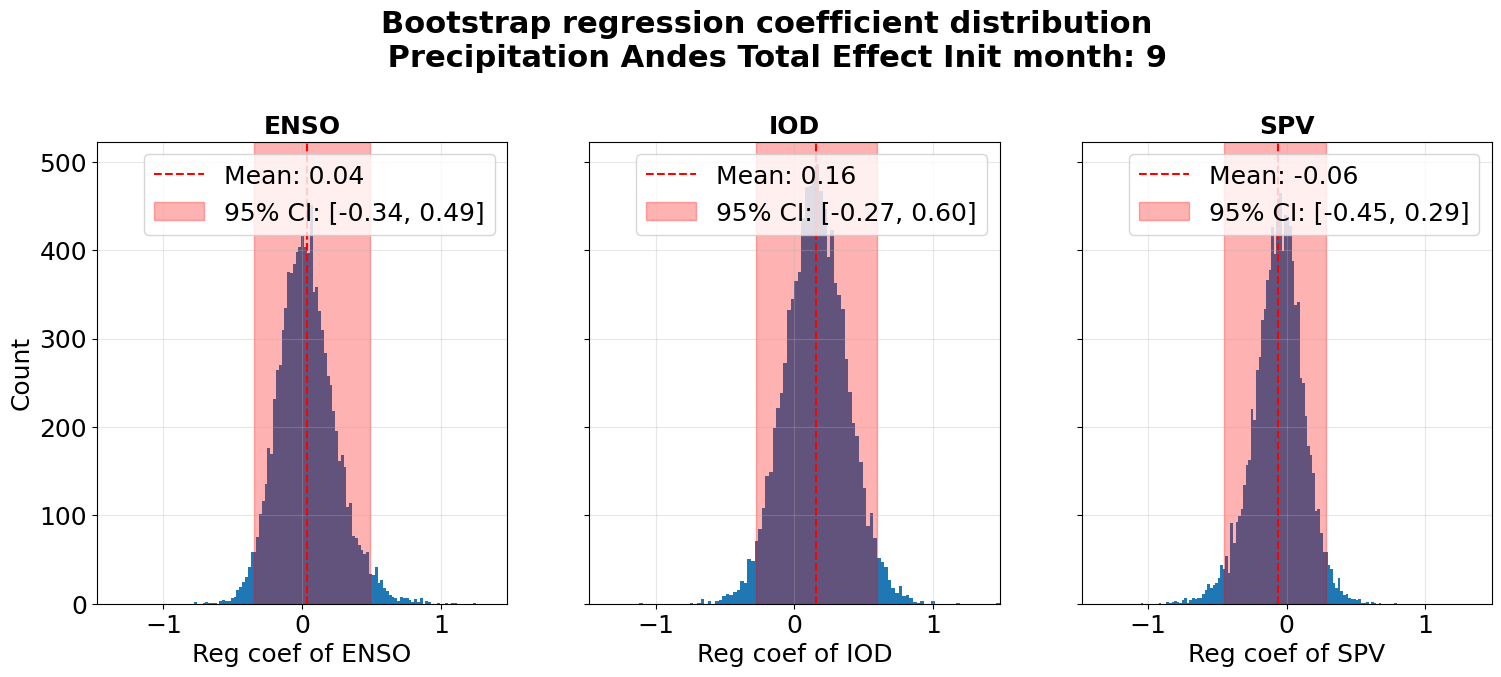

In [50]:
for init in np.unique(target_Andes_SON_xr.init_month.values):
    results_total_T_Andes_SON_300 = bootstrap_regression(
    target_ds=target_Andes_SON_xr.where(target_Andes_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="t2m",
    driver_vars=['ENSO', 'IOD', 'SPV'],
    n_boot=10000,
    add_intercept=False,
    sample_size=200,
    total_eff=True
    )

    plot_bootstrap_coefficients(results_total_T_Andes_SON_300, ['ENSO', 'IOD', 'SPV'],
                                title=f'Bootstrap regression coefficient distribution \n Temperature Andes Total Effect Init month: {init}')


    results_total_Pr_Andes_SON_300 = bootstrap_regression(
        target_ds=target_Andes_SON_xr.where(target_Andes_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="tp",
        driver_vars=['ENSO', 'IOD', 'SPV'],
        n_boot=10000,
        add_intercept=False,
        sample_size=200,
        total_eff=True
        )

    plot_bootstrap_coefficients(results_total_Pr_Andes_SON_300, ['ENSO', 'IOD', 'SPV'],
                                    title=f'Bootstrap regression coefficient distribution \n Precipitation Andes Total Effect Init month: {init}')

ENSO ['ENSO']


IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


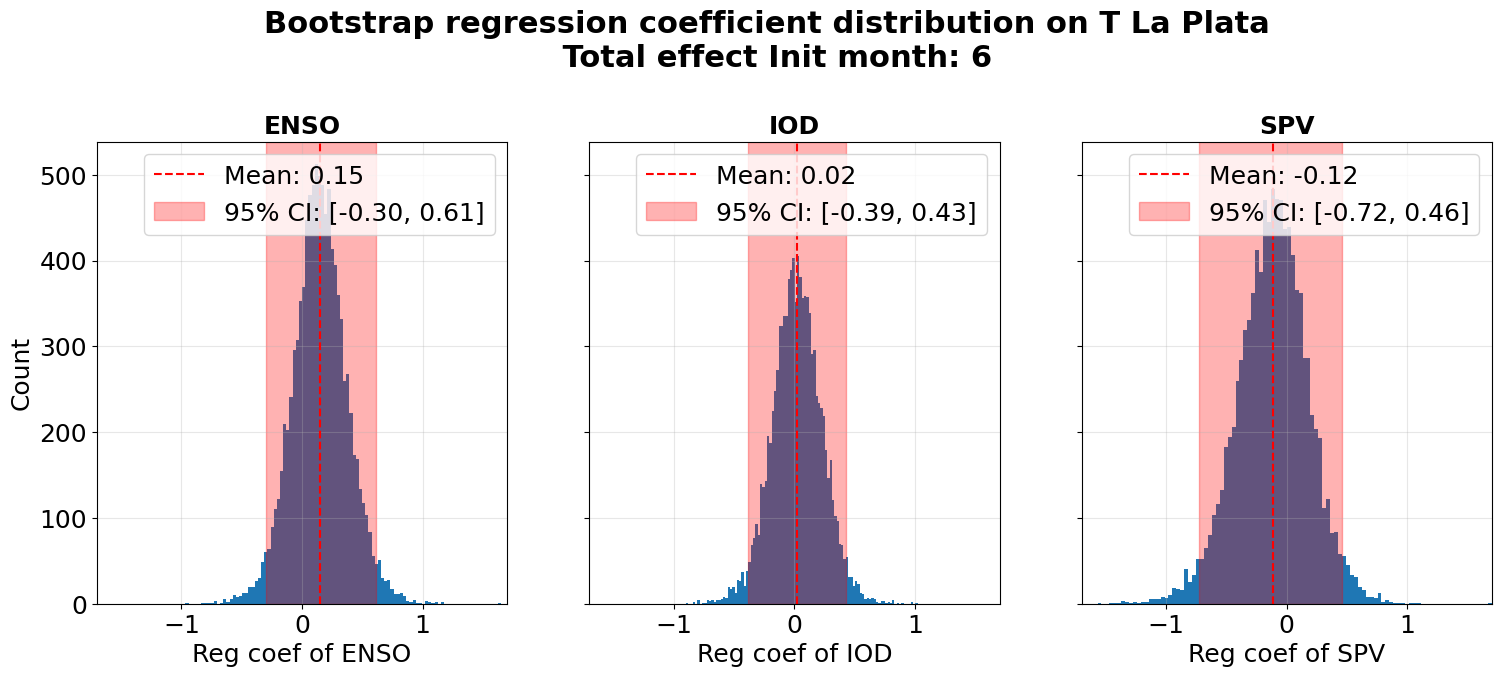

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


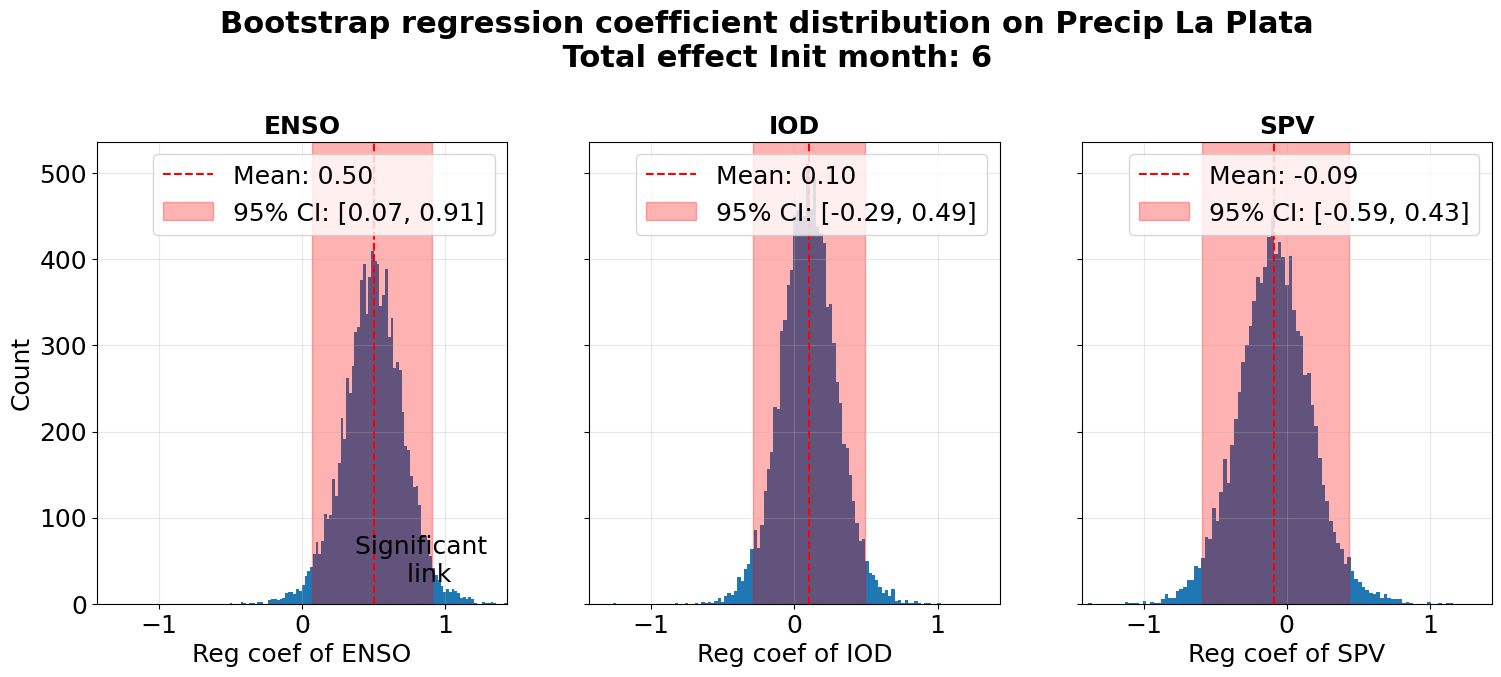

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


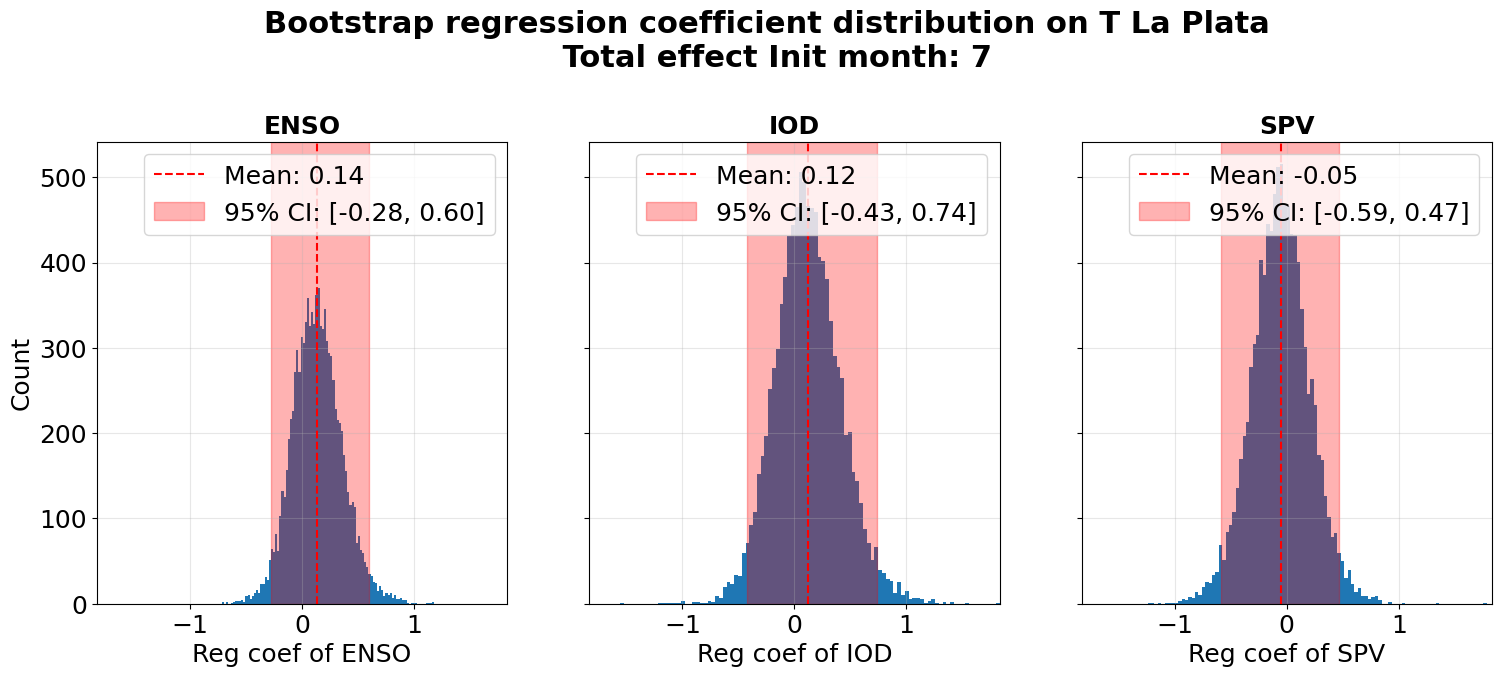

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


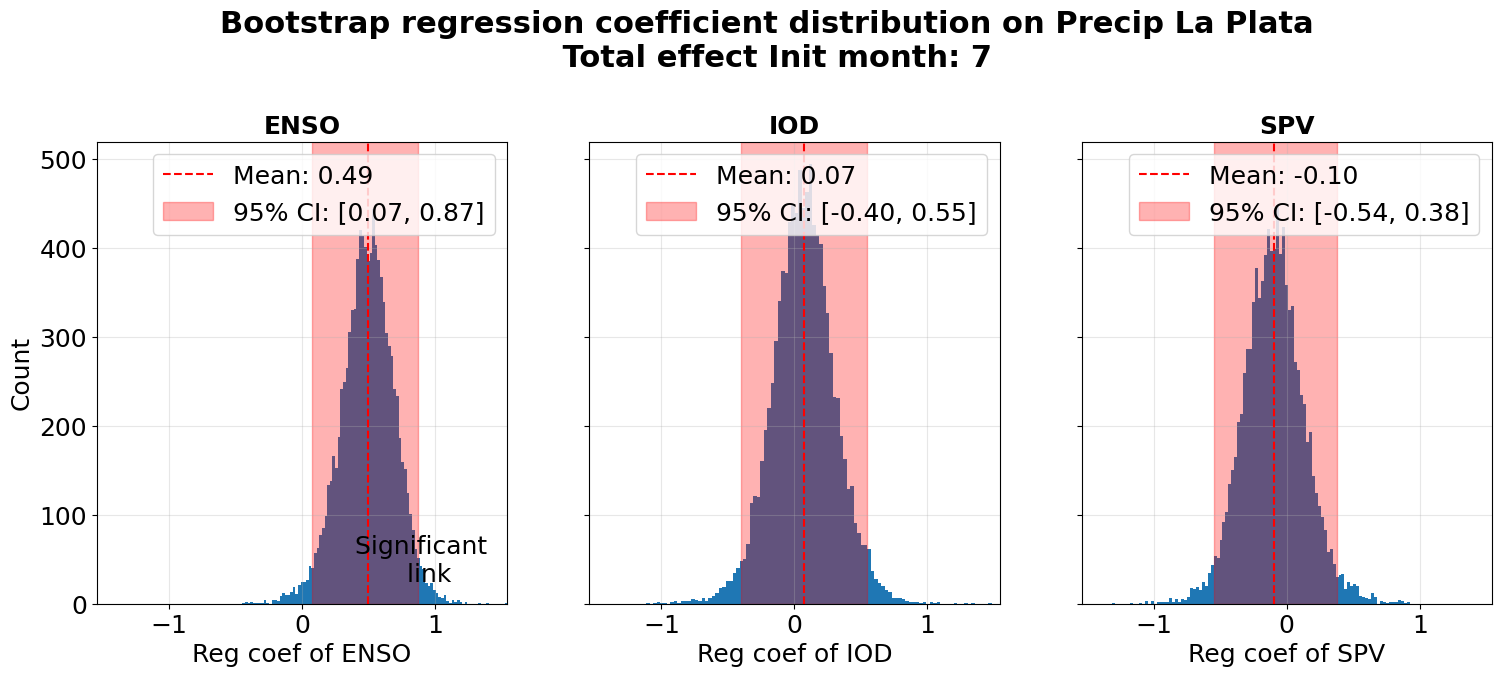

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


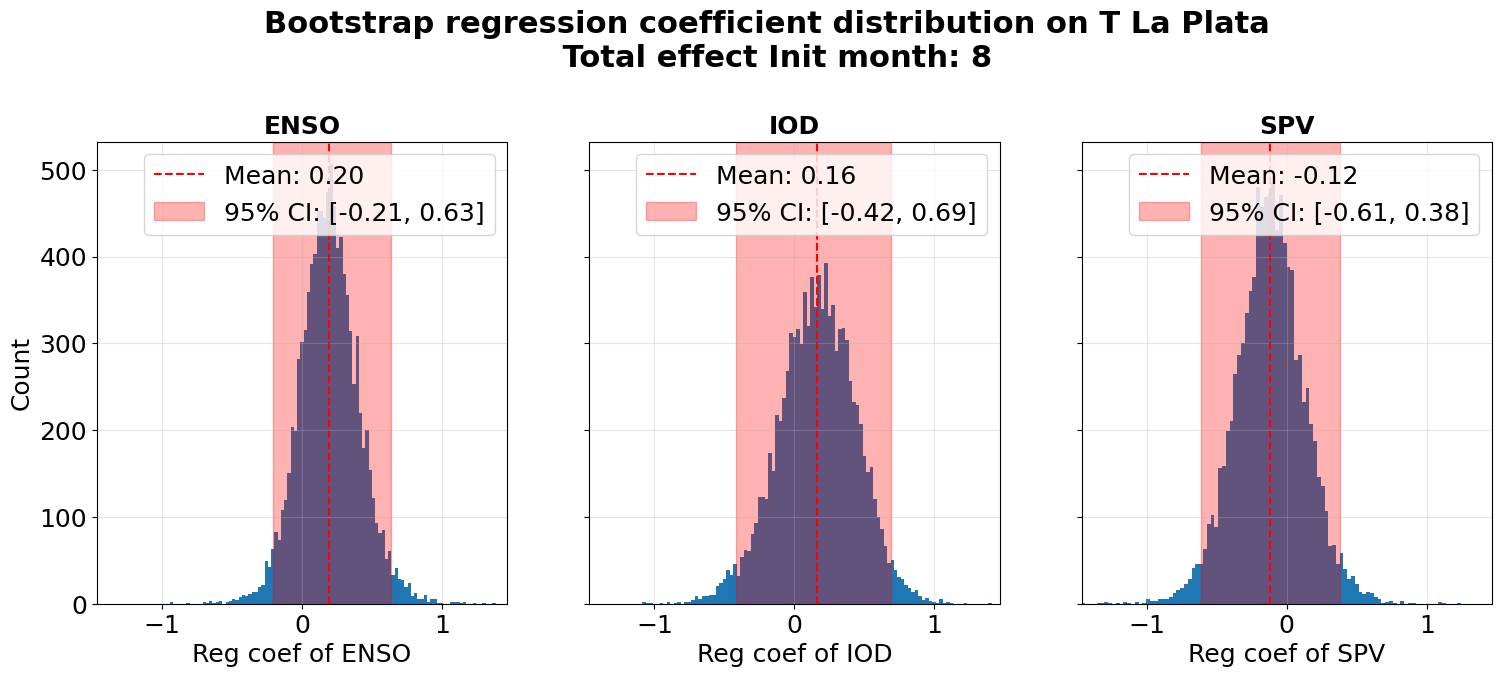

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


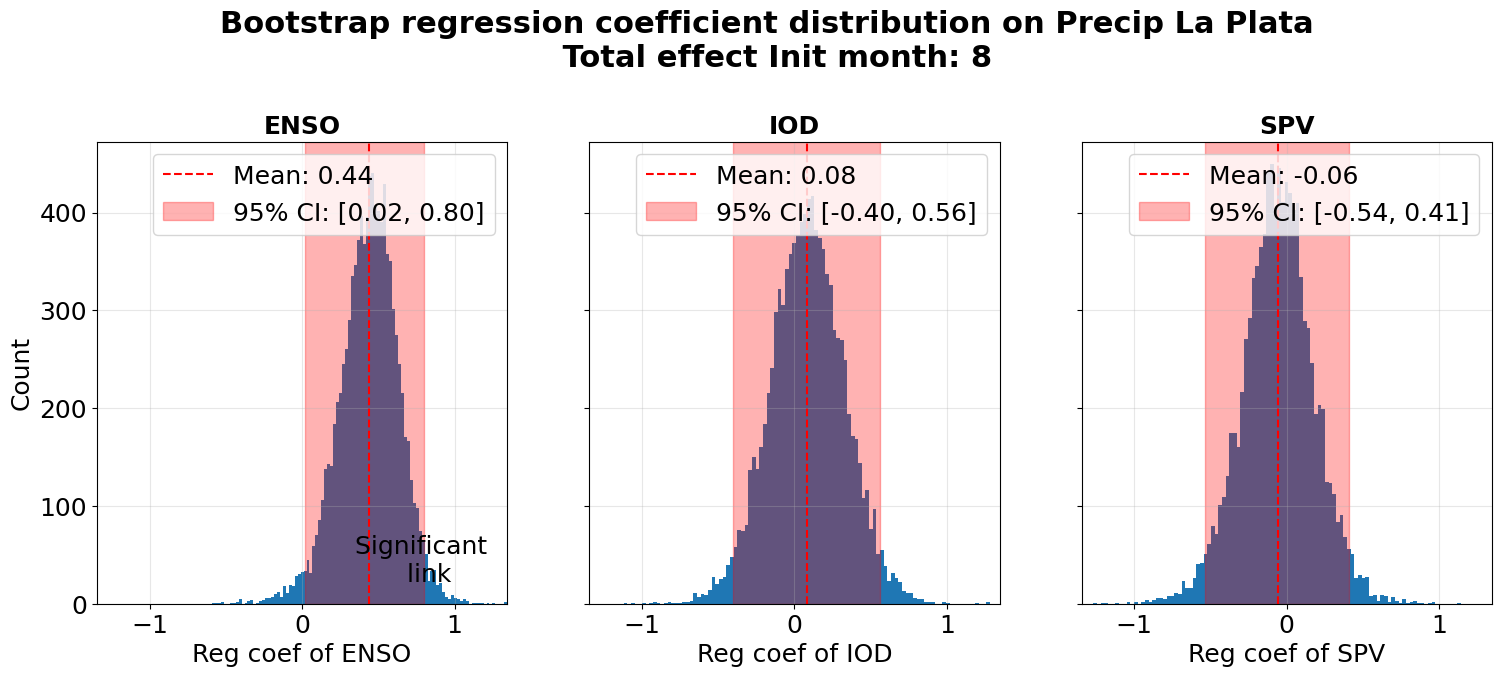

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


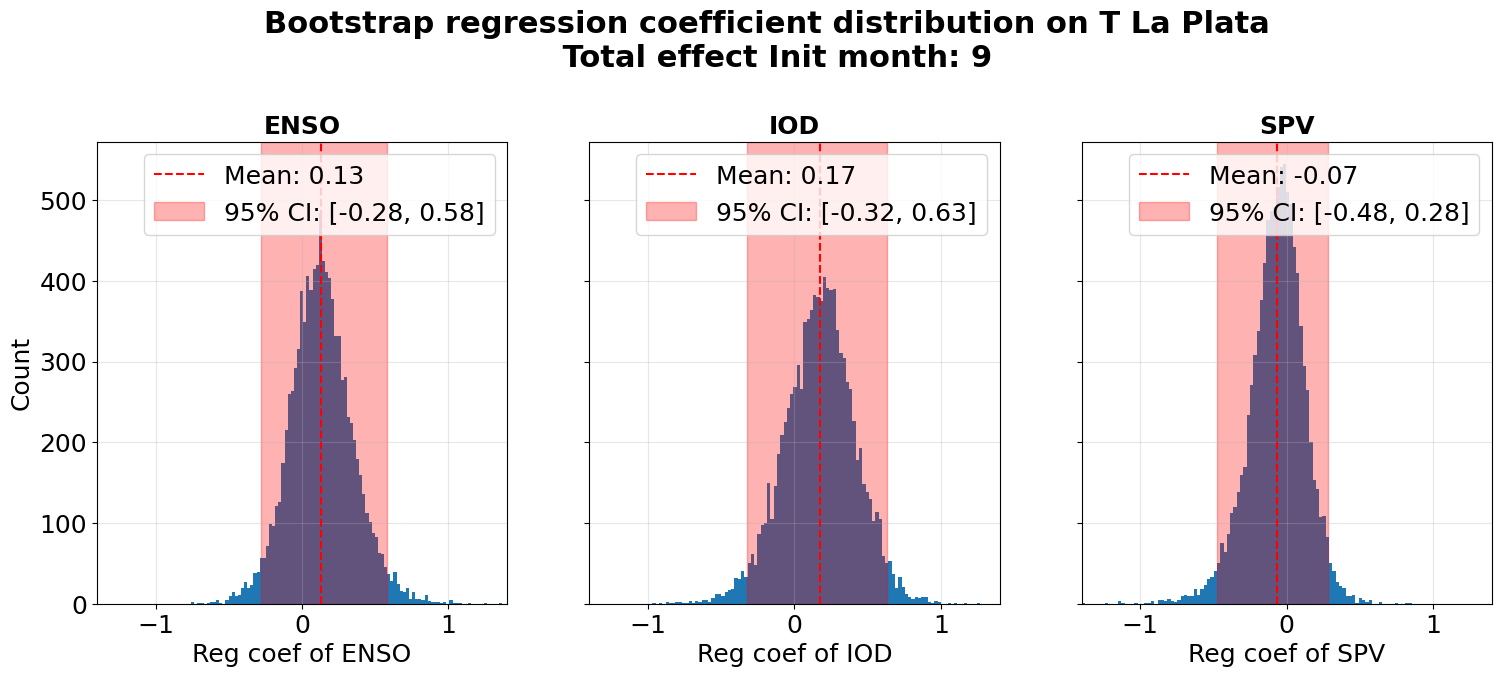

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


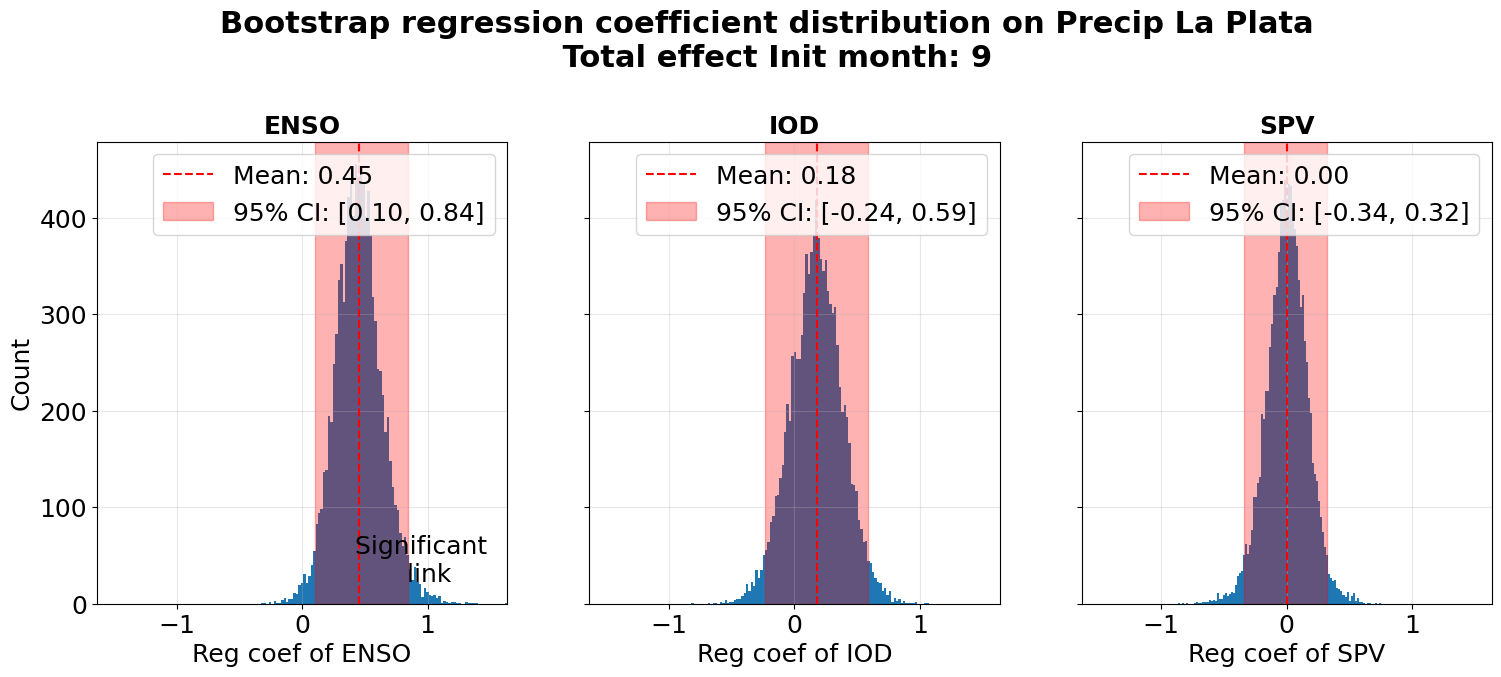

In [51]:
#La Plata temperature
for init in np.unique(target_LP_SON_xr.init_month.values):
    results_total_T_LP_SON_300 = bootstrap_regression(
    target_ds=target_LP_SON_xr.where(target_LP_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="t2m",
    driver_vars=['ENSO', 'IOD', 'SPV'],
    n_boot=10000,
    add_intercept=False,
    sample_size=200,
    total_eff=True
    )

    plot_bootstrap_coefficients(results_total_T_LP_SON_300, ['ENSO', 'IOD', 'SPV'],
                                title=f'Bootstrap regression coefficient distribution on T La Plata \n Total effect Init month: {init}')

    results_total_Pr_LP_SON_300 = bootstrap_regression(
        target_ds=target_LP_SON_xr.where(target_LP_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="tp",
        driver_vars=['ENSO', 'IOD', 'SPV'],
        n_boot=10000,
        add_intercept=False,
        sample_size=200, 
        total_eff=True
        )
    
    plot_bootstrap_coefficients(results_total_Pr_LP_SON_300, ['ENSO', 'IOD', 'SPV'],
                                    title=f'Bootstrap regression coefficient distribution on Precip La Plata \n Total effect Init month: {init}')

# Links between Drivers and Mediators

ENSO ['ENSO']


Valid bootstraps: 10000/10000


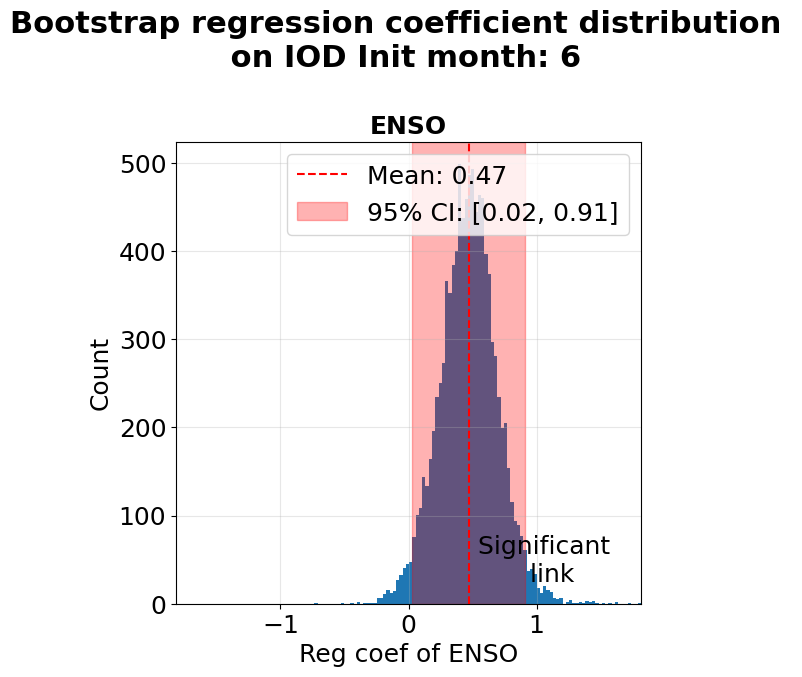

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


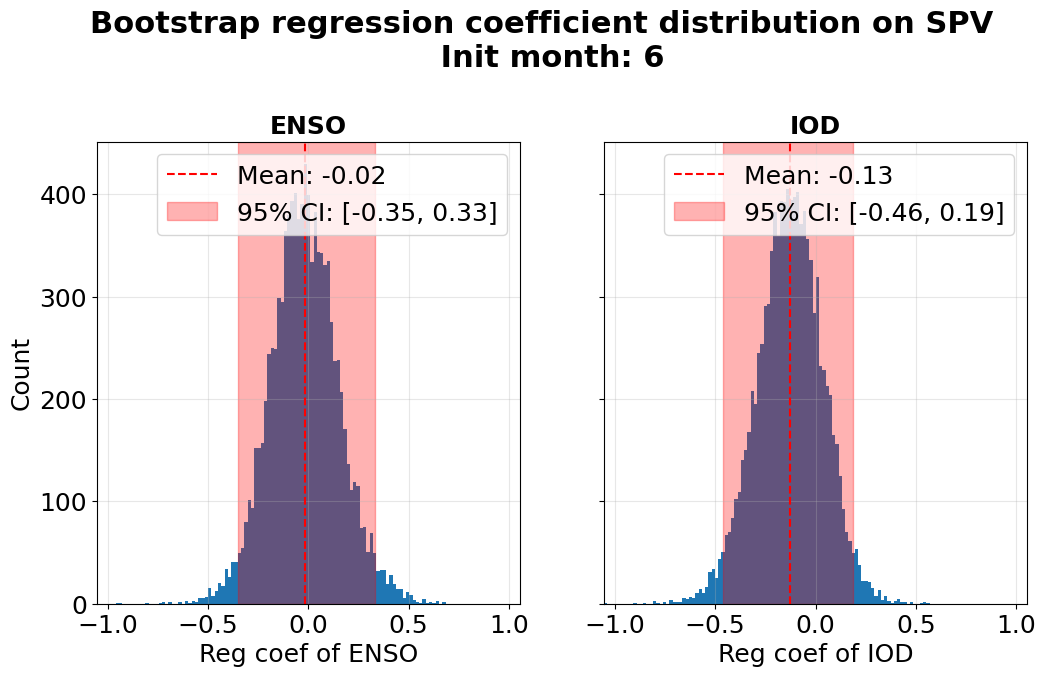

ENSO ['ENSO']
Valid bootstraps: 10000/10000


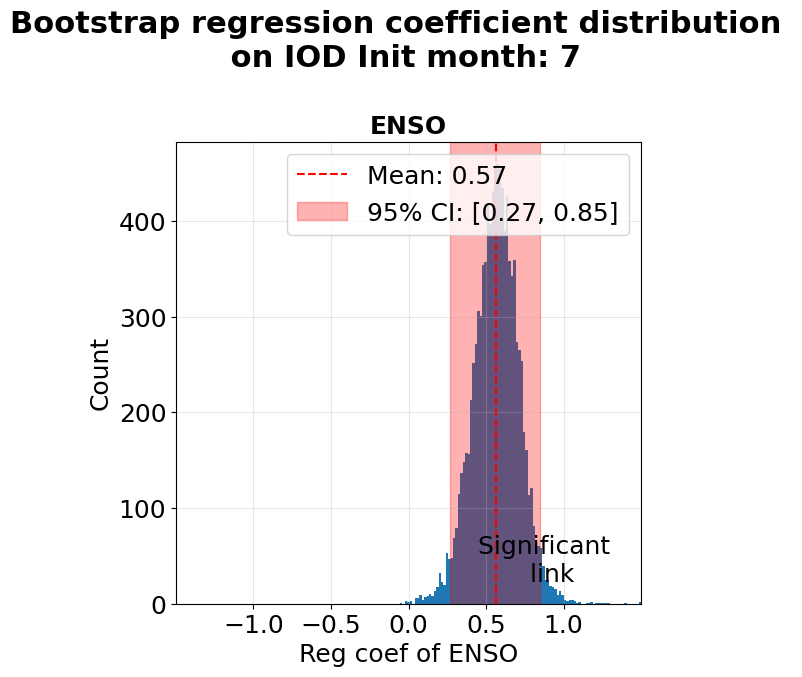

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


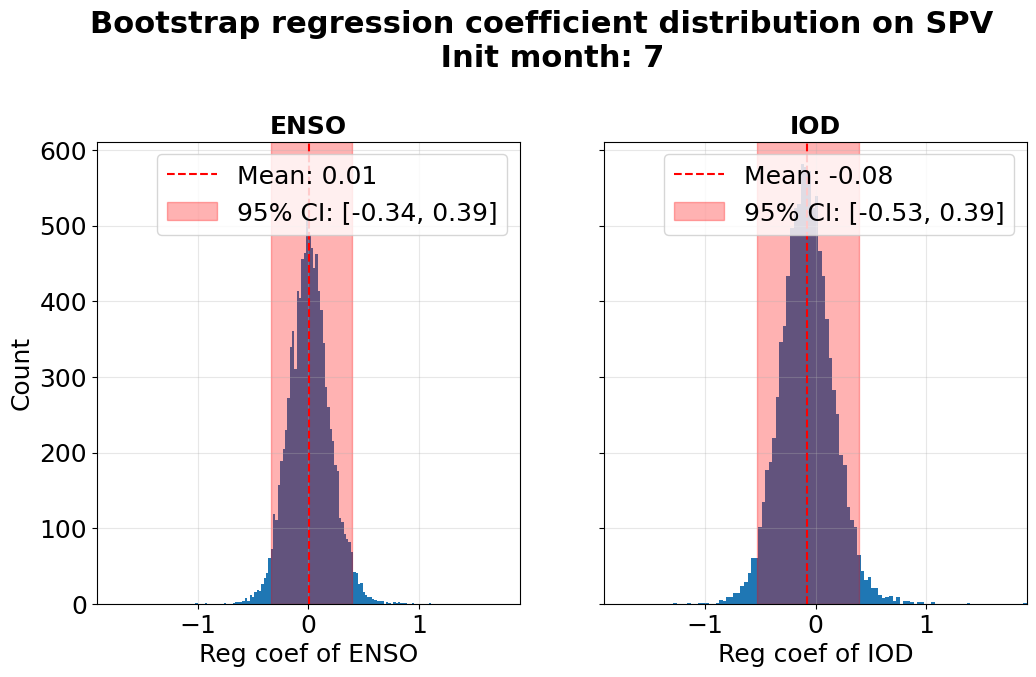

ENSO ['ENSO']
Valid bootstraps: 10000/10000


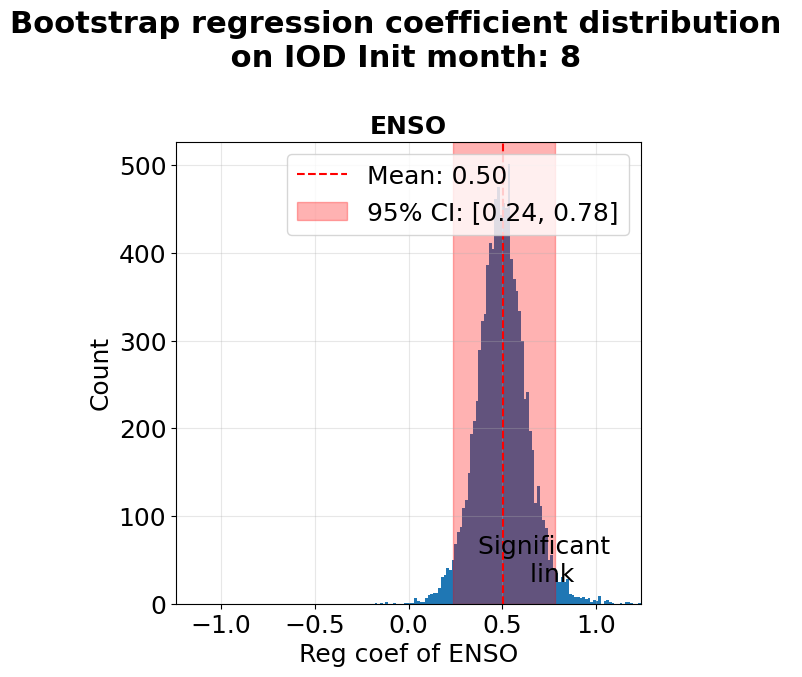

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


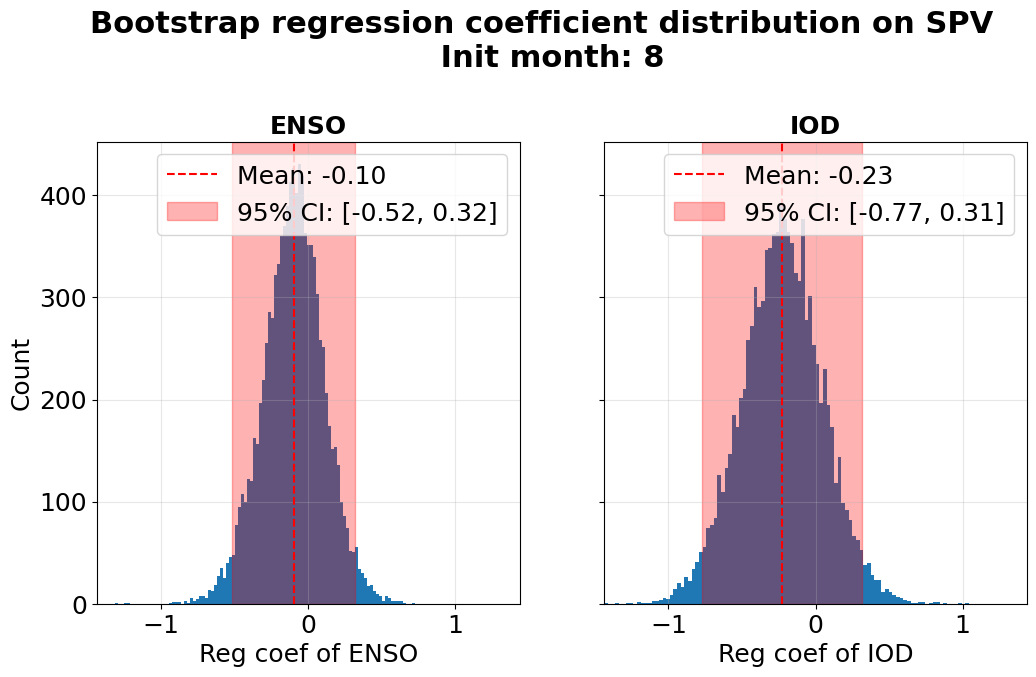

ENSO ['ENSO']
Valid bootstraps: 10000/10000


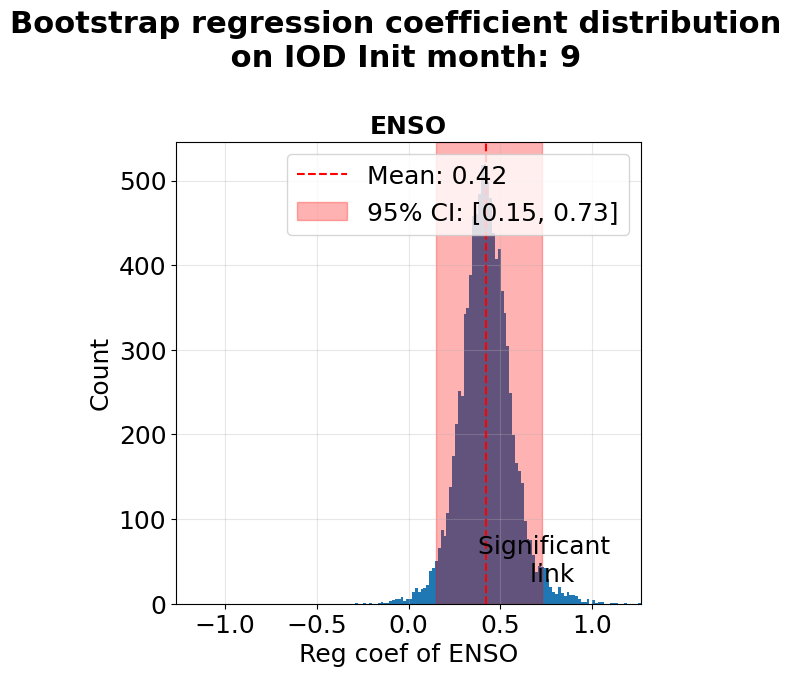

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


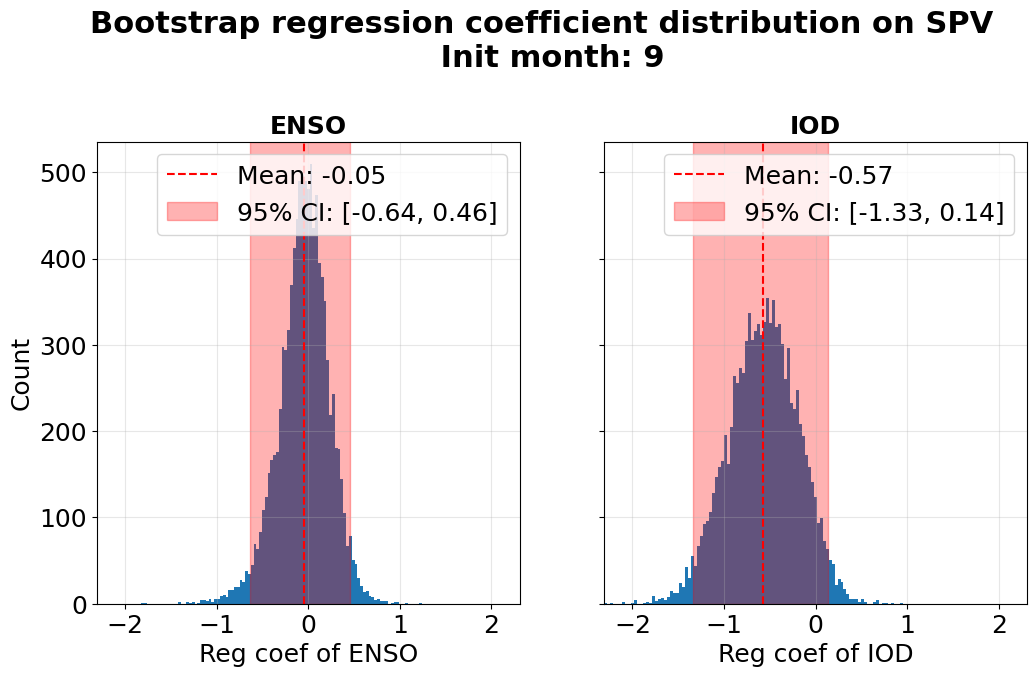

In [52]:

for init in np.unique(drivers_SON_xr.init_month.values):
    #ENSO-->IOD
    results_total_IOD_SON_300 = bootstrap_regression(
    target_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="IOD",
    driver_vars=['ENSO'],
    n_boot=10000,
    add_intercept=False,
    sample_size=200
    )

    plot_bootstrap_coefficients(results_total_IOD_SON_300, ['ENSO'],
                                title=f'Bootstrap regression coefficient distribution \n on IOD Init month: {init}')

    #ENSO/IOD-->SPV
    results_total_SPV_SON_300 = bootstrap_regression(
        target_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="SPV",
        driver_vars=['ENSO', 'IOD'],
        n_boot=10000,
        add_intercept=False,
        sample_size=200, 
        total_eff=True
        )
    
    plot_bootstrap_coefficients(results_total_SPV_SON_300, ['ENSO', 'IOD'],
                                    title=f'Bootstrap regression coefficient distribution on SPV \n Init month: {init}')

ENSO ['ENSO', 'IOD', 'SPV']


IOD ['IOD', 'ENSO', 'SPV']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


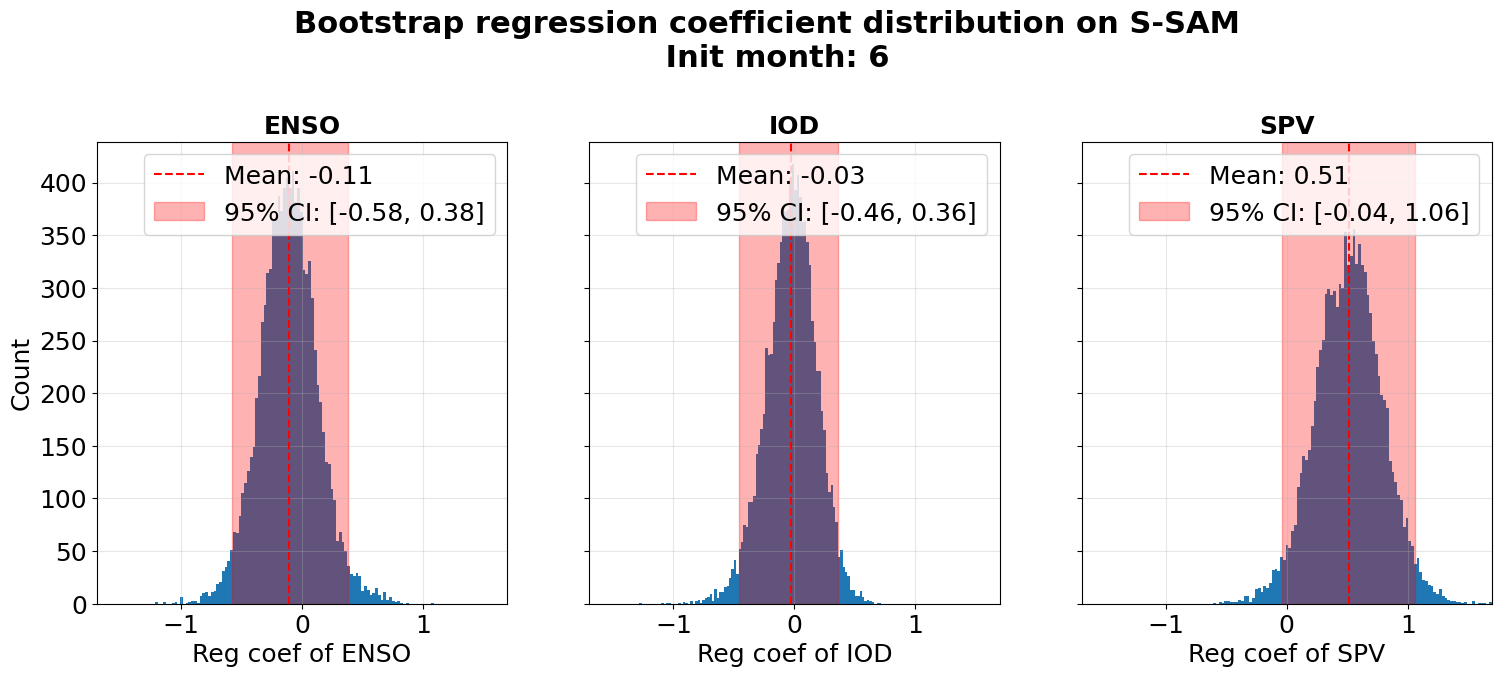

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


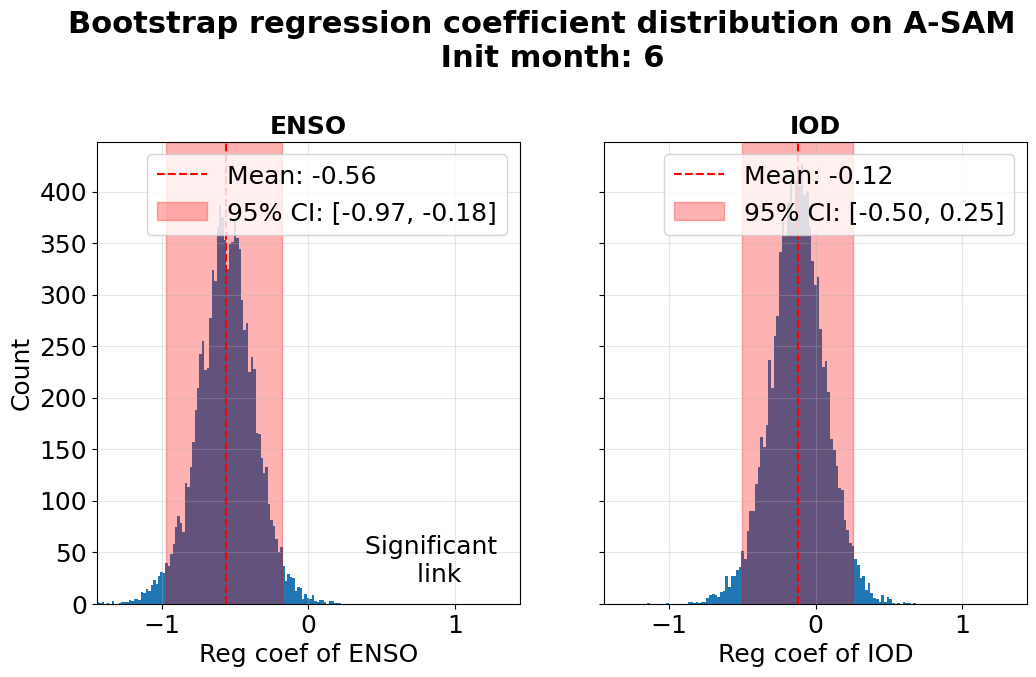

ENSO ['ENSO', 'IOD', 'SPV']
IOD ['IOD', 'ENSO', 'SPV']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


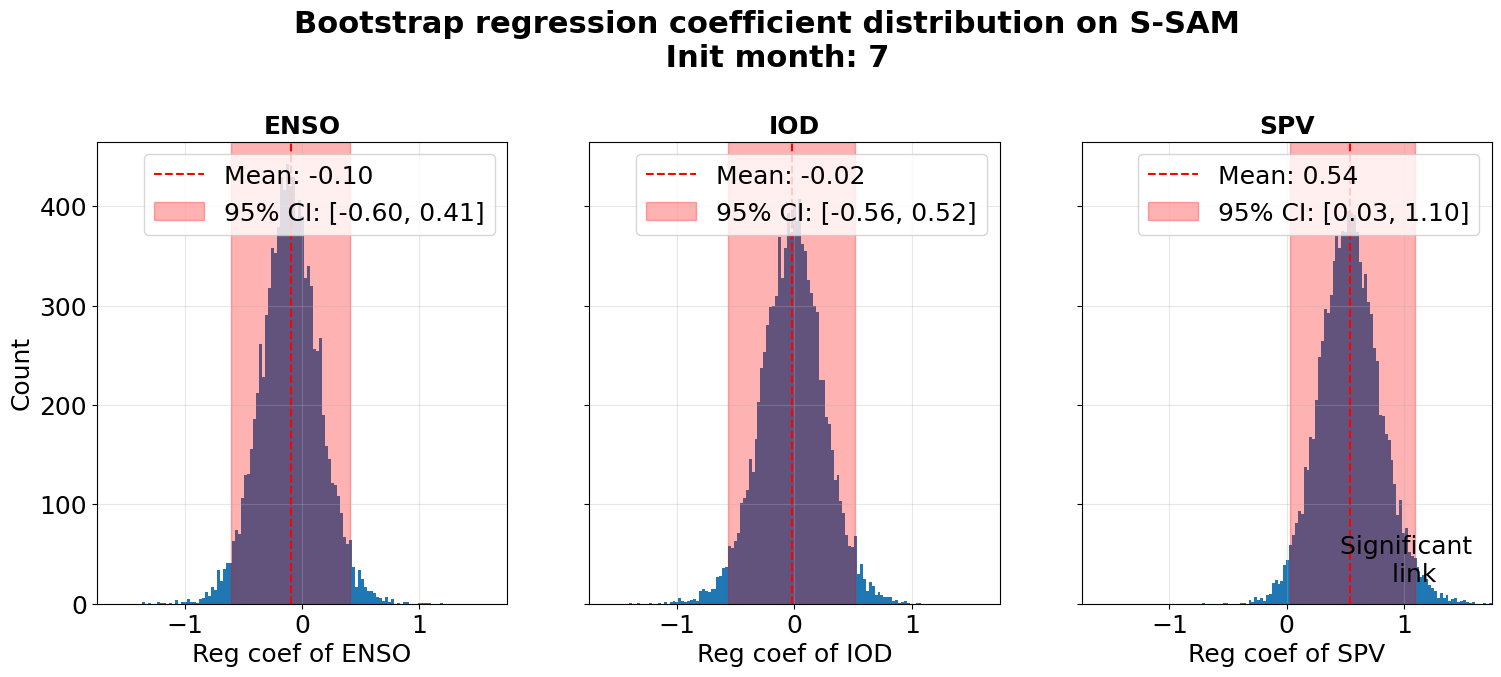

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


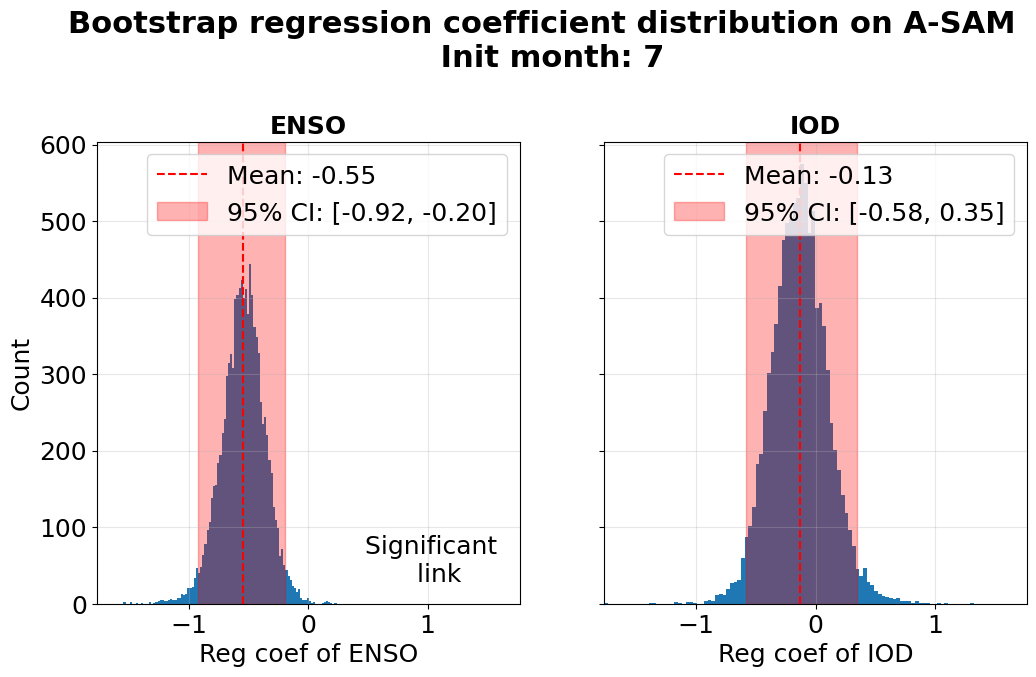

ENSO ['ENSO', 'IOD', 'SPV']
IOD ['IOD', 'ENSO', 'SPV']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


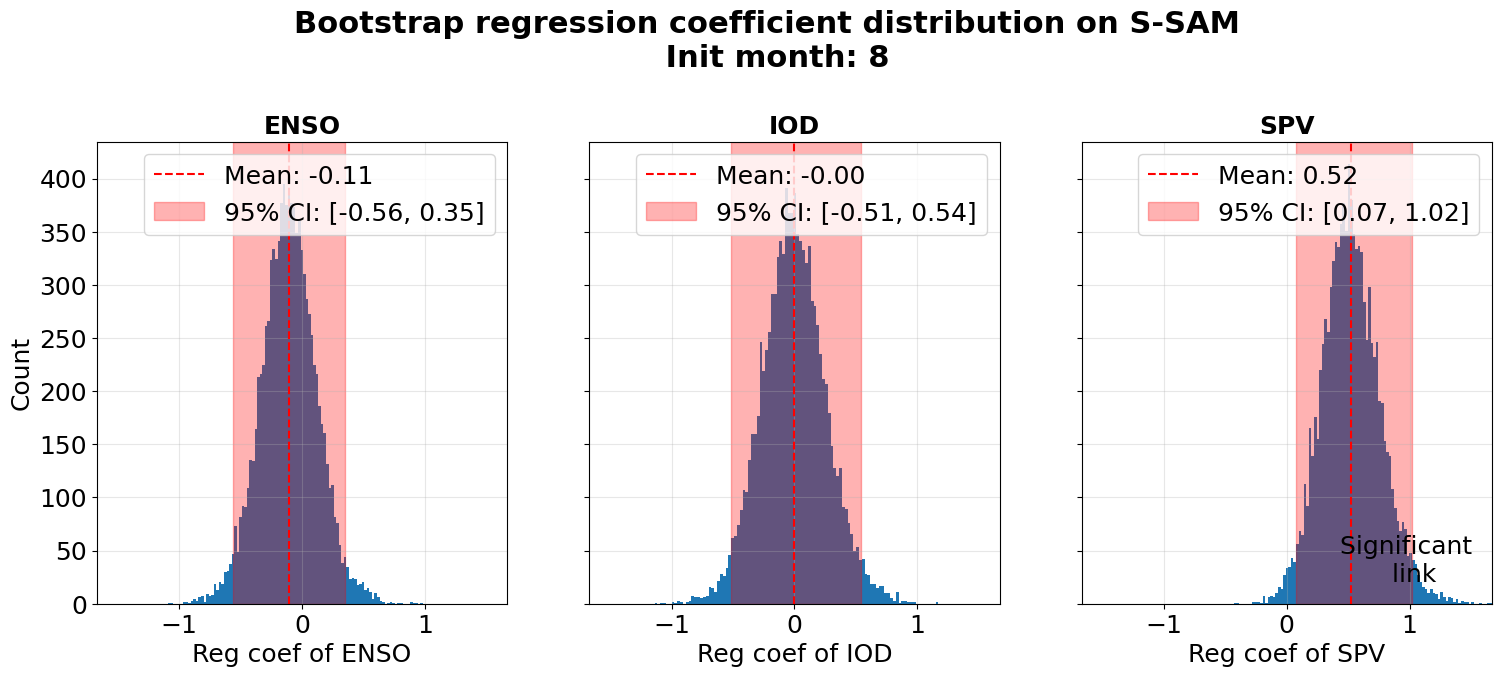

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


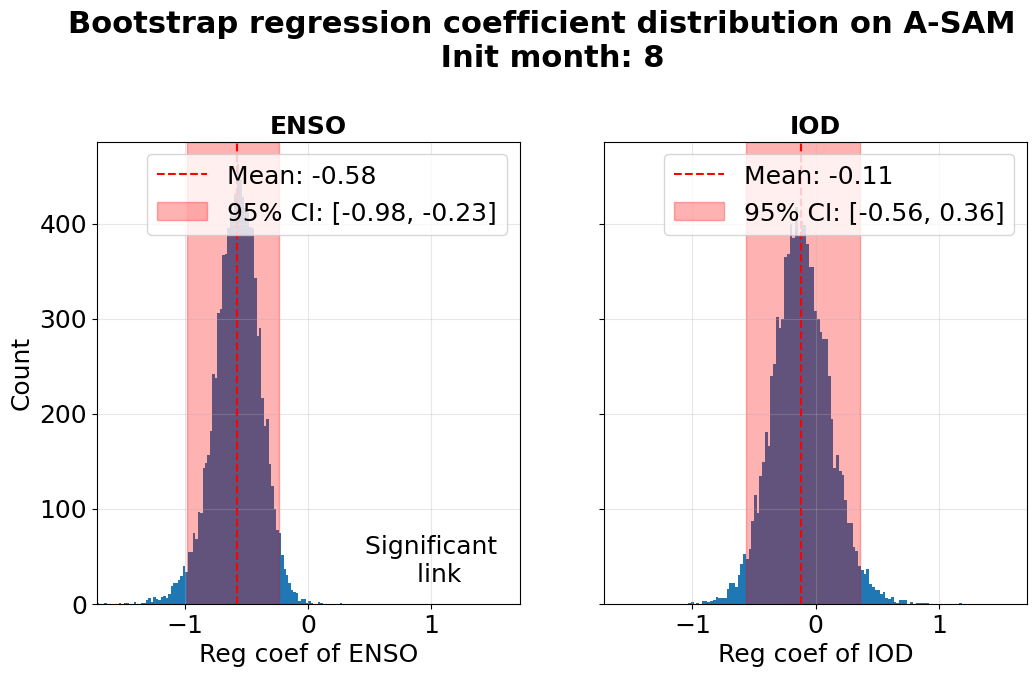

ENSO ['ENSO', 'IOD', 'SPV']
IOD ['IOD', 'ENSO', 'SPV']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


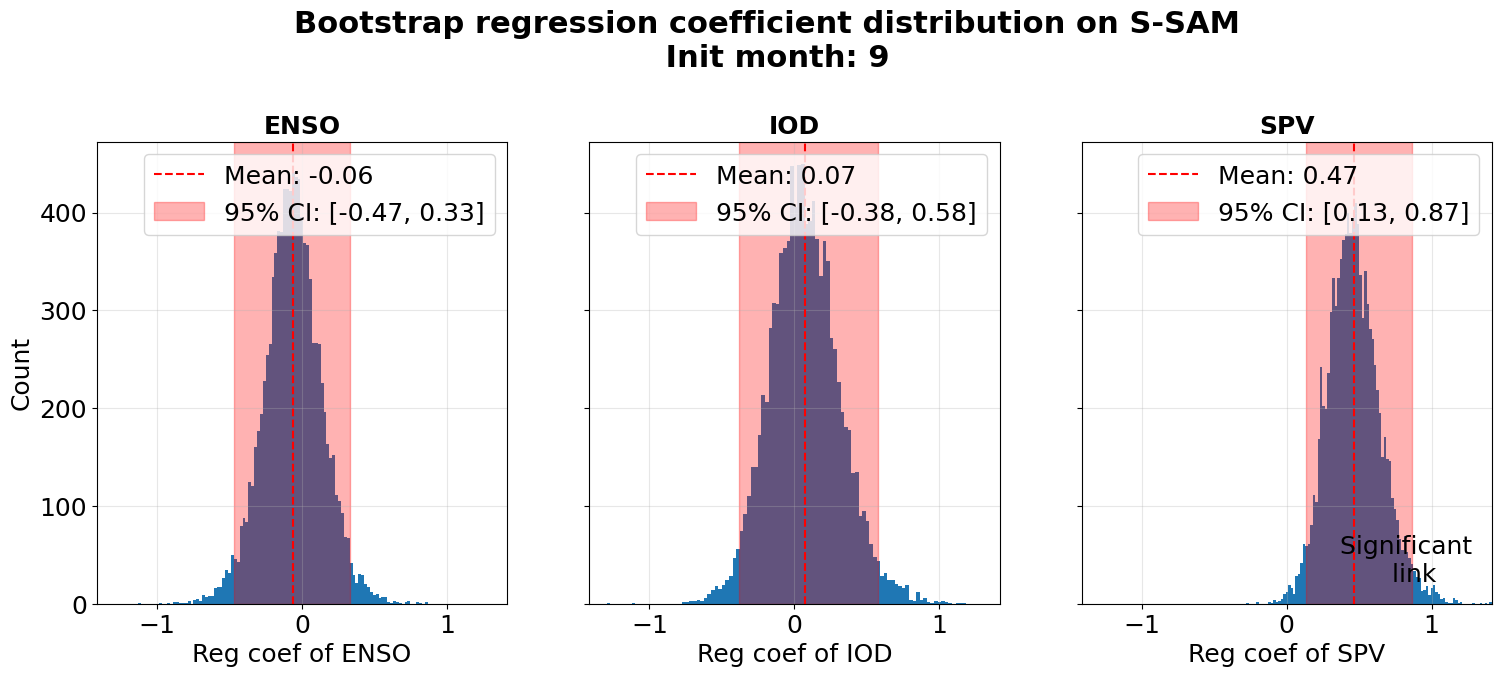

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000


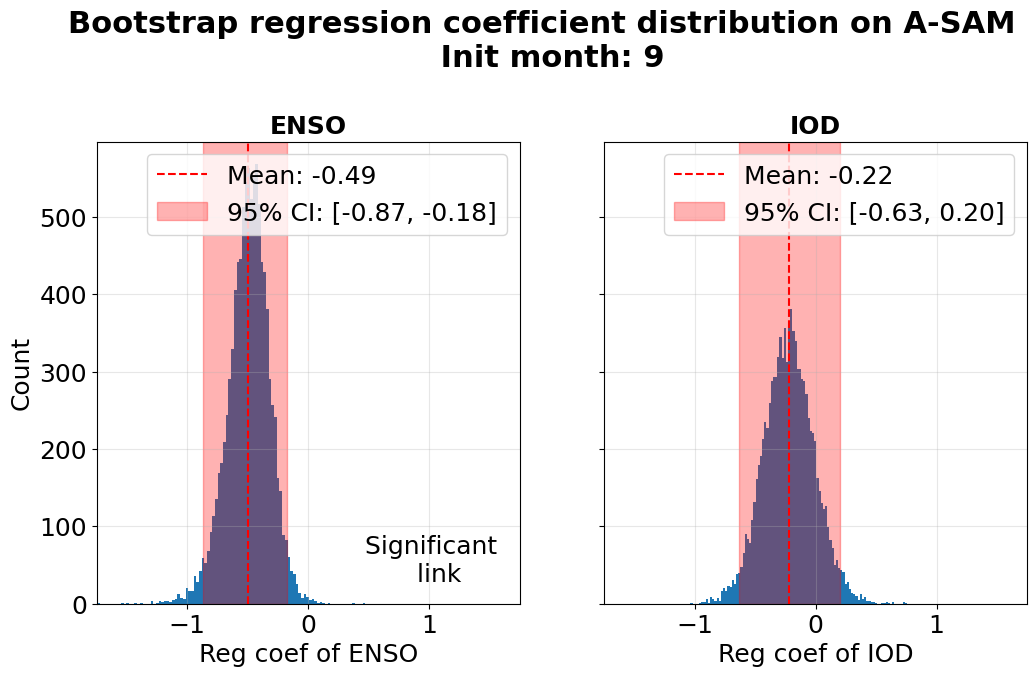

In [53]:

for init in np.unique(drivers_SON_xr.init_month.values):
    #ENSO/IOD/SPV-->S_SAM
    results_total_sym_SAM_SON_300 = bootstrap_regression(
    target_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
    target_var="S_SAM",
    driver_vars=['ENSO', 'IOD', 'SPV'],
    n_boot=10000,
    add_intercept=False,
    sample_size=200
    )

    plot_bootstrap_coefficients(results_total_sym_SAM_SON_300, ['ENSO', 'IOD', 'SPV'],
                                title=f'Bootstrap regression coefficient distribution on S-SAM \n Init month: {init}')

    #ENSO/IOD-->A_SAM
    results_total_asym_SAM_SON_300 = bootstrap_regression(
        target_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        driver_ds=drivers_SON_xr.where(drivers_SON_xr.init_month==init, drop=True),
        target_var="A_SAM",
        driver_vars=['ENSO', 'IOD'],
        n_boot=10000,
        add_intercept=False,
        sample_size=200, 
        total_eff=True
        )
    
    plot_bootstrap_coefficients(results_total_asym_SAM_SON_300, ['ENSO', 'IOD'],
                                    title=f'Bootstrap regression coefficient distribution on A-SAM \n Init month: {init}')

Compute all Links when mixing everything

ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']


IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
IOD ['IOD', 'ENSO', 'SPV', 'S_SAM', 'A_SAM']
SPV ['SPV', 'ENSO', 'IOD', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOD', 'SPV']
A_SAM ['A_SAM', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


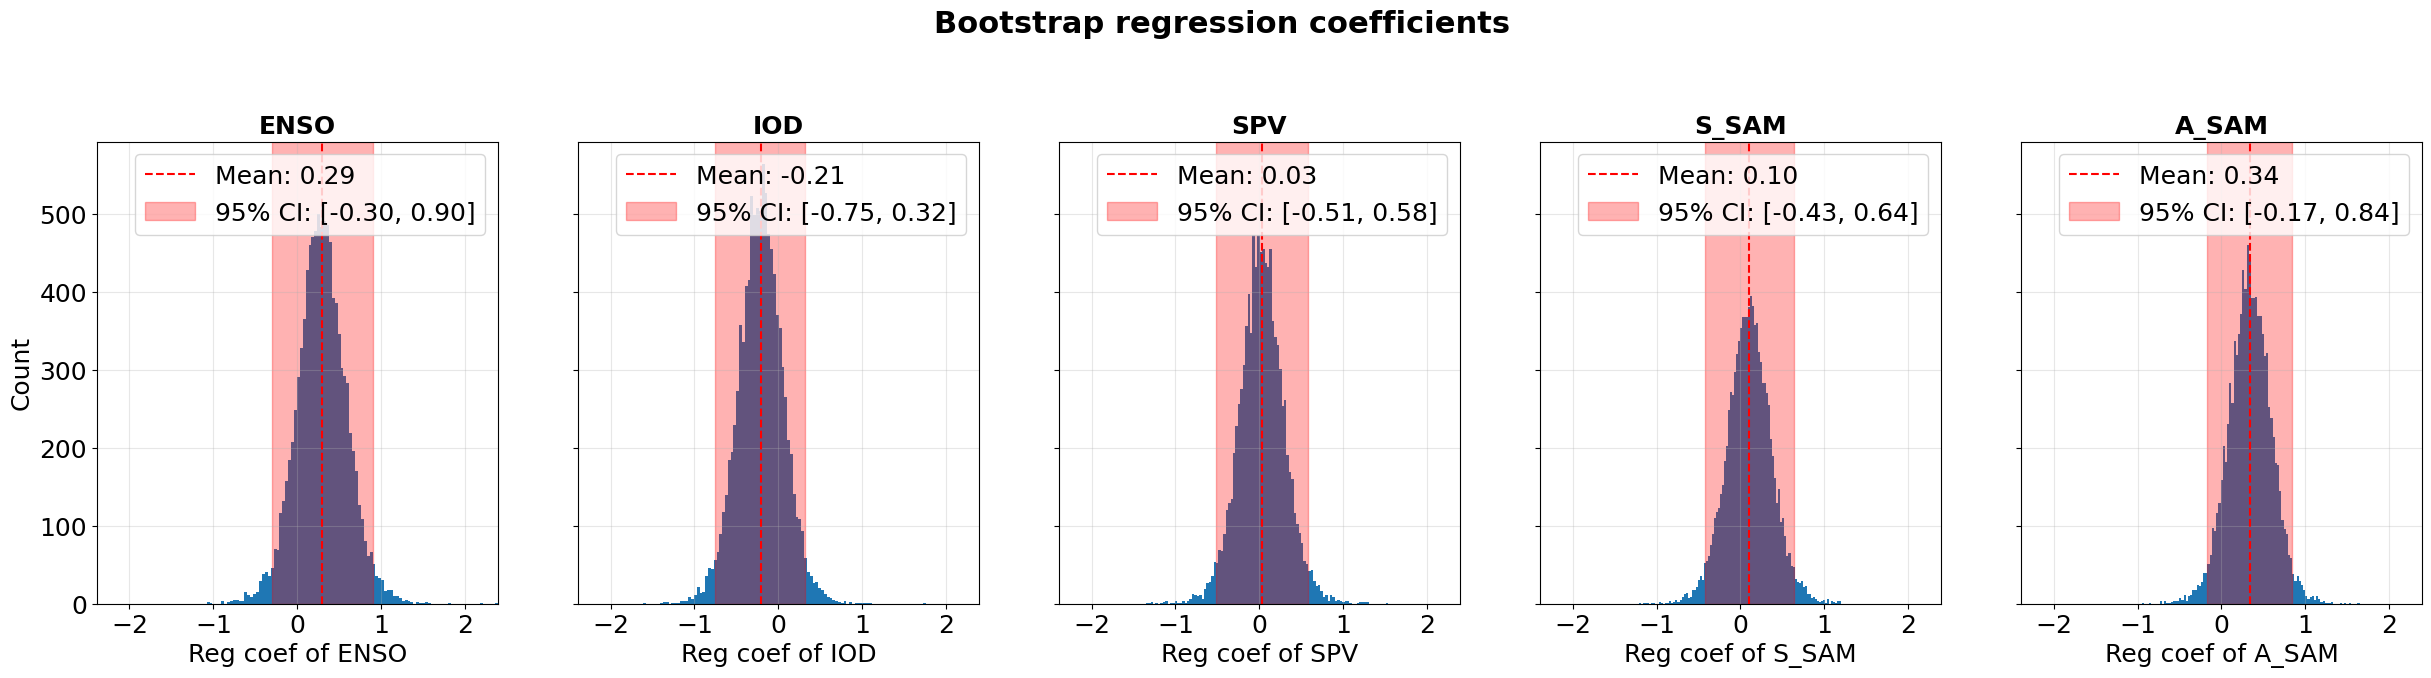

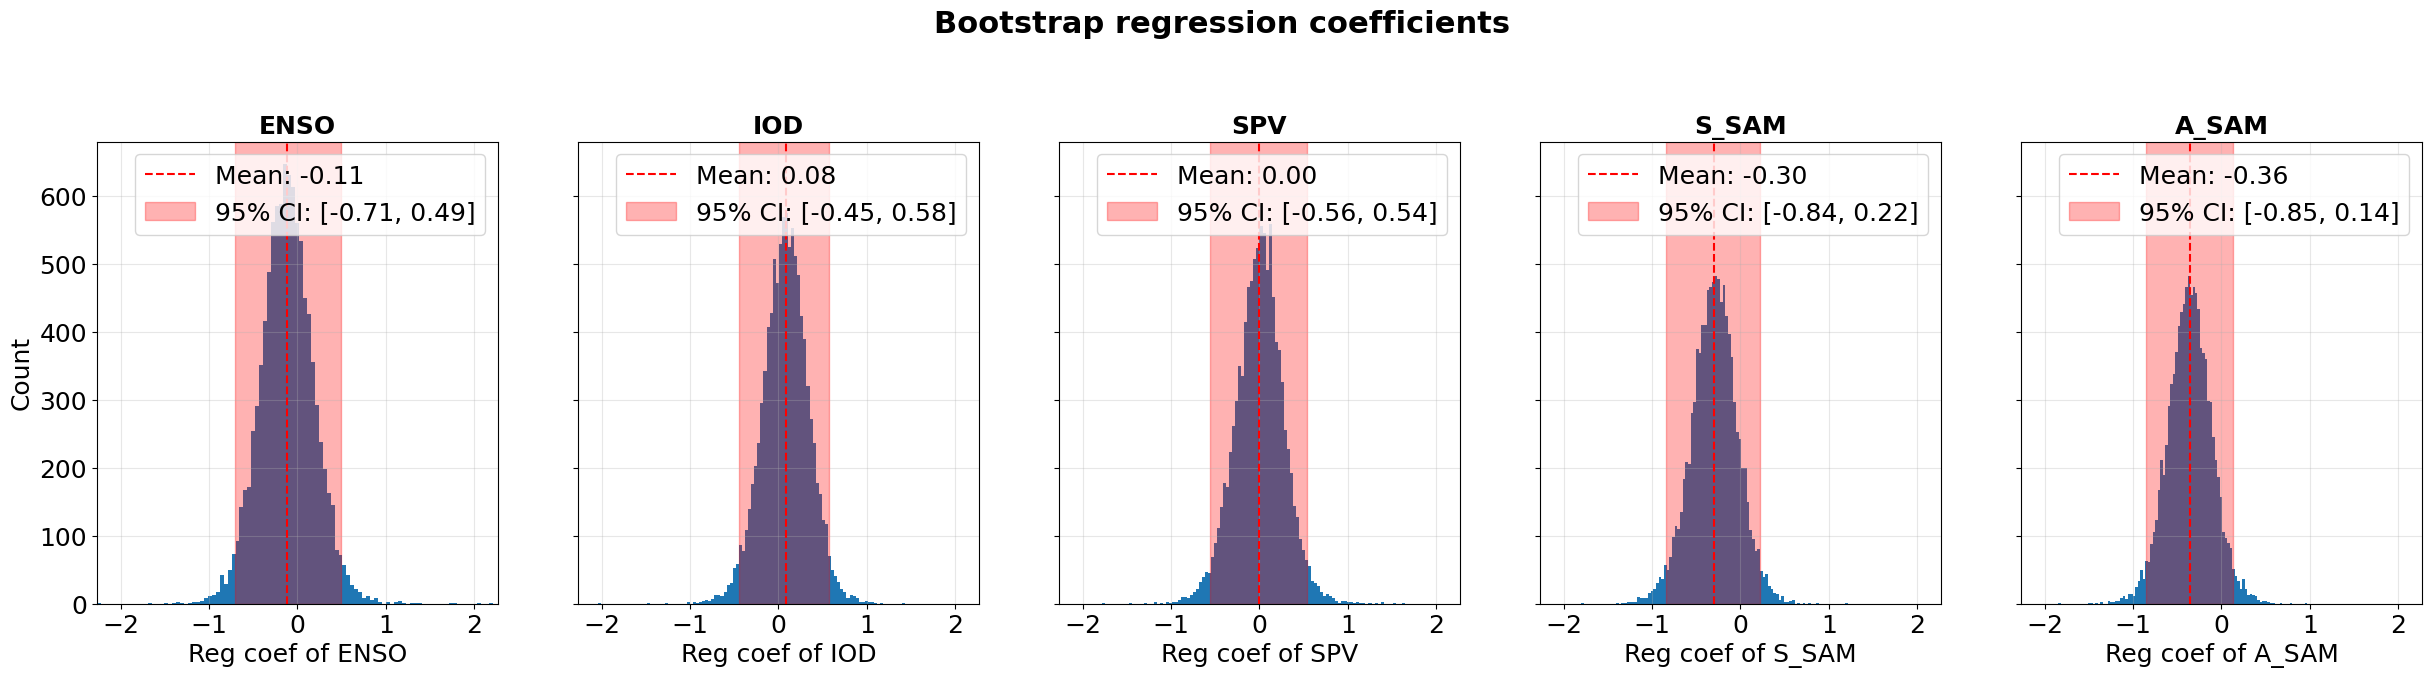

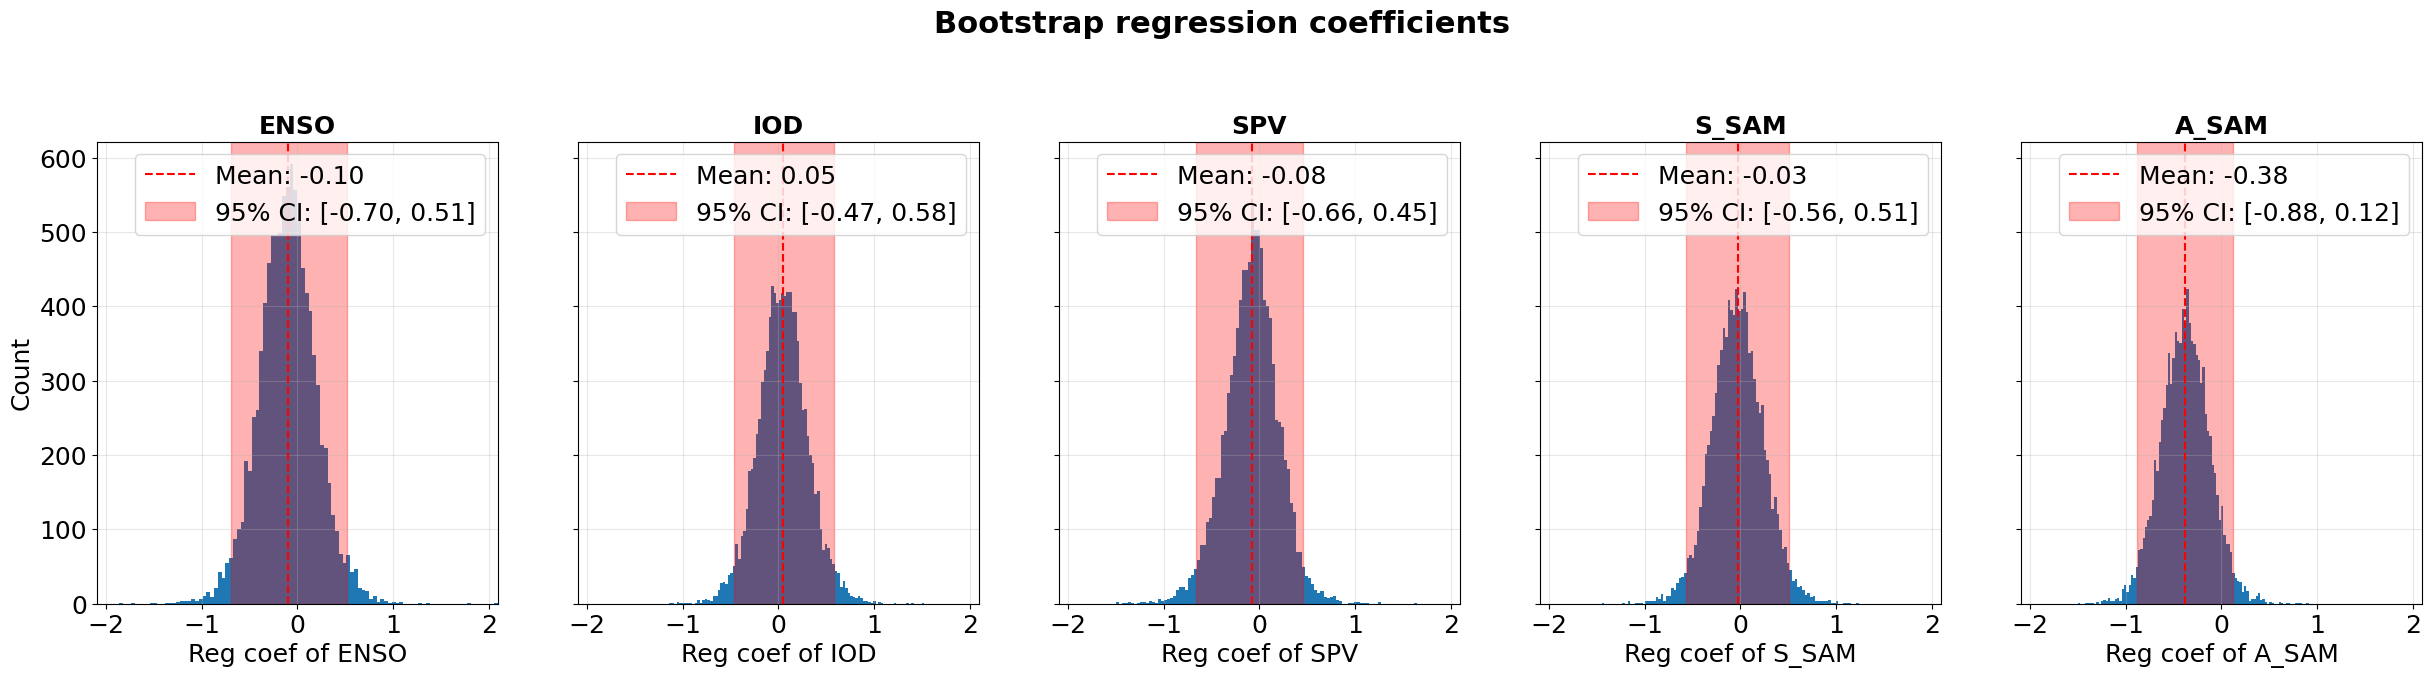

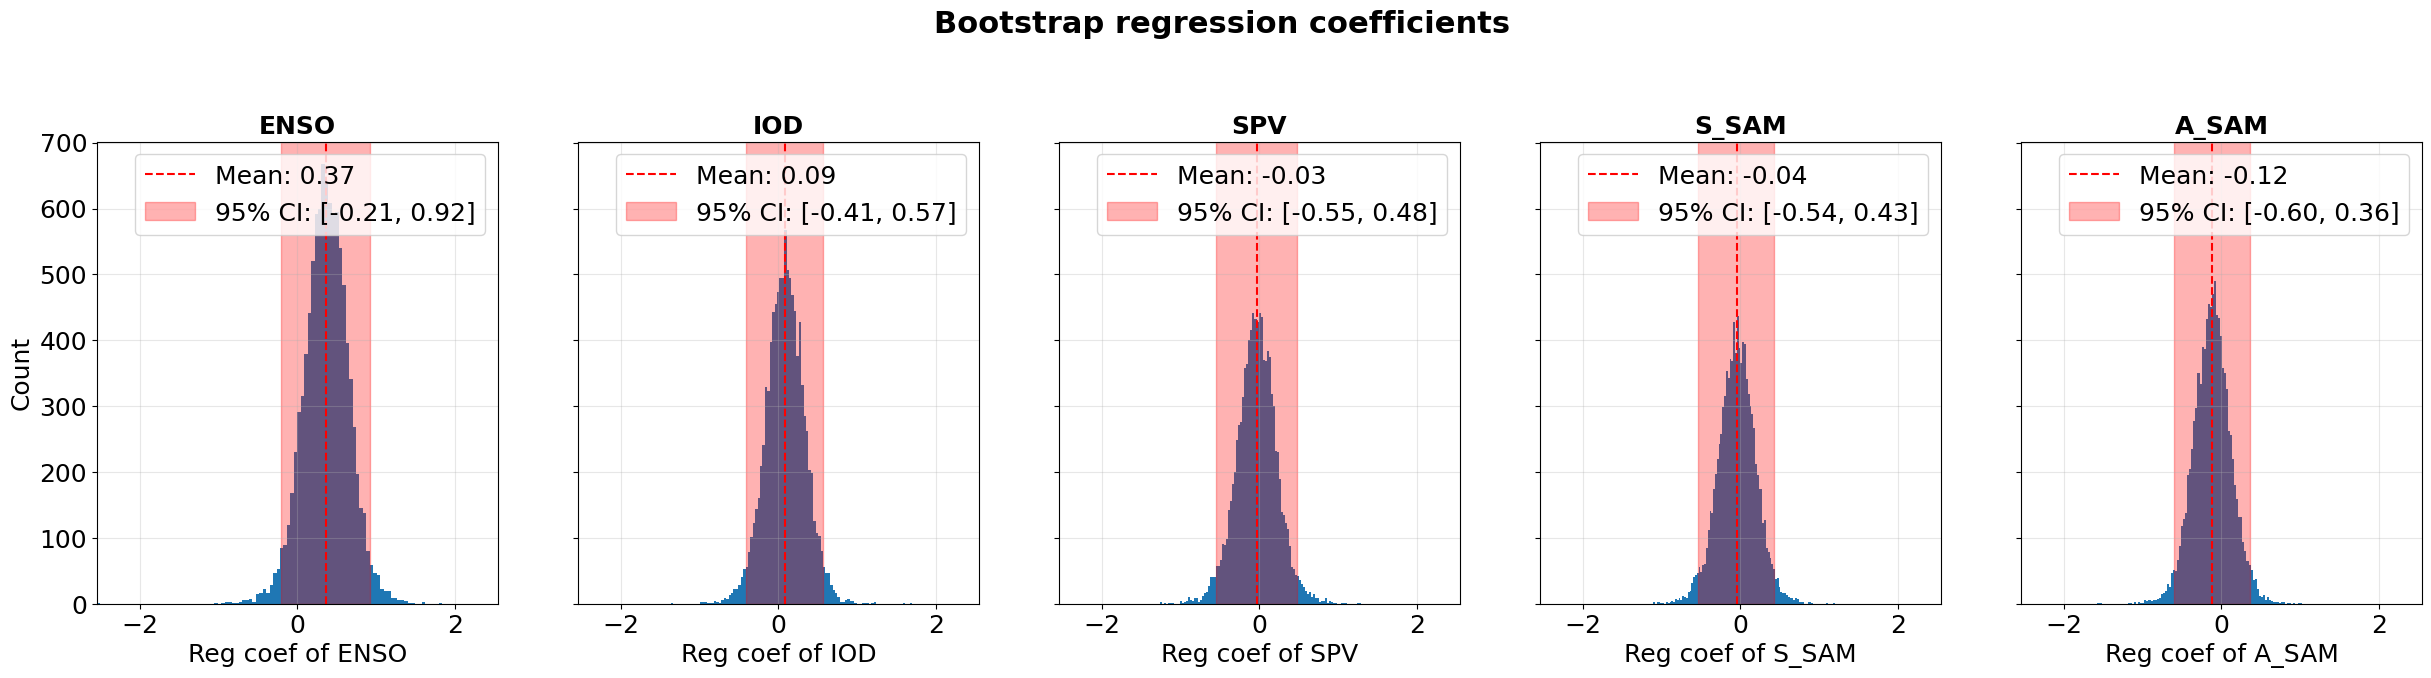

In [54]:
#direct effects on T and precip in both regions
results_direct_T_Andes_SON_1000=bootstrap_regression(target_Andes_SON_xr, drivers_SON_xr, 't2m', drivers_SON, n_boot=10000, sample_size=200, add_intercept=False)
results_direct_Pr_Andes_SON_1000=bootstrap_regression(target_Andes_SON_xr, drivers_SON_xr, 'tp', drivers_SON, n_boot=10000, sample_size=200, add_intercept=False)
results_direct_T_LP_SON_1000=bootstrap_regression(target_LP_SON_xr, drivers_SON_xr, 't2m', drivers_SON, n_boot=10000, sample_size=200, add_intercept=False)
results_direct_Pr_LP_SON_1000=bootstrap_regression(target_LP_SON_xr, drivers_SON_xr, 'tp', drivers_SON, n_boot=10000, sample_size=200, add_intercept=False)

for element in [results_direct_T_Andes_SON_1000, results_direct_Pr_Andes_SON_1000, results_direct_T_LP_SON_1000, results_direct_Pr_LP_SON_1000]:
    plot_bootstrap_coefficients(element, drivers_SON)

ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000
ENSO ['ENSO']
IOD ['IOD', 'ENSO']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


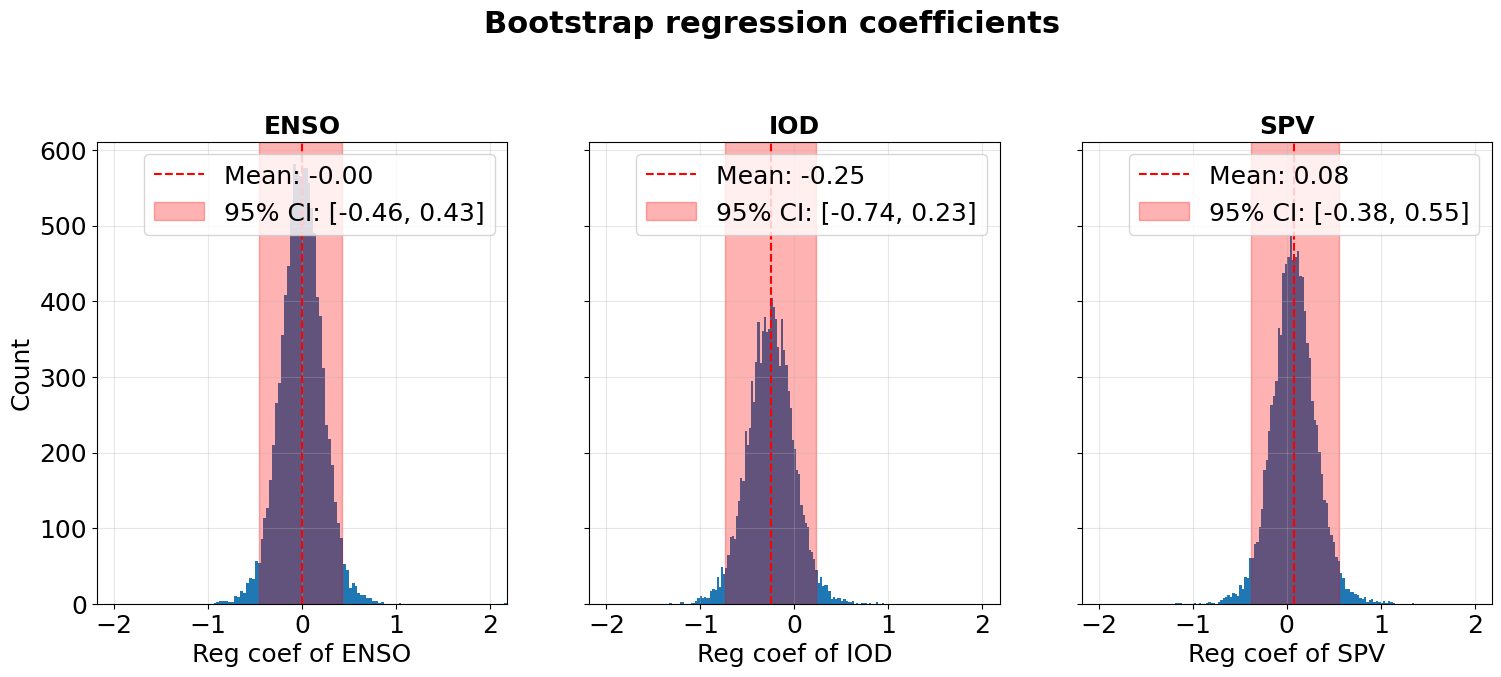

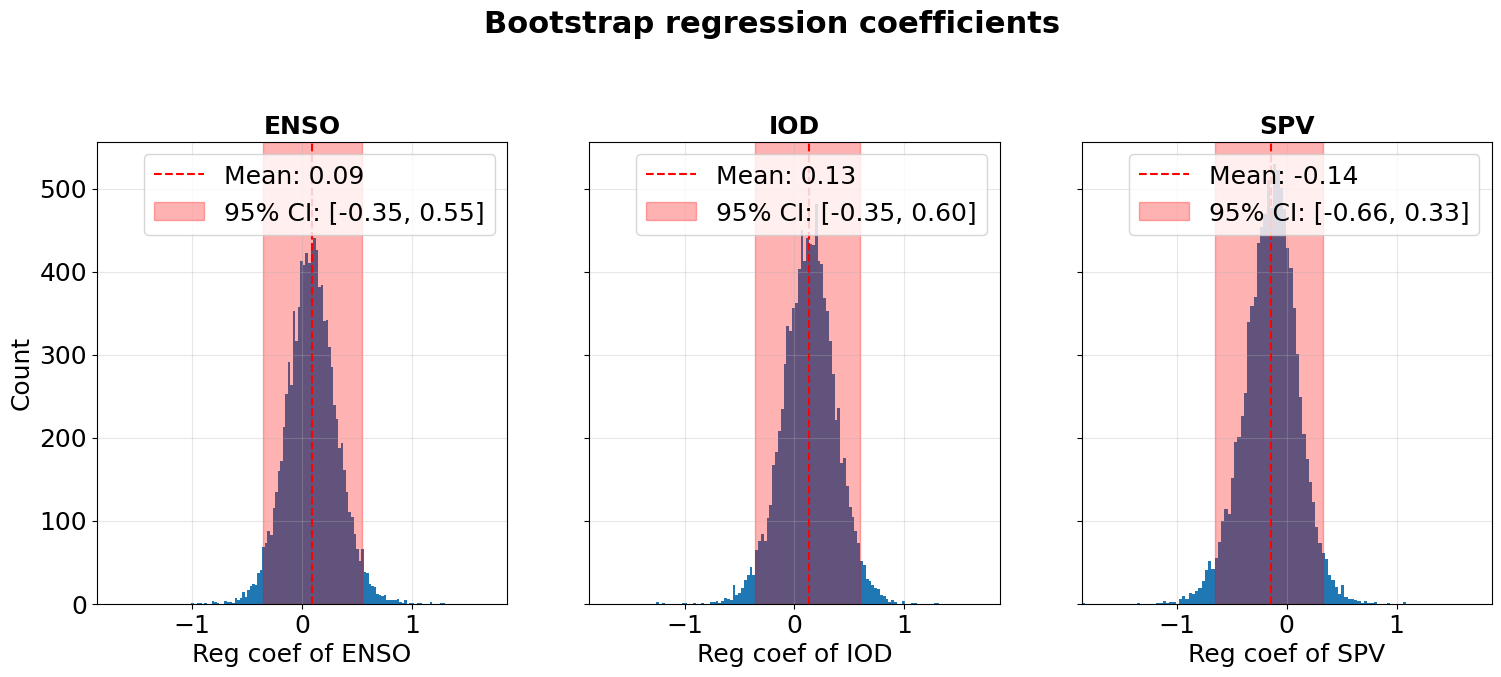

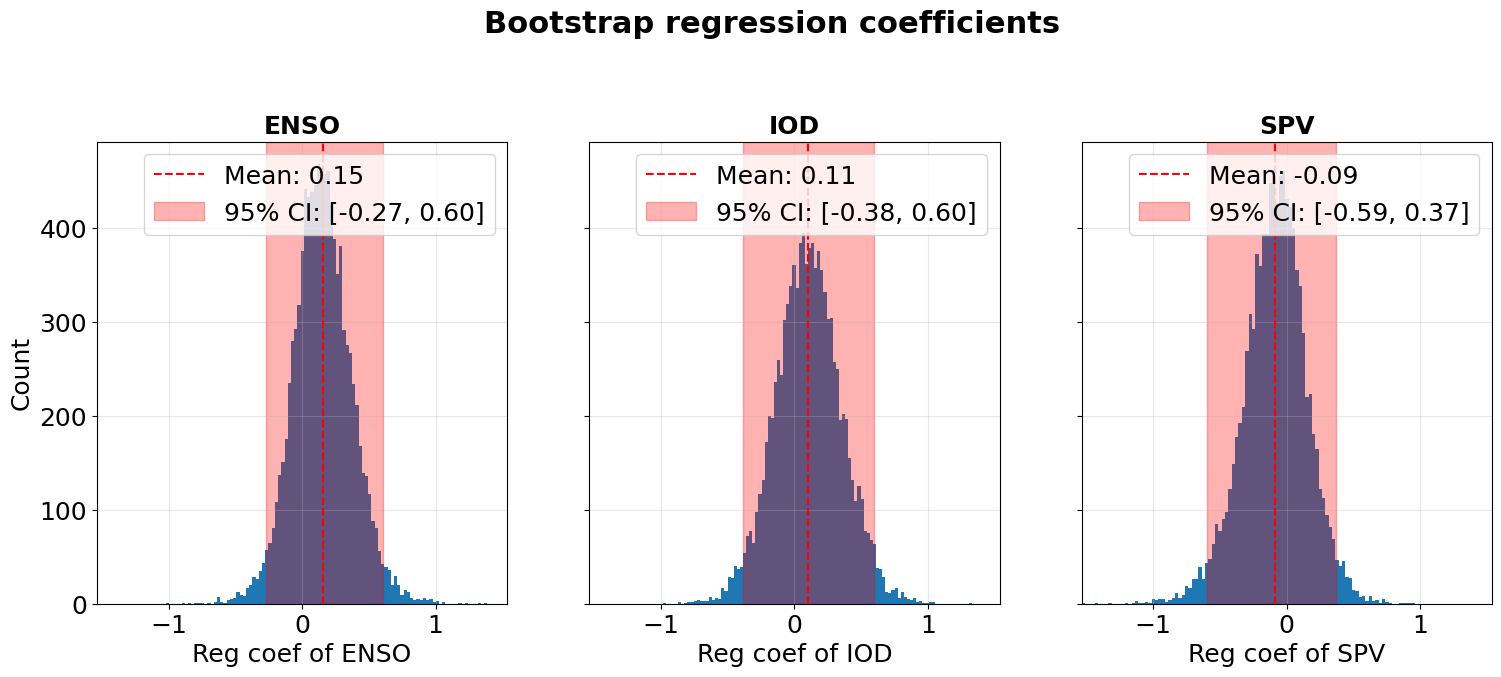

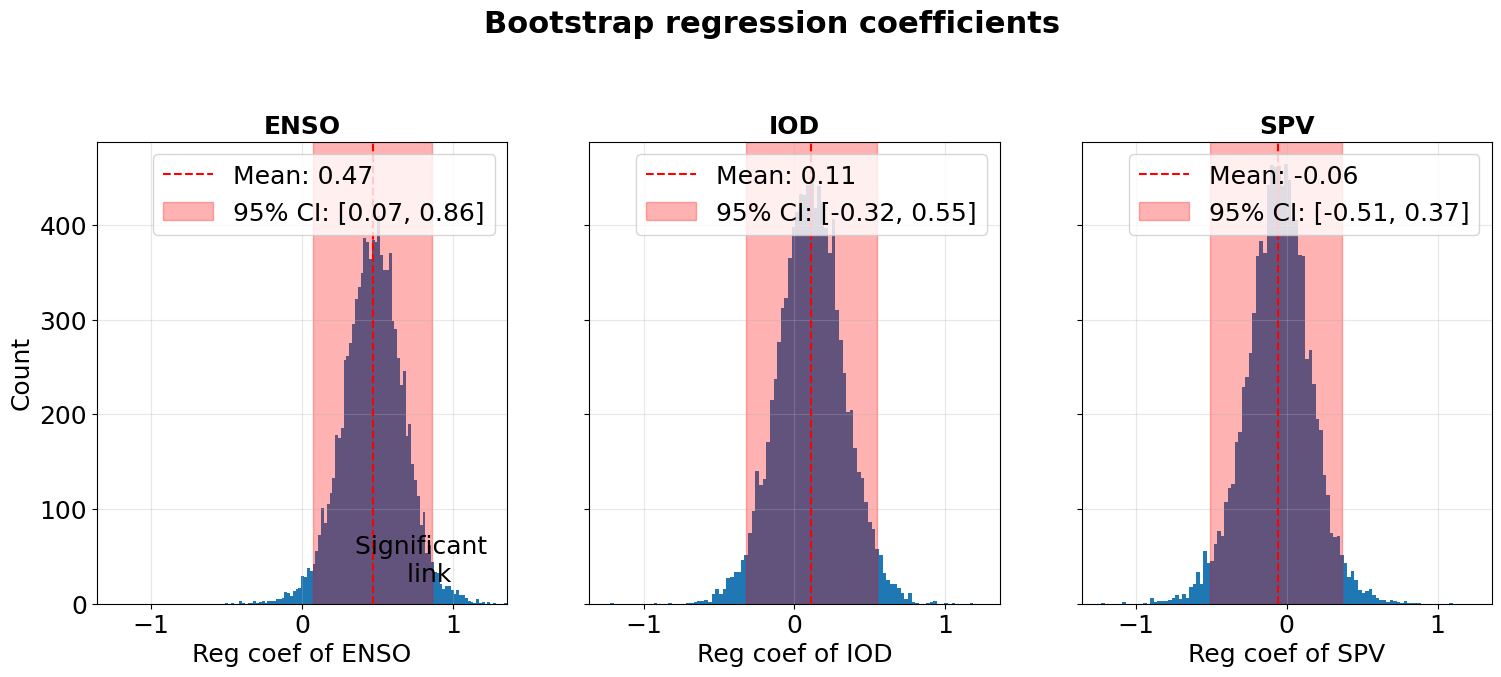

In [55]:
#total effects on T and precip in both regions
tot_drivers=['ENSO', 'IOD', 'SPV']
results_tot_T_Andes_SON_1000=bootstrap_regression(target_Andes_SON_xr, drivers_SON_xr, 't2m', tot_drivers, n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)
results_tot_Pr_Andes_SON_1000=bootstrap_regression(target_Andes_SON_xr, drivers_SON_xr, 'tp', tot_drivers, n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)
results_tot_T_LP_SON_1000=bootstrap_regression(target_LP_SON_xr, drivers_SON_xr, 't2m', tot_drivers, n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)
results_tot_Pr_LP_SON_1000=bootstrap_regression(target_LP_SON_xr, drivers_SON_xr, 'tp', tot_drivers, n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)

for element in [results_tot_T_Andes_SON_1000, results_tot_Pr_Andes_SON_1000, results_tot_T_LP_SON_1000, results_tot_Pr_LP_SON_1000]:
    plot_bootstrap_coefficients(element, tot_drivers)

ENSO ['ENSO']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD']
IOD ['IOD', 'ENSO']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOD', 'SPV']
IOD ['IOD', 'ENSO', 'SPV']
SPV ['SPV', 'ENSO', 'IOD']
Valid bootstraps: 10000/10000


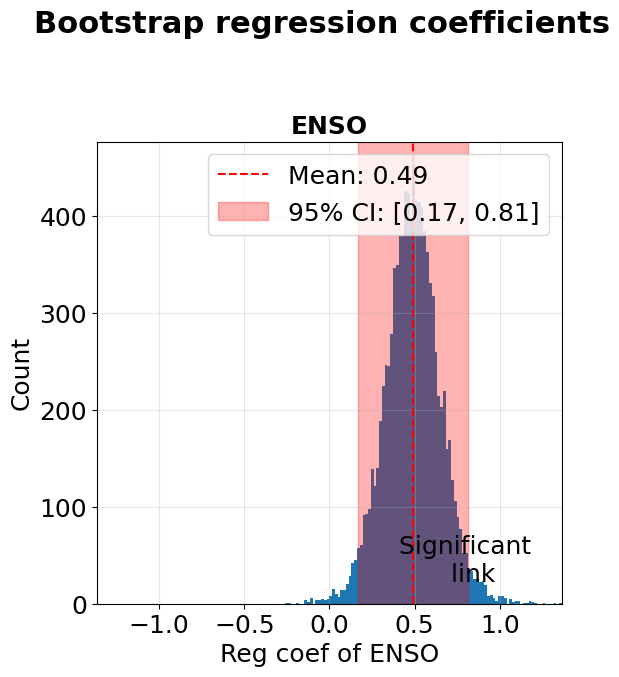

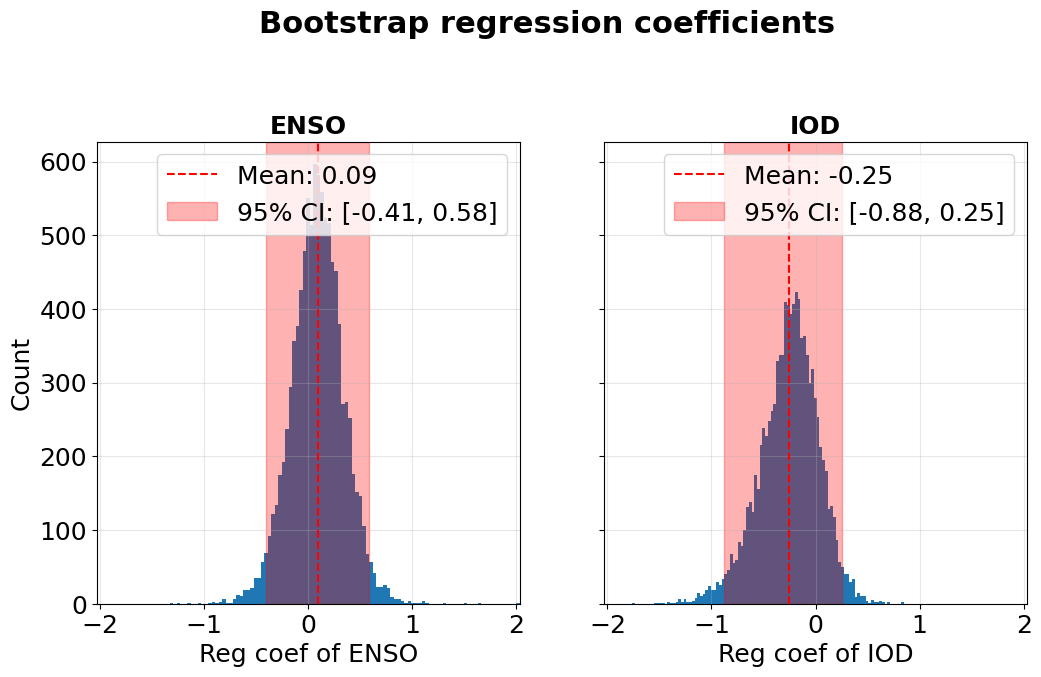

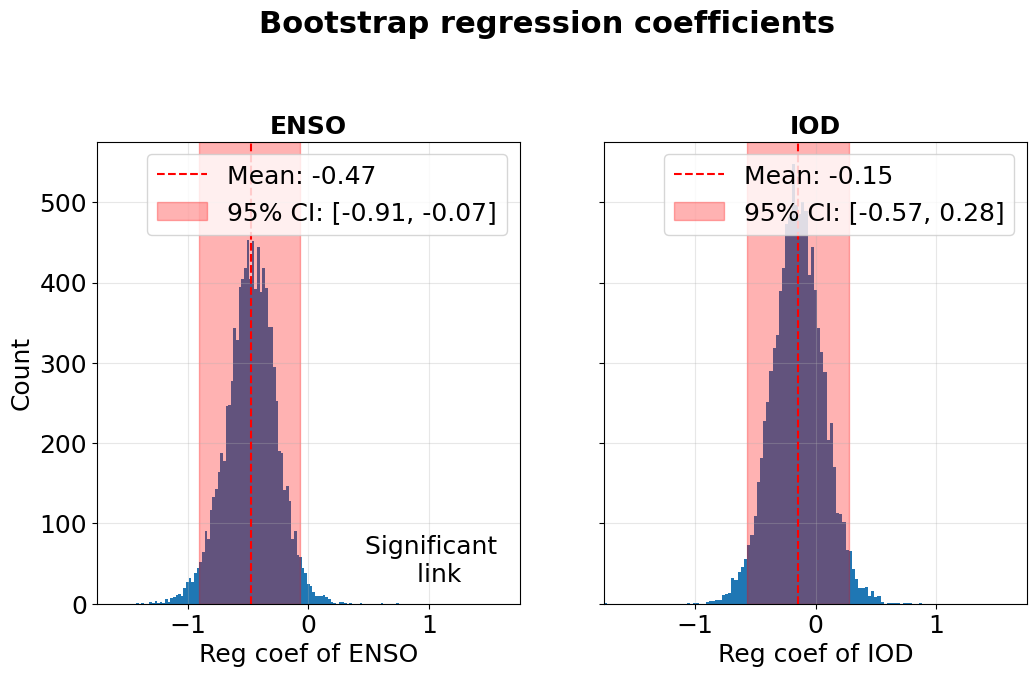

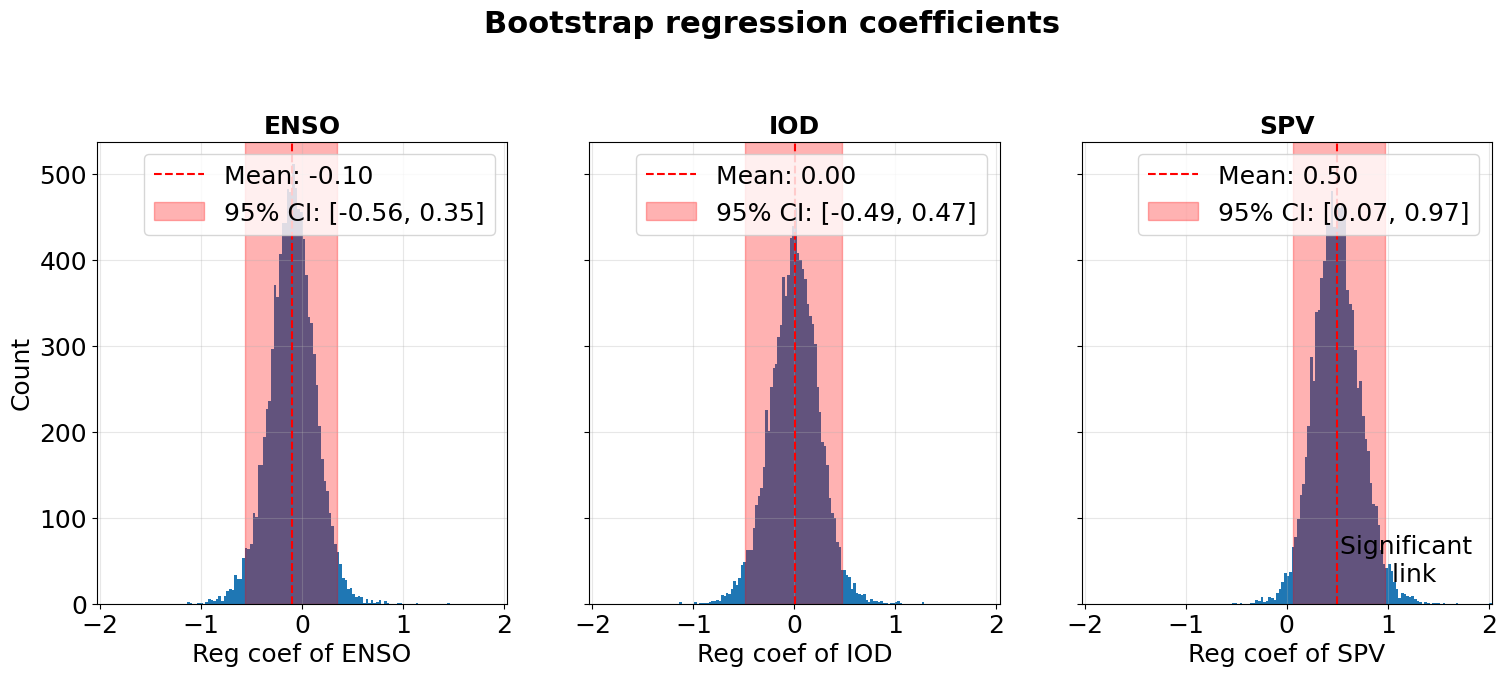

In [56]:
#other links
results_IOD_1000=bootstrap_regression(drivers_SON_xr, drivers_SON_xr, 'IOD', ['ENSO'], n_boot=10000, sample_size=200, 
                                      add_intercept=False
                                      )
results_SPV_1000=bootstrap_regression(drivers_SON_xr, drivers_SON_xr, 'SPV', ['ENSO', 'IOD'], n_boot=10000, sample_size=200, 
                                      add_intercept=False
                                      )
results_A_SAM_1000=bootstrap_regression(drivers_SON_xr, drivers_SON_xr, 'A_SAM', ['ENSO', 'IOD'], n_boot=10000, sample_size=200, 
                                      add_intercept=False
                                      )
results_S_SAM_1000=bootstrap_regression(drivers_SON_xr, drivers_SON_xr, 'S_SAM', ['ENSO','IOD', 'SPV'], n_boot=10000, sample_size=200, 
                                      add_intercept=False
                                      )

plot_bootstrap_coefficients(results_IOD_1000, ['ENSO'])
plot_bootstrap_coefficients(results_SPV_1000, ['ENSO', 'IOD'])
plot_bootstrap_coefficients(results_A_SAM_1000, ['ENSO', 'IOD'])
plot_bootstrap_coefficients(results_S_SAM_1000, ['ENSO', 'IOD', 'SPV'])

# DJF

In [57]:
drivers_DJF=['ENSO', 'IOBW','VB', 'S_SAM', 'A_SAM']
drivers_DJF_tot=['ENSO', 'IOBW', 'VB']

Andes direct

ENSO ['ENSO', 'IOBW', 'VB', 'S_SAM', 'A_SAM']
IOBW ['IOBW', 'ENSO', 'VB', 'S_SAM', 'A_SAM']
VB ['VB', 'ENSO', 'IOBW', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOBW', 'VB']
A_SAM ['A_SAM', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOBW', 'VB', 'S_SAM', 'A_SAM']
IOBW ['IOBW', 'ENSO', 'VB', 'S_SAM', 'A_SAM']
VB ['VB', 'ENSO', 'IOBW', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOBW', 'VB']
A_SAM ['A_SAM', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000


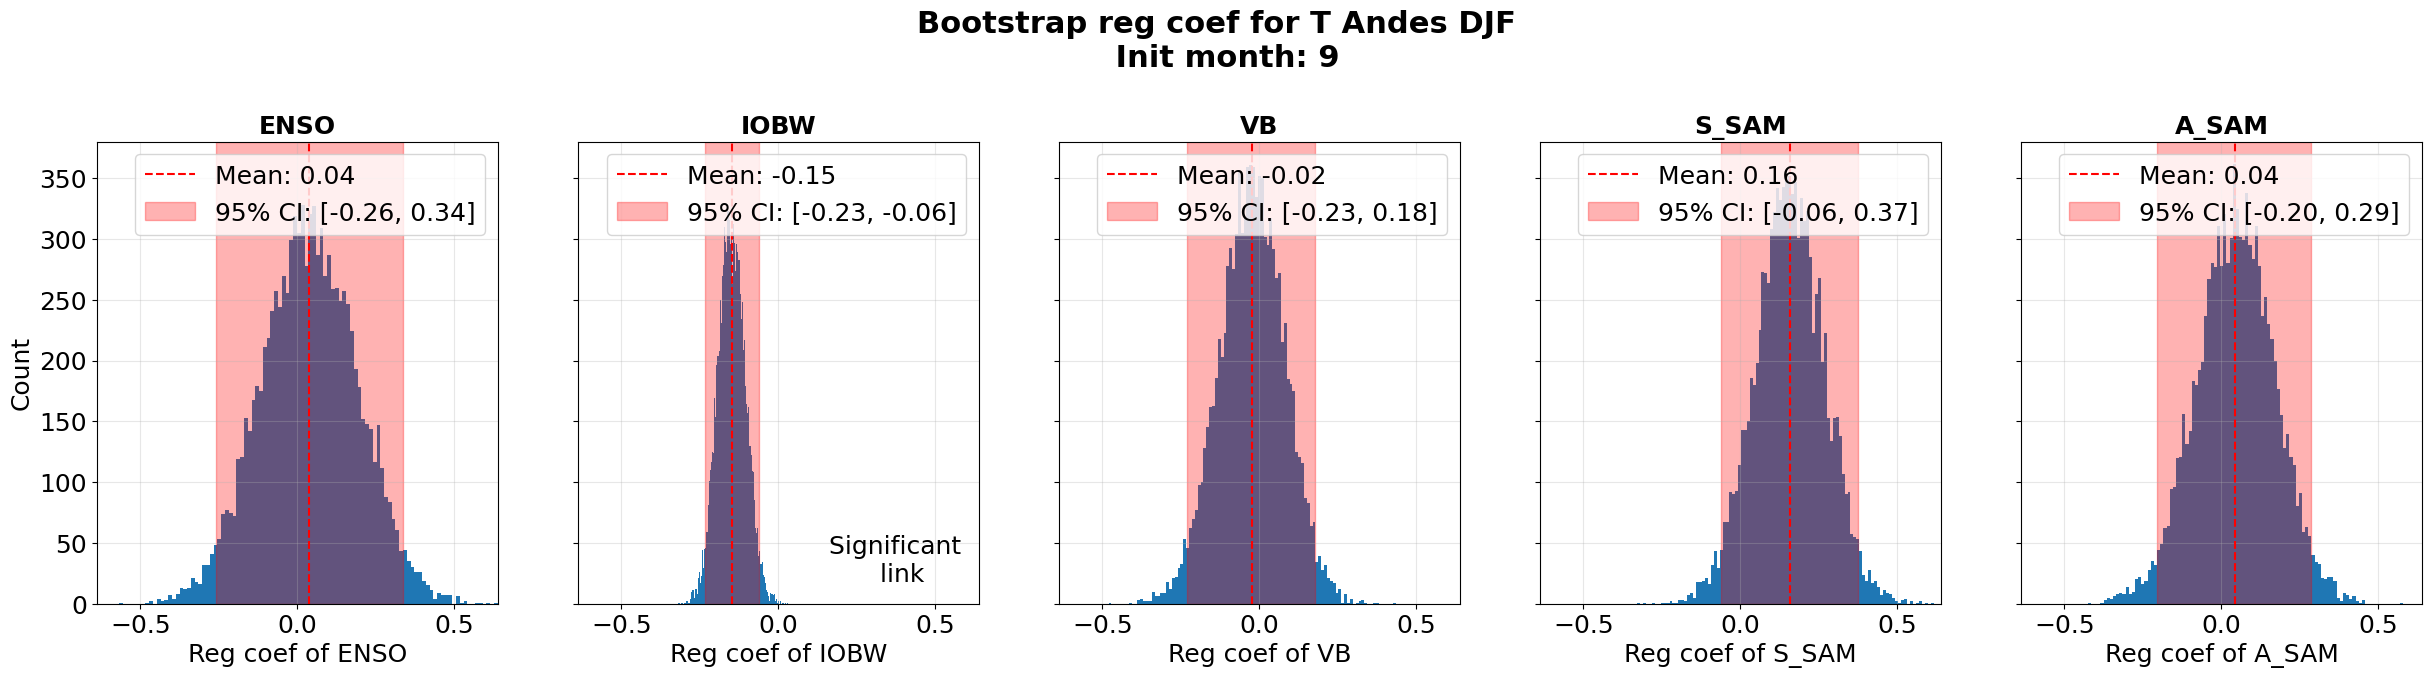

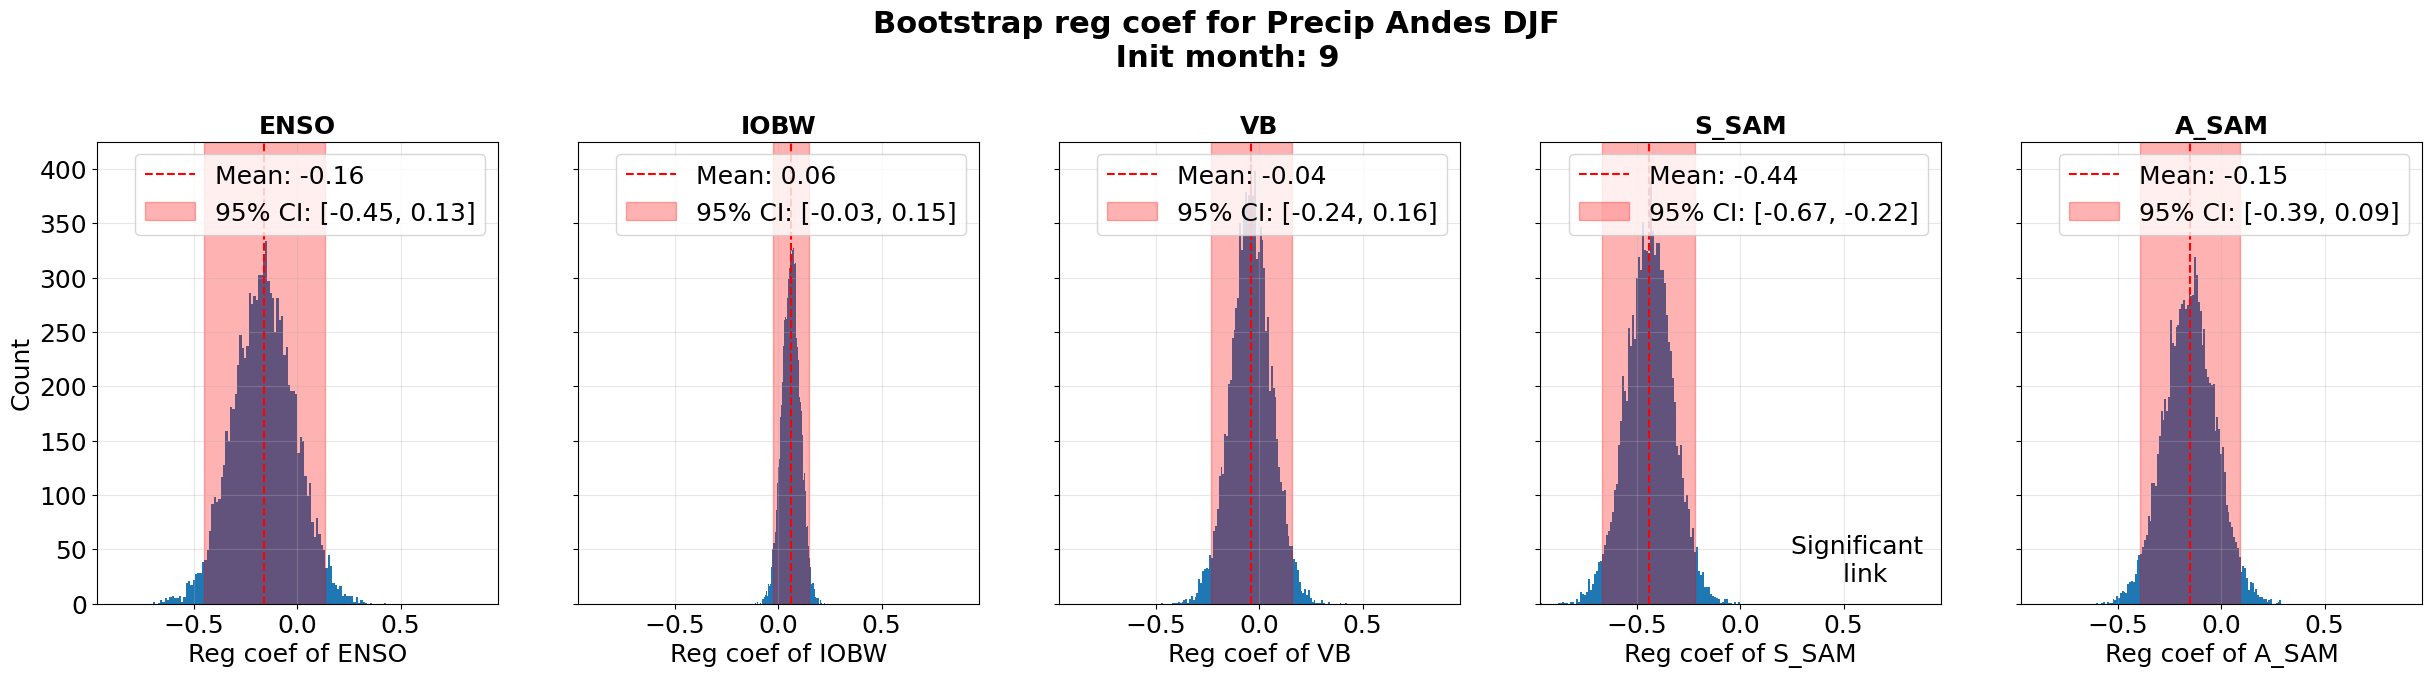

In [70]:
results_T_Andes_DJF_1000=bootstrap_regression(target_Andes_DJF_xr, drivers_DJF_xr, 't2m', drivers_DJF, 
                                              n_boot=10000, sample_size=200, add_intercept=False)
results_Pr_Andes_DJF_1000=bootstrap_regression(target_Andes_DJF_xr, drivers_DJF_xr, 'tp', drivers_DJF, 
                                               n_boot=10000, sample_size=200, add_intercept=False)

plot_bootstrap_coefficients(results_T_Andes_DJF_1000, drivers_DJF, 'Bootstrap reg coef for T Andes DJF \n Init month: 9')
plot_bootstrap_coefficients(results_Pr_Andes_DJF_1000, drivers_DJF, 'Bootstrap reg coef for Precip Andes DJF \n Init month: 9')

Andes total

ENSO ['ENSO']
IOBW ['IOBW', 'ENSO']
VB ['VB', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000
ENSO ['ENSO']
IOBW ['IOBW', 'ENSO']
VB ['VB', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000


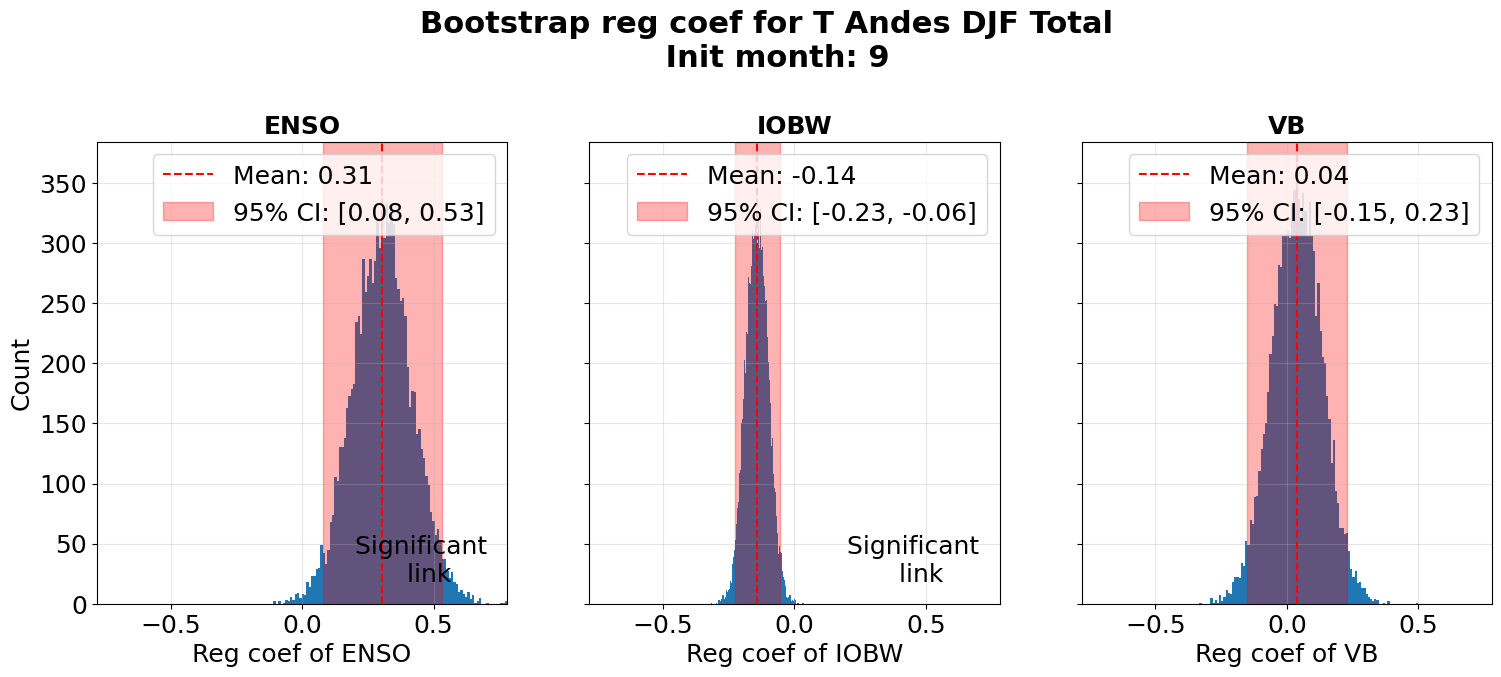

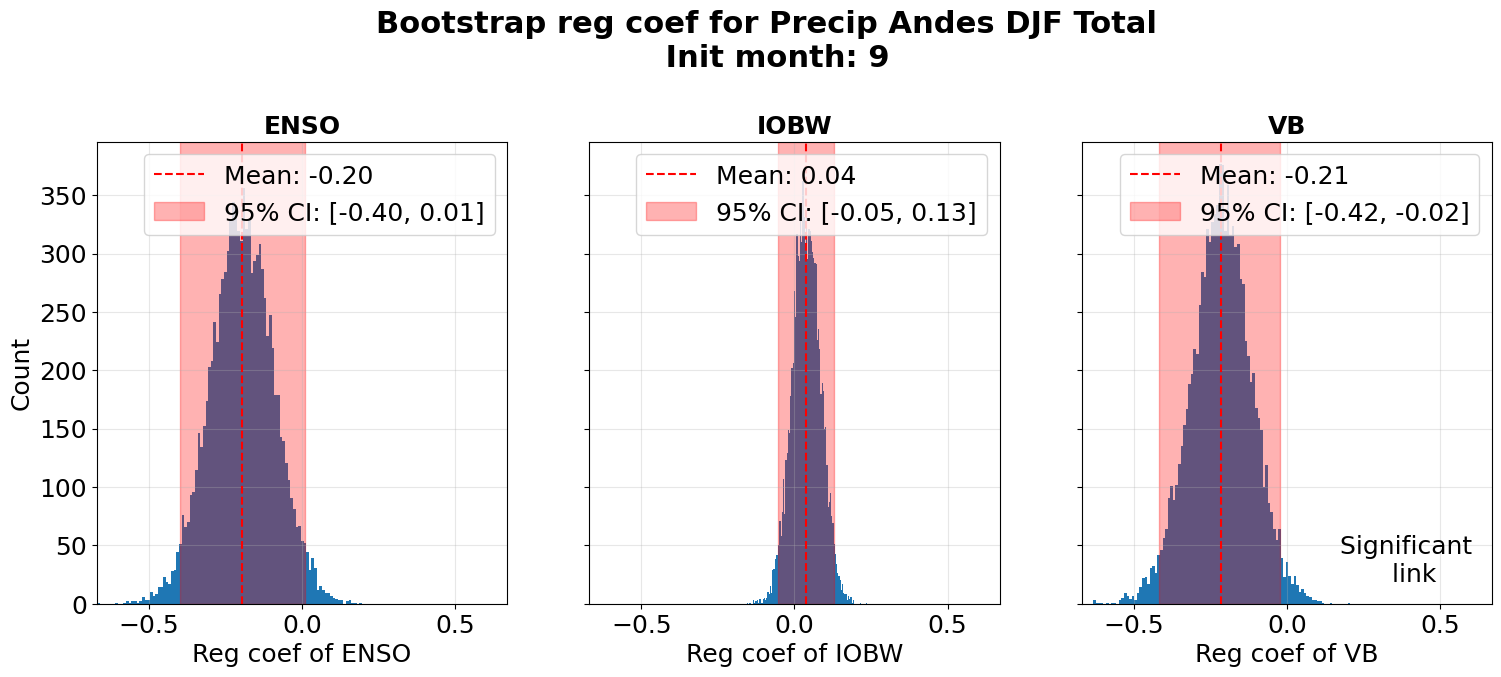

In [58]:
results_T_Andes_DJF_1000_tot=bootstrap_regression(target_Andes_DJF_xr, drivers_DJF_xr, 't2m', drivers_DJF_tot, 
                                              n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)
results_Pr_Andes_DJF_1000_tot=bootstrap_regression(target_Andes_DJF_xr, drivers_DJF_xr, 'tp', drivers_DJF_tot, 
                                               n_boot=10000, sample_size=200, add_intercept=False, total_eff=True)

plot_bootstrap_coefficients(results_T_Andes_DJF_1000_tot, drivers_DJF_tot, 'Bootstrap reg coef for T Andes DJF Total \n Init month: 9')
plot_bootstrap_coefficients(results_Pr_Andes_DJF_1000_tot, drivers_DJF_tot, 'Bootstrap reg coef for Precip Andes DJF Total \n Init month: 9')

La Plata direct

ENSO ['ENSO', 'IOBW', 'VB', 'S_SAM', 'A_SAM']
IOBW ['IOBW', 'ENSO', 'VB', 'S_SAM', 'A_SAM']
VB ['VB', 'ENSO', 'IOBW', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOBW', 'VB']
A_SAM ['A_SAM', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOBW', 'VB', 'S_SAM', 'A_SAM']
IOBW ['IOBW', 'ENSO', 'VB', 'S_SAM', 'A_SAM']
VB ['VB', 'ENSO', 'IOBW', 'S_SAM']
S_SAM ['S_SAM', 'ENSO', 'IOBW', 'VB']
A_SAM ['A_SAM', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000


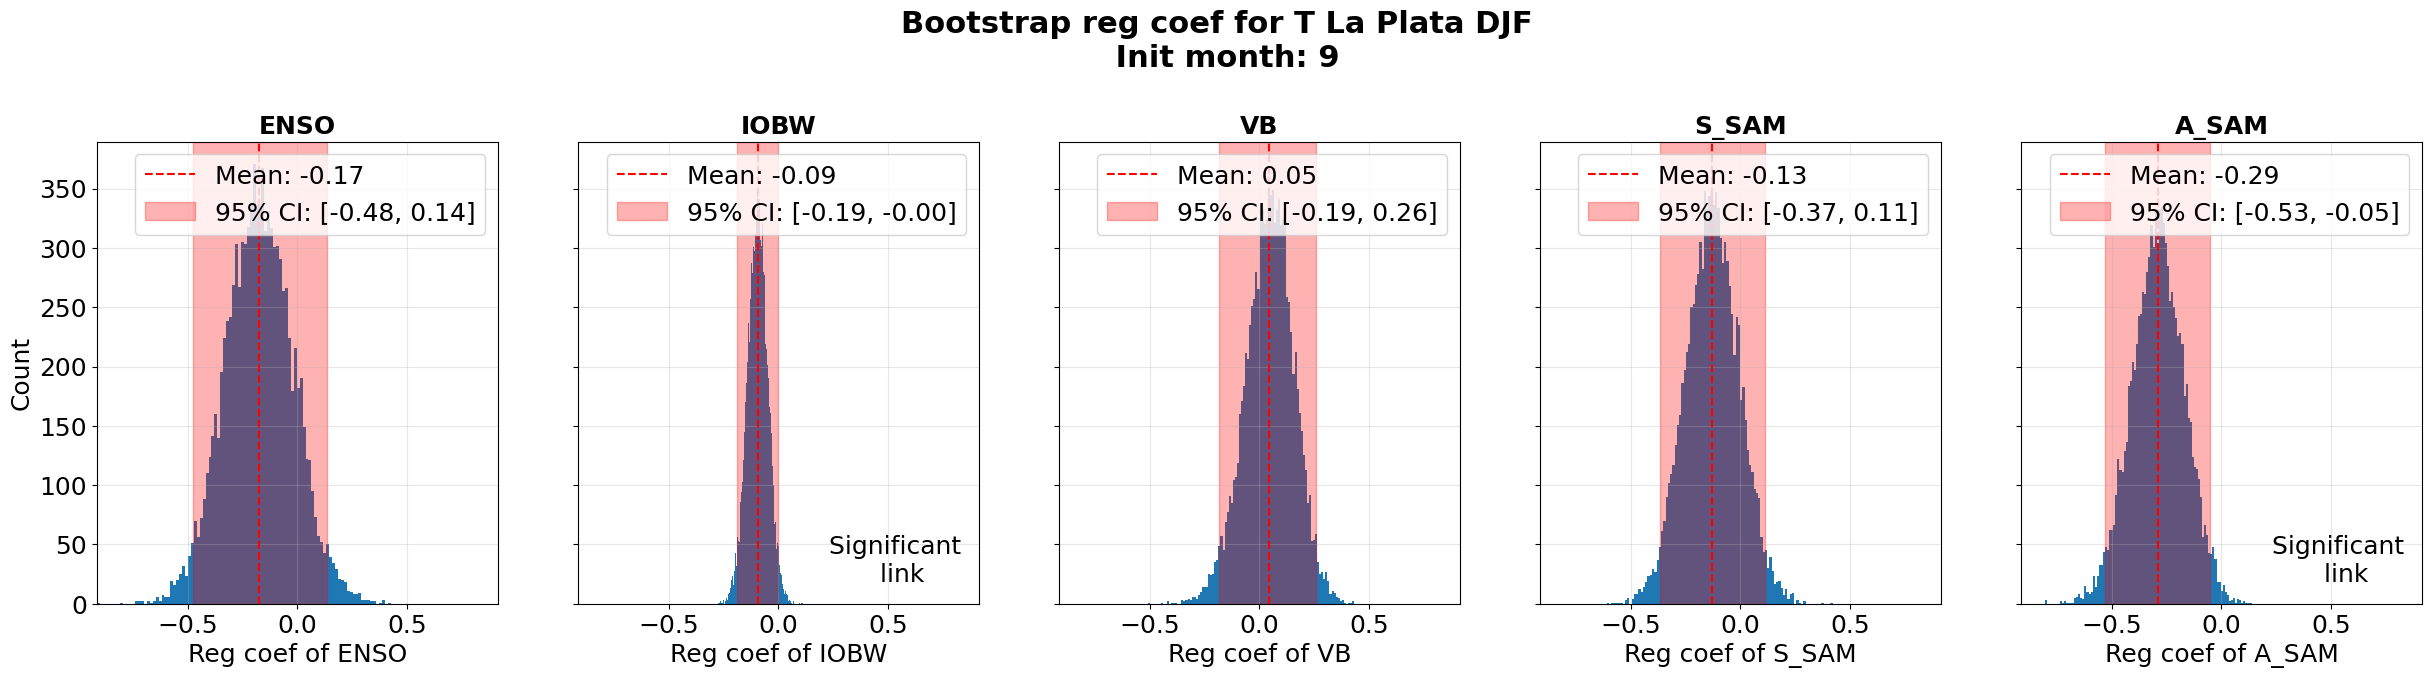

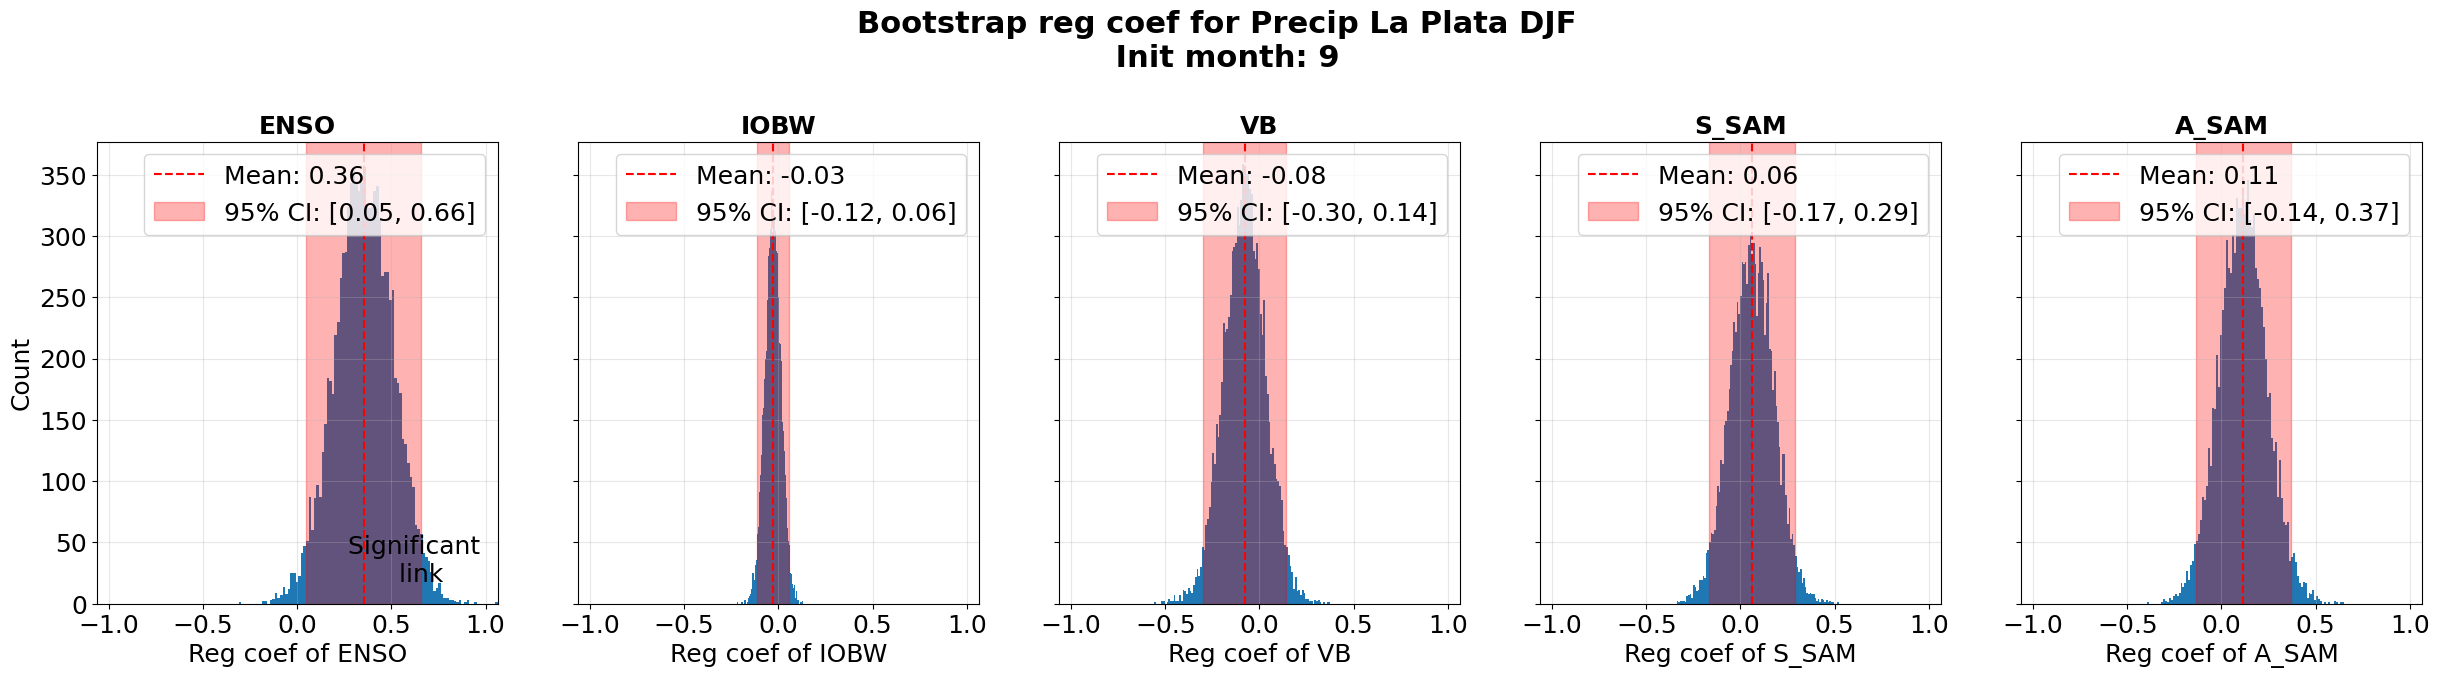

In [59]:
results_T_LP_DJF_1000=bootstrap_regression(target_LP_DJF_xr, drivers_DJF_xr, 't2m', drivers_DJF, 
                                              n_boot=10000, sample_size=200, add_intercept=False)
results_Pr_LP_DJF_1000=bootstrap_regression(target_LP_DJF_xr, drivers_DJF_xr, 'tp', drivers_DJF, 
                                               n_boot=10000, sample_size=200, add_intercept=False)

plot_bootstrap_coefficients(results_T_LP_DJF_1000, drivers_DJF, 'Bootstrap reg coef for T La Plata DJF \n Init month: 9')
plot_bootstrap_coefficients(results_Pr_LP_DJF_1000, drivers_DJF, 'Bootstrap reg coef for Precip La Plata DJF \n Init month: 9')

La Plata total

ENSO ['ENSO', 'IOBW', 'VB']
IOBW ['IOBW', 'ENSO', 'VB']
VB ['VB', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000
ENSO ['ENSO', 'IOBW', 'VB']
IOBW ['IOBW', 'ENSO', 'VB']
VB ['VB', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000


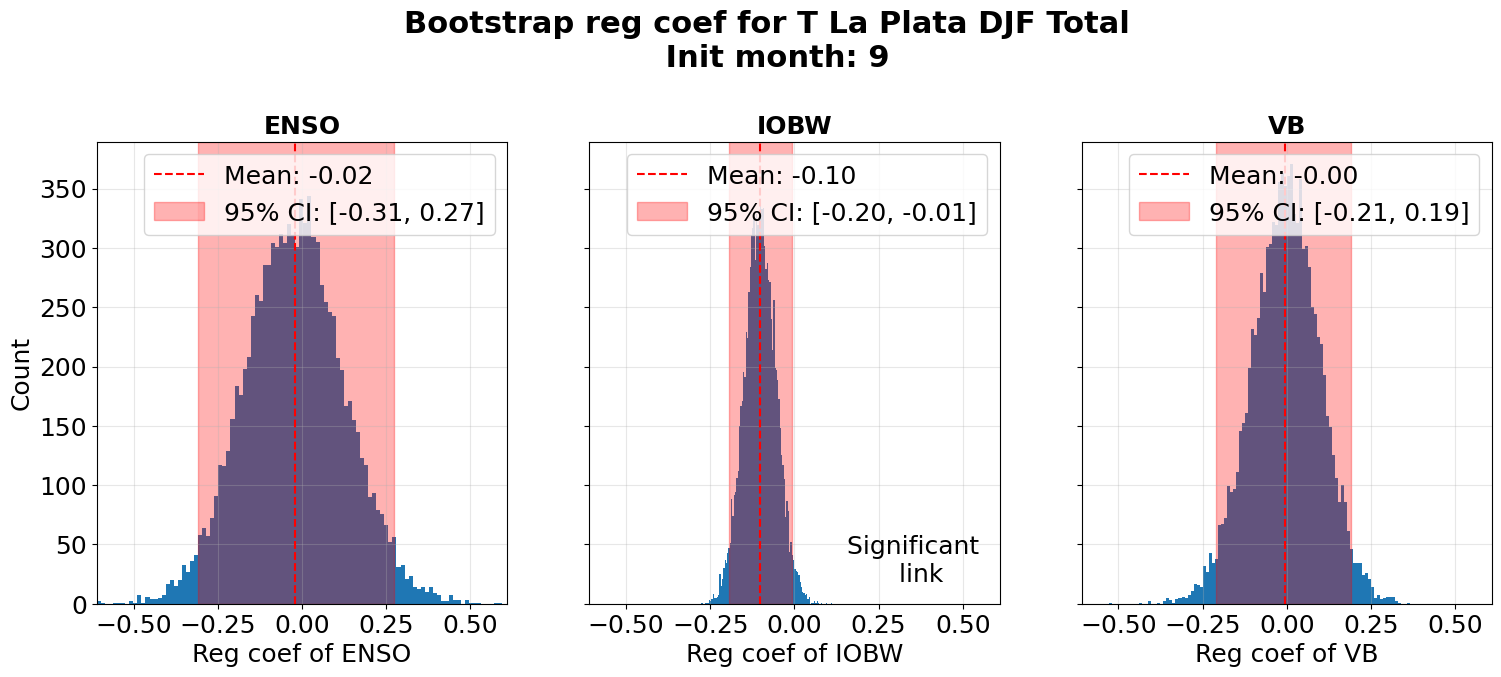

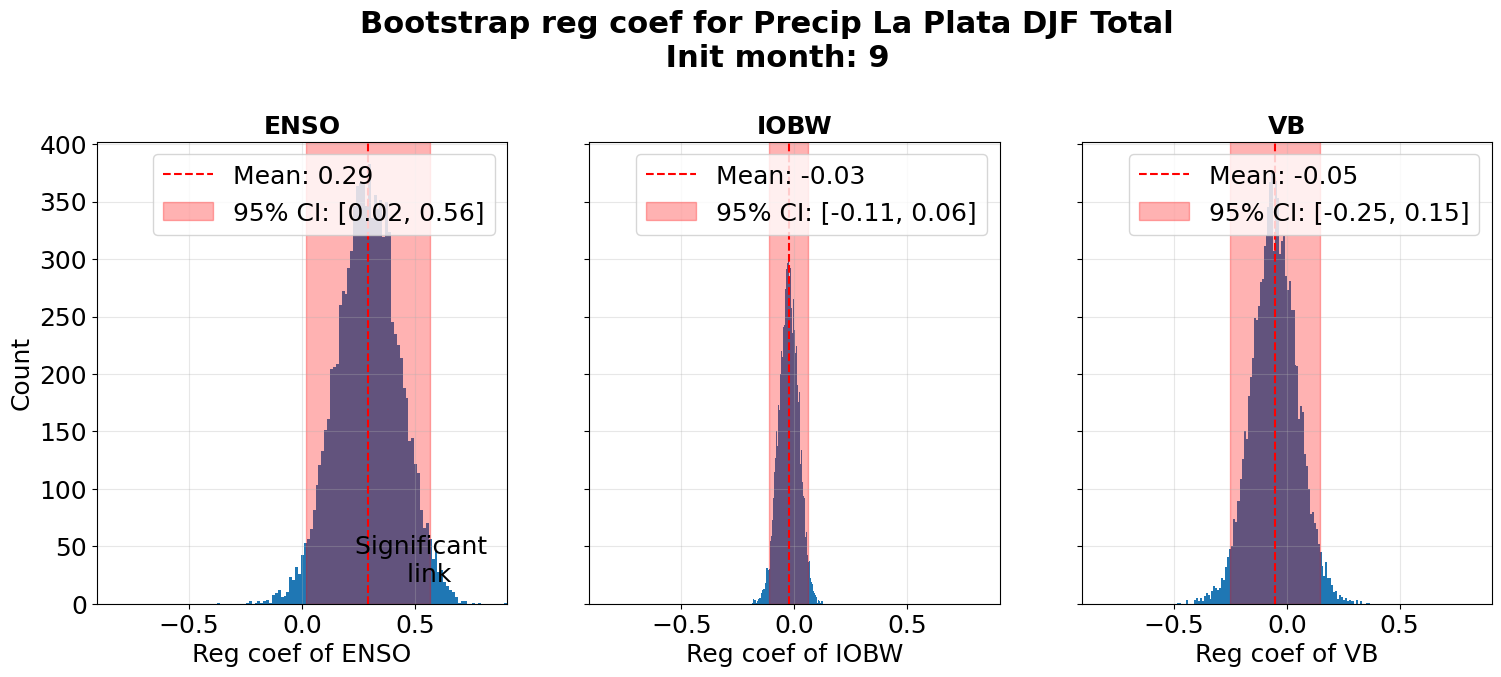

In [61]:
results_T_LP_DJF_1000_tot=bootstrap_regression(target_LP_DJF_xr, drivers_DJF_xr, 't2m', drivers_DJF_tot, 
                                              n_boot=10000, sample_size=200, add_intercept=False)
results_Pr_LP_DJF_1000_tot=bootstrap_regression(target_LP_DJF_xr, drivers_DJF_xr, 'tp', drivers_DJF_tot, 
                                               n_boot=10000, sample_size=200, add_intercept=False)

plot_bootstrap_coefficients(results_T_LP_DJF_1000_tot, drivers_DJF_tot, 'Bootstrap reg coef for T La Plata DJF Total \n Init month: 9')
plot_bootstrap_coefficients(results_Pr_LP_DJF_1000_tot, drivers_DJF_tot, 'Bootstrap reg coef for Precip La Plata DJF Total \n Init month: 9')

Driver links

ENSO ['ENSO']
Valid bootstraps: 10000/10000


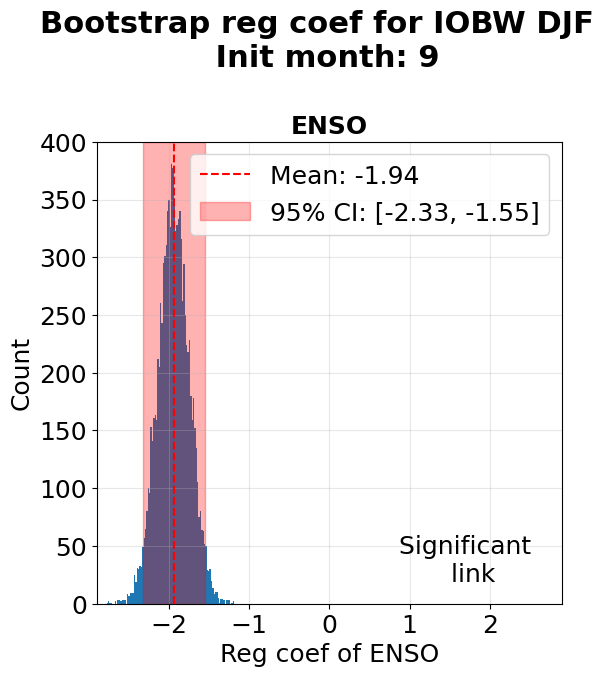

ENSO ['ENSO']
Valid bootstraps: 10000/10000


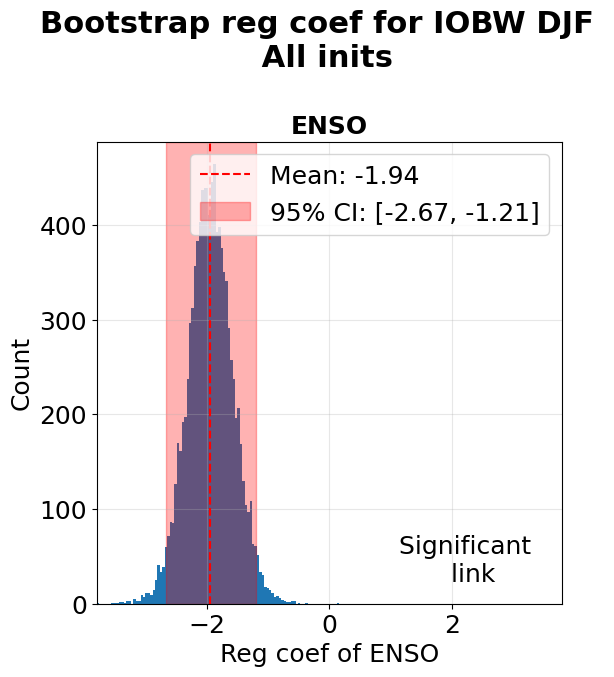

In [20]:
IOBW_DJF_1000=bootstrap_regression(drivers_DJF_xr, drivers_DJF_xr, 'IOBW', ['ENSO'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(IOBW_DJF_1000, ['ENSO'], title='Bootstrap reg coef for IOBW DJF \n Init month: 9')

IOBW_DJF_10000=bootstrap_regression(drivers_DJF_xr_no_VB, drivers_DJF_xr_no_VB, 'IOBW', ['ENSO'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(IOBW_DJF_10000, ['ENSO'], title='Bootstrap reg coef for IOBW DJF \n All inits')

ENSO ['ENSO', 'IOBW']
IOBW ['IOBW', 'ENSO']
Valid bootstraps: 10000/10000


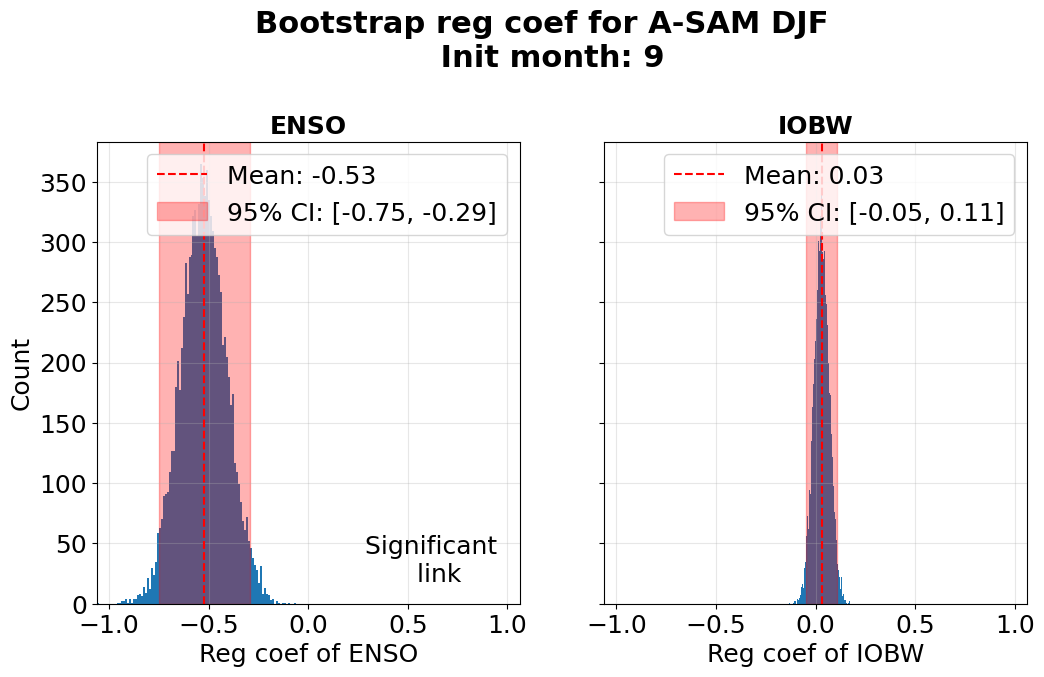

ENSO ['ENSO', 'IOBW']
IOBW ['IOBW', 'ENSO']
Valid bootstraps: 10000/10000


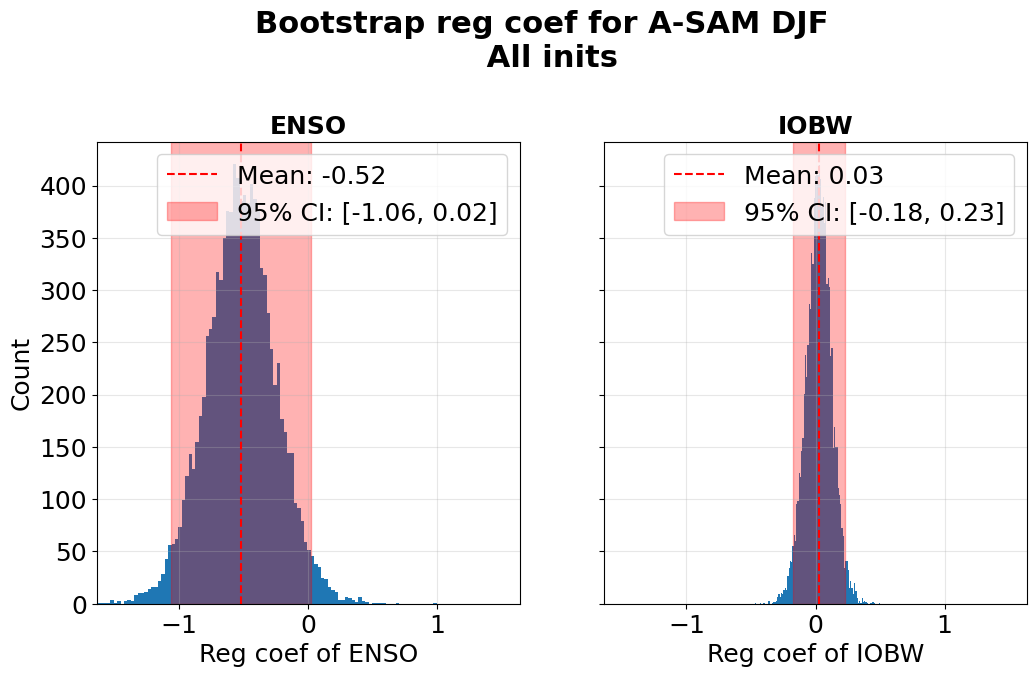

In [21]:
A_SAM_DJF_init9=bootstrap_regression(drivers_DJF_xr, drivers_DJF_xr, 'A_SAM', ['ENSO', 'IOBW'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(A_SAM_DJF_init9, ['ENSO', 'IOBW'], title='Bootstrap reg coef for A-SAM DJF \n Init month: 9')

A_SAM_DJF_10000=bootstrap_regression(drivers_DJF_xr_no_VB, drivers_DJF_xr_no_VB, 'A_SAM', ['ENSO', 'IOBW'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(A_SAM_DJF_10000, ['ENSO', 'IOBW'], title='Bootstrap reg coef for A-SAM DJF \n All inits')

ENSO ['ENSO', 'IOBW']
IOBW ['IOBW', 'ENSO']
Valid bootstraps: 10000/10000


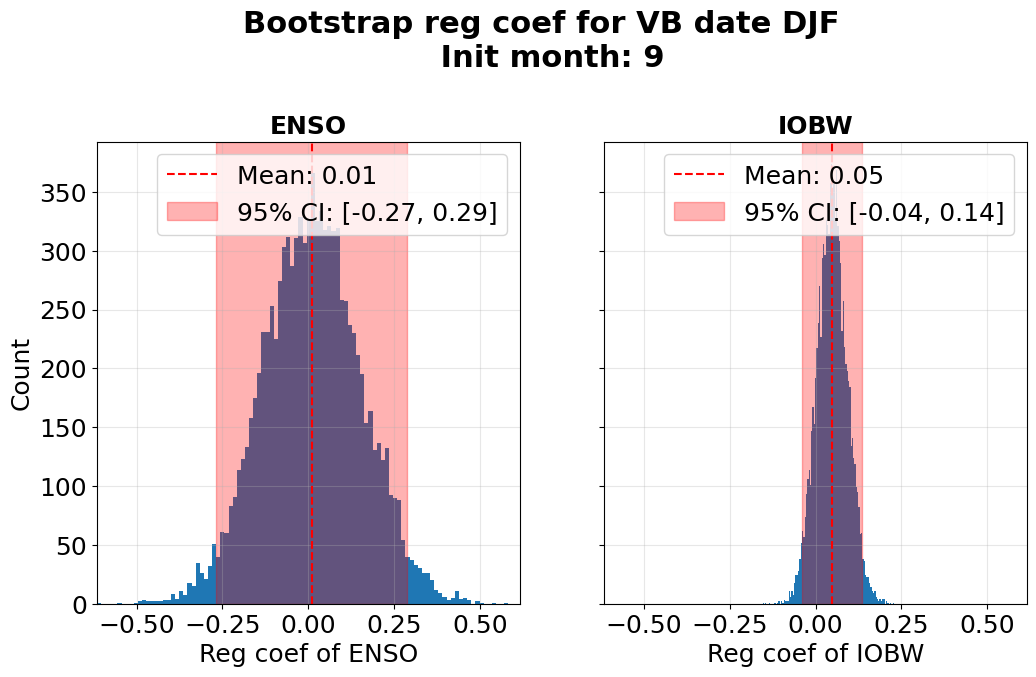

ENSO ['ENSO', 'IOBW', 'VB']
IOBW ['IOBW', 'ENSO', 'VB']
VB ['VB', 'ENSO', 'IOBW']
Valid bootstraps: 10000/10000


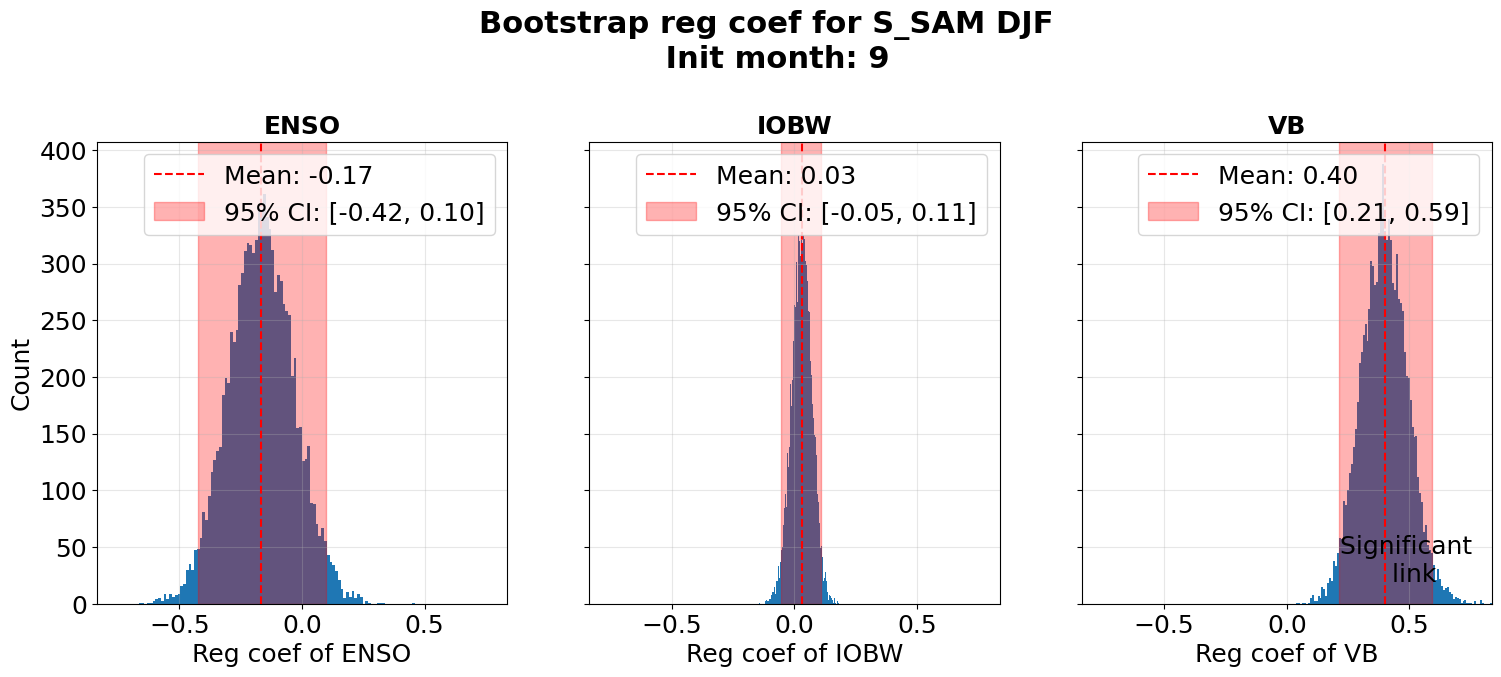

In [64]:
VB_DJF_init9=bootstrap_regression(drivers_DJF_xr, drivers_DJF_xr, 'VB', ['ENSO', 'IOBW'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(VB_DJF_init9, ['ENSO', 'IOBW'], title='Bootstrap reg coef for VB date DJF \n Init month: 9')

S_SAM_DJF_init9=bootstrap_regression(drivers_DJF_xr, drivers_DJF_xr, 'S_SAM', ['ENSO', 'IOBW', 'VB'], n_boot=10000,
                                    sample_size=200, add_intercept=False)
plot_bootstrap_coefficients(S_SAM_DJF_init9, ['ENSO', 'IOBW', 'VB'], title='Bootstrap reg coef for S_SAM DJF \n Init month: 9')

## Causal network overview figure

Gather all drivers links

In [65]:
spring_driver_links=[results_IOD_1000['coef_ENSO'].mean(), *[
        results_SPV_1000[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOD']
    ], *[
        results_A_SAM_1000[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOD']
    ], *[
        results_S_SAM_1000[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOD', 'SPV']
    ]]

summer_driver_links=[IOBW_DJF_1000['coef_ENSO'].mean(), *[
        VB_DJF_init9[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOBW']
    ], *[
        A_SAM_DJF_init9[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOBW']
    ], *[
        S_SAM_DJF_init9[f'coef_{var}'].mean()
        for var in ['ENSO', 'IOBW', 'VB']
    ]]
print(spring_driver_links)

[np.float64(0.4892662033320953), np.float64(0.08934859943845198), np.float64(-0.25491851306898944), np.float64(-0.47266569565309946), np.float64(-0.14860730558314594), np.float64(-0.09681980563775906), np.float64(0.003077647188208724), np.float64(0.49919464477078984)]


In [66]:
def transform_reg_lists(
    somelist,
    driver_target_tuple_list,
    dict_with_other_info=None,
    copy_ind=True
):

    if copy_ind:
        d = (
            {}
            if dict_with_other_info is None
            else dict_with_other_info.copy()
        )
    else:
        d = (
            {}
            if dict_with_other_info is None
            else dict_with_other_info
        )

    # Flatten nested list if necessary
    if driver_target_tuple_list and isinstance(
        driver_target_tuple_list[0], list
    ):
        keys = [
            key
            for group in driver_target_tuple_list
            for key in group
        ]
    else:
        keys = driver_target_tuple_list

    if len(somelist) != len(keys):
        raise ValueError(
            f"Number of coefficients ({len(somelist)}) "
            f"does not match number of driver-target pairs "
            f"({len(keys)})"
        )

    for reg_coef, key in zip(somelist, keys):
        d[key] = float(reg_coef)

    return d

driver_target_list_SON=[[('ENSO', 'IOD')], [('ENSO', 'SPV'), ('IOD', 'SPV')], [('ENSO', 'A_SAM'), ('IOD', 'A_SAM')],
                    [('ENSO', 'S_SAM'), ('IOD', 'S_SAM'), ('SPV', 'S_SAM')]]
driver_target_list_DJF=[[('ENSO', 'IOBW')], [('ENSO', 'VB'), ('IOBW', 'VB')], [('ENSO', 'A_SAM'), ('IOBW', 'A_SAM')],
                    [('ENSO', 'S_SAM'), ('IOBW', 'S_SAM'), ('VB', 'S_SAM')]]

mod_dict_SON = {}
mod_dict_DJF = {}

#for i, element in enumerate(spring_driver_links):

mod_dict_SON = transform_reg_lists(
        spring_driver_links,
        driver_target_list_SON,
        mod_dict_SON, copy_ind=False
    )

mod_dict_DJF = transform_reg_lists(
         summer_driver_links,
         driver_target_list_DJF,
         mod_dict_DJF, copy_ind=False
)

In [67]:
mod_dict_DJF

{('ENSO', 'IOBW'): -1.941870234250701,
 ('ENSO', 'VB'): 0.011672412177562453,
 ('IOBW', 'VB'): 0.048171064016511105,
 ('ENSO', 'A_SAM'): -0.5254483101888278,
 ('IOBW', 'A_SAM'): 0.030353126130699046,
 ('ENSO', 'S_SAM'): -0.16640149742965715,
 ('IOBW', 'S_SAM'): 0.029918441036513217,
 ('VB', 'S_SAM'): 0.39885682609324385}

Gather all Temp & Precip links

In [71]:
def mean_from_df(df, drivers_list=drivers_SON):
    mean_list=[]
    for var in drivers_list:
        mean=df[f'coef_{var}'].mean()
        mean_list.append(mean)
    return mean_list

target_vars=['T_Andes', 'Precip_Andes', 'T_LP', 'Precip_LP']
target_reg_coef_list_SON=[mean_from_df(results_direct_T_Andes_SON_1000), mean_from_df(results_direct_Pr_Andes_SON_1000), 
                          mean_from_df(results_direct_T_LP_SON_1000), mean_from_df(results_direct_Pr_LP_SON_1000)]
target_reg_coef_list_DJF=[mean_from_df(results_T_Andes_DJF_1000, drivers_DJF),
                           mean_from_df(results_Pr_Andes_DJF_1000, drivers_DJF), 
                           mean_from_df(results_T_LP_DJF_1000, drivers_DJF), 
                           mean_from_df(results_Pr_LP_DJF_1000, drivers_DJF)]

pos_t_SON = { "ENSO": (0, 2), "SPV": (1.2, 1), 'IOD':(-1.2,1), "S_SAM": (+0.5, .5), "A_SAM": (-0.5, 0.5), 
             "T": (0, -1)} 
pos_precip_SON = { "ENSO": (0, 2), "SPV": (1.2, 1), 'IOD':(-1.2,1), "S_SAM": (+0.5, .5),
                   "A_SAM": (-0.5, 0.5), "Precip": (0, -1)} 
pos_t_DJF = { "ENSO": (0, 2), "VB": (1.2, 1), 'IOBW':(-1.2,1), "S_SAM": (+0.5, .5), 
             "A_SAM": (-0.5, 0.5), "T": (0, -1)}
pos_precip_DJF = { "ENSO": (0, 2), "VB": (1.2, 1), 'IOBW':(-1.2,1), "S_SAM": (+0.5, .5),
                   "A_SAM": (-0.5, 0.5), "Precip": (0, -1)}

d_SON={}
d_DJF={}
for i in range(len(target_vars)):
    target_tuple_list=[(driver, target_vars[i]) for driver in drivers_SON]
    target_tuple_list_DJF=[(driver, target_vars[i]) for driver in drivers_DJF]
    SON_target_dict=transform_reg_lists(target_reg_coef_list_SON[i], target_tuple_list, mod_dict_SON)
    DJF_target_dict=transform_reg_lists(target_reg_coef_list_DJF[i], target_tuple_list_DJF, mod_dict_DJF)
    print(SON_target_dict)
    d_SON[target_vars[i]]=SON_target_dict
    d_DJF[target_vars[i]]=DJF_target_dict

{('ENSO', 'IOD'): 0.4892662033320953, ('ENSO', 'SPV'): 0.08934859943845198, ('IOD', 'SPV'): -0.25491851306898944, ('ENSO', 'A_SAM'): -0.47266569565309946, ('IOD', 'A_SAM'): -0.14860730558314594, ('ENSO', 'S_SAM'): -0.09681980563775906, ('IOD', 'S_SAM'): 0.003077647188208724, ('SPV', 'S_SAM'): 0.49919464477078984, ('ENSO', 'T_Andes'): 0.2914289103648373, ('IOD', 'T_Andes'): -0.20829672637423446, ('SPV', 'T_Andes'): 0.02886863224542426, ('S_SAM', 'T_Andes'): 0.10358446778542568, ('A_SAM', 'T_Andes'): 0.3385594568838616}
{('ENSO', 'IOD'): 0.4892662033320953, ('ENSO', 'SPV'): 0.08934859943845198, ('IOD', 'SPV'): -0.25491851306898944, ('ENSO', 'A_SAM'): -0.47266569565309946, ('IOD', 'A_SAM'): -0.14860730558314594, ('ENSO', 'S_SAM'): -0.09681980563775906, ('IOD', 'S_SAM'): 0.003077647188208724, ('SPV', 'S_SAM'): 0.49919464477078984, ('ENSO', 'Precip_Andes'): -0.11446857651421678, ('IOD', 'Precip_Andes'): 0.08085058065203381, ('SPV', 'Precip_Andes'): 0.0008309280388746124, ('S_SAM', 'Precip_A

In [72]:
sys.path.insert(0, "../whole_period_effects") 
from drawing_dag import plot_causal_networks_grid

var_type = target_vars[i].split("_")[0]
positions_list = []

for i, var in enumerate(target_vars):
    var_type = var.split("_")[0]   # T or Precip

    # SON block
    if var_type == "T":
        positions_list.append(pos_t_SON)
    else:
        positions_list.append(pos_precip_SON)

# DJF block (same order appended after SON)
for i, var in enumerate(target_vars):
     var_type = var.split("_")[0]

     if var_type == "T":
         positions_list.append(pos_t_DJF)
     else:
         positions_list.append(pos_precip_DJF)



network_data_list=list(d_SON.values())+list(d_DJF.values())
title_list = []

for var in target_vars:
    region = var.split("_")[1]

    title_list.append(f"{var.split('_')[0]} {region}")   # SON
for var in target_vars:
    region = var.split("_")[1]

    title_list.append(f"{var.split('_')[0]} {region}")   # DJF

    
positions_list=[pos_t_SON, pos_precip_SON, pos_t_SON, pos_precip_SON,
                 pos_t_DJF, pos_precip_DJF, pos_t_DJF, pos_precip_DJF]


print(network_data_list)

[{('ENSO', 'IOD'): 0.4892662033320953, ('ENSO', 'SPV'): 0.08934859943845198, ('IOD', 'SPV'): -0.25491851306898944, ('ENSO', 'A_SAM'): -0.47266569565309946, ('IOD', 'A_SAM'): -0.14860730558314594, ('ENSO', 'S_SAM'): -0.09681980563775906, ('IOD', 'S_SAM'): 0.003077647188208724, ('SPV', 'S_SAM'): 0.49919464477078984, ('ENSO', 'T_Andes'): 0.2914289103648373, ('IOD', 'T_Andes'): -0.20829672637423446, ('SPV', 'T_Andes'): 0.02886863224542426, ('S_SAM', 'T_Andes'): 0.10358446778542568, ('A_SAM', 'T_Andes'): 0.3385594568838616}, {('ENSO', 'IOD'): 0.4892662033320953, ('ENSO', 'SPV'): 0.08934859943845198, ('IOD', 'SPV'): -0.25491851306898944, ('ENSO', 'A_SAM'): -0.47266569565309946, ('IOD', 'A_SAM'): -0.14860730558314594, ('ENSO', 'S_SAM'): -0.09681980563775906, ('IOD', 'S_SAM'): 0.003077647188208724, ('SPV', 'S_SAM'): 0.49919464477078984, ('ENSO', 'Precip_Andes'): -0.11446857651421678, ('IOD', 'Precip_Andes'): 0.08085058065203381, ('SPV', 'Precip_Andes'): 0.0008309280388746124, ('S_SAM', 'Precip

/home/glattus/work/Hindcast/../whole_period_effects/drawing_dag.py:98: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(


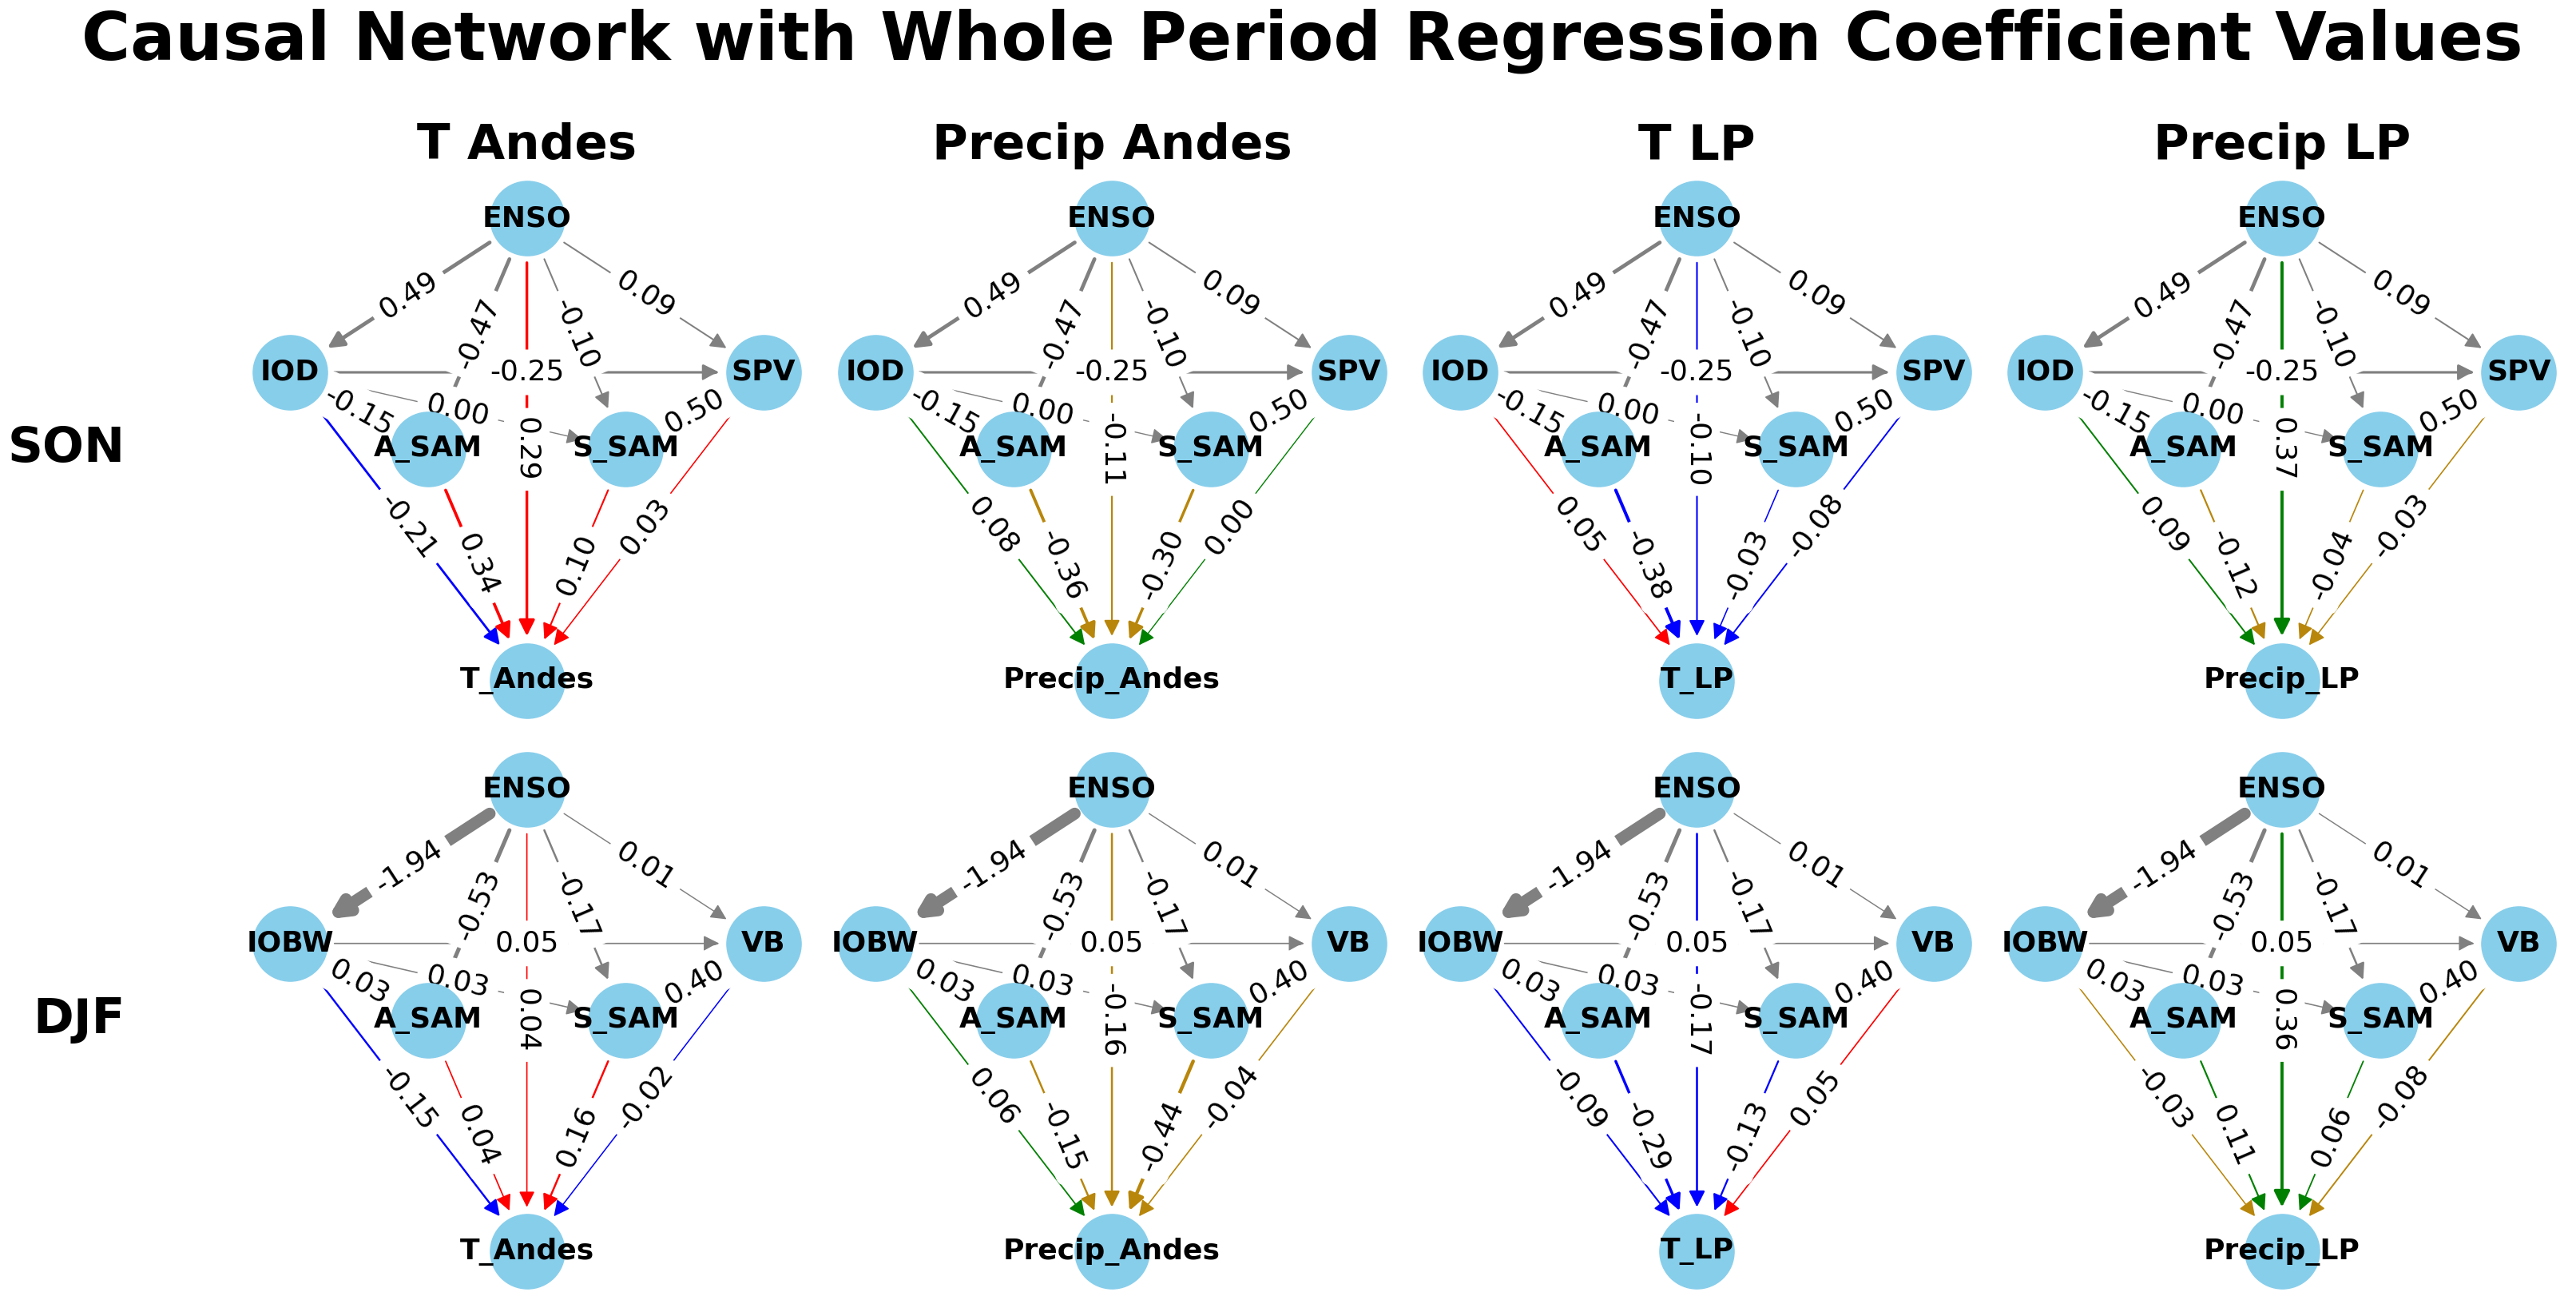

In [73]:
plot_causal_networks_grid(network_data_list, positions_list, title_list, row_labels=['SON', 'DJF'])